In [2]:
import struct as s
import array as array
import numpy as np
import os
import glob
#import utopya as ut
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.integrate import IntegrationWarning
import scipy.integrate as integrate
from scipy.optimize import curve_fit
from scipy.interpolate import griddata
from scipy.interpolate import interp1d
import scipy.integrate as integrate
import pandas as pd

LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
YEAR_MKS = 3.15569251e7
PARSEC_MKS = 3.085677581491367e16
VACUUM_PERMEABILITY_NORM = 1.00000000055
ELECTRON_MASS_MKS = 9.1093837139e-31
PROTON_MASS_MKS = 1.67262192369e-27
CMB_TEMPERATURE = 2.7255

EV_MKS = ELECTRON_CHARGE_MKS
MEGAPARSEC_MKS = 1e6 * PARSEC_MKS
PLANCK_CONSTANT_REDUCED_MKS = PLANCK_CONSTANT_MKS / (2.0 * np.pi)
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS*LIGHT_SPEED_MKS)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * LIGHT_SPEED_MKS
PROTON_REST_ENERGY_MKS = PROTON_MASS_MKS * LIGHT_SPEED_MKS * LIGHT_SPEED_MKS
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS*ELECTRON_CHARGE_MKS / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
CMB_ENERGY = BOLTZMANN_CONSTANT_MKS * CMB_TEMPERATURE
PLANCK_TIMES_LIGHT = PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS*ELECTRON_CHARGE_MKS / (2.0 * VACUUM_PERMITTIVITY * PLANCK_TIMES_LIGHT)
RY_ENERGY_MKS = FINE_STRUCTURE_CONSTANT*FINE_STRUCTURE_CONSTANT * ELECTRON_REST_ENERGY_MKS / 2.0
THOMSON_CROSS_SECTION_MKS = (8.0 * np.pi / 3.0) * ELECTRON_RADIUS_MKS * ELECTRON_RADIUS_MKS
BOHR_RADIUS_MKS = PLANCK_CONSTANT_REDUCED_MKS / (ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * FINE_STRUCTURE_CONSTANT)



PLANCK_CONSTANT_CGS = PLANCK_CONSTANT_MKS * 1.0e7
ELECTRON_MASS_CGS = ELECTRON_MASS_MKS * 1.0e3
ELECTRON_CHARGE_CGS = ELECTRON_CHARGE_MKS * 2.99792458e9    
LIGHT_SPEED_CGS = LIGHT_SPEED_MKS * 1.0e2
DIRAC_CONSTANT_CGS = PLANCK_CONSTANT_CGS / (2.0 * np.pi)

#Estructura del dataframe
ParticleType = np.dtype([('x', np.float64), ('y', np.float64), ('z', np.float64),
                            ('px', np.float64), ('py', np.float64), ('pz', np.float64), ('t', np.float64),
                            ('type', np.ubyte), ('state', np.ubyte), ('create', np.ubyte), ('destroy', np.ubyte), ('padding', np.int32)])



# --- 1. Publication-Quality Parameters ---
import matplotlib.pyplot as plt

# Paleta de colores de alto contraste (ej. tab10 o colorblind)
high_contrast_colors = plt.cm.tab10.colors

plt.rcParams.update({
    "text.usetex": True,                  # Fundamental para tipografía de tesis en física
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 14,                 # Letras legibles
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,                # Números claros
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "lines.linewidth": 2.0,               # Líneas más gruesas para contraste
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "-",
    "axes.prop_cycle": plt.cycler('color', high_contrast_colors)
})


Integrating ODEs...


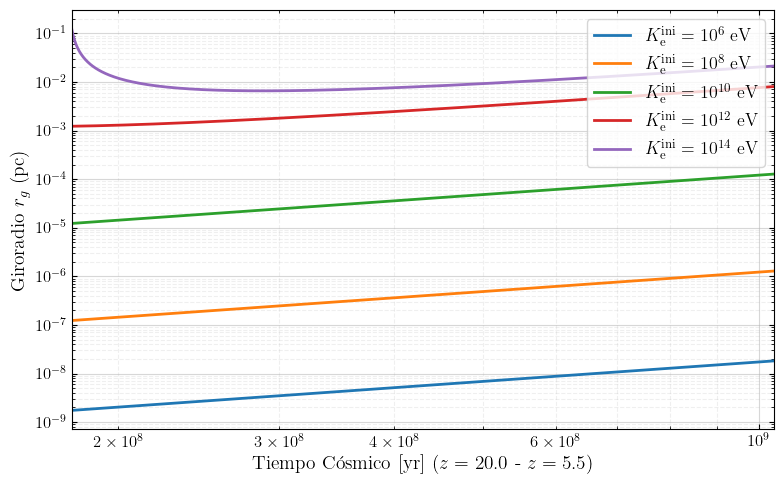

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u

# --- 1. Publication-Quality Formatting ---
# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["STIXGeneral", "Computer Modern Roman"],
#     "mathtext.fontset": "stix",
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.top": True,
#     "ytick.right": True,
#     "xtick.minor.visible": True,
#     "ytick.minor.visible": True
# })

# --- Parámetros de Inyección y Cosmología ---
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

# --- Mapeo z(t) ---
z_grid = np.logspace(-3, np.log10(z_init + 5), 500)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]

z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

# --- Parámetros Iniciales del Campo y Partículas ---
B0 = 1e-9 * 1e-4  
initial_kinetic_energies_eV = np.array([1e6, 1e8, 1e10, 1e12, 1e14]) 
E0 = ELECTRON_REST_ENERGY_MKS
# Consolidate pitch angle (assumed 90 degrees / perfectly perpendicular for max gyroradius)
sin_theta = 0.5 



# Array de tiempo de evaluación (Tiempo transcurrido desde t_init)
elapsed_t_years = np.logspace(0, np.log10((t_final - t_init)/YEAR_MKS), 500)
t_eval = t_init + elapsed_t_years * YEAR_MKS

# --- Definición del Sistema ODE ---
def cooling_rate(t, K):
    # Extract scalar and enforce physical floor
    K_val = np.maximum(K[0], 0.0)
    z = z_interp(t)
    
    # Evolución cosmológica del campo magnético
    B_z = B0 * (1 + z)**2
    U_B_z = (B_z**2) / (2 * VACUUM_PERMEABILITY)
    
    # Pérdidas radiativas exactas dependientes del pitch angle
    # P = 2 * sigma_T * c * U_B * (gamma^2 - 1) * sin^2(theta)
    C_rad = 2.0 * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B_z * (sin_theta**2)
    dEdt_rad = - C_rad * ( (K_val/E0 + 1.0)**2 - 1.0 )
    
    return [dEdt_rad]

# --- Resolución Numérica y Graficado ---
print("Integrating ODEs...")
plt.figure(figsize=(8, 5))

for i, K_init_J in enumerate(initial_kinetic_energies_eV * EV_MKS):
    K_init_eV = initial_kinetic_energies_eV[i]
    
    sol = solve_ivp(cooling_rate, 
                    t_span=(t_init, t_eval[-1]), 
                    y0=[K_init_J], 
                    t_eval=t_eval, 
                    method='Radau', 
                    rtol=1e-8, atol=1e-20)
    
    K_t_Joules = np.maximum(sol.y[0], 0.0)
    
    # 1. Recuperar la evolución cosmológica en los pasos evaluados
    z_eval = z_interp(t_eval)
    B_eval = B0 * (1 + z_eval)**2
    
    # 2. Calcular el momentum p(t) riguroso: p = sqrt(K^2 + 2K*m_e c^2) / c
    p_t = np.sqrt(K_t_Joules * (K_t_Joules + 2*E0)) / LIGHT_SPEED_MKS
    
    # 3. Calcular radio de Larmor r_g(t) riguroso con componente perpendicular
    rg_m = (p_t * sin_theta) / (ELECTRON_CHARGE_MKS * B_eval)
    rg_pc = rg_m / PARSEC_MKS
    
    exp_val = int(np.log10(K_init_eV))
    plt.plot(t_eval/YEAR_MKS, rg_pc, label=rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV', lw=2)

# --- Formato de la Gráfica ---
plt.xscale('log')
plt.yscale('log')
plt.xlabel(f'Tiempo Cósmico [yr] ($z={z_init}$ - $z={z_final}$)', fontsize=14)
plt.ylabel('Giroradio $r_g$ (pc)', fontsize=14)

#plt.xlim(z_init, z_final)
#plt.xlim(elapsed_t_years[0], elapsed_t_years[-1])
plt.xlim(t_init/YEAR_MKS, t_final/YEAR_MKS )

# Modifed title to warn about physical assumptions
#plt.title(f'Electron Gyroradius Evolution (Theoretical Synchrotron-Only Cooling)\n$B(z) = B_0(1+z)^2$ ($B_0 = {B0 * 1e4 * 1e9:.1f}$ nG)', fontsize=14)

plt.grid(True, which="major", ls="-", alpha=0.5)
plt.grid(True, which="minor", ls="--", alpha=0.2)
plt.legend(loc='upper right', fontsize=13)
plt.tight_layout()
plt.savefig('Gyroradius_Evolution_Synchrotron_Only-Z_20.png', dpi=300)
plt.show()

In [4]:
(Planck18.age(5.5).to(u.s).value- Planck18.age(6.5).to(u.s).value)/YEAR_MKS /1e9

B0*1e4*(11)**2 *1e6

0.12100000000000001

Integrating ODEs...


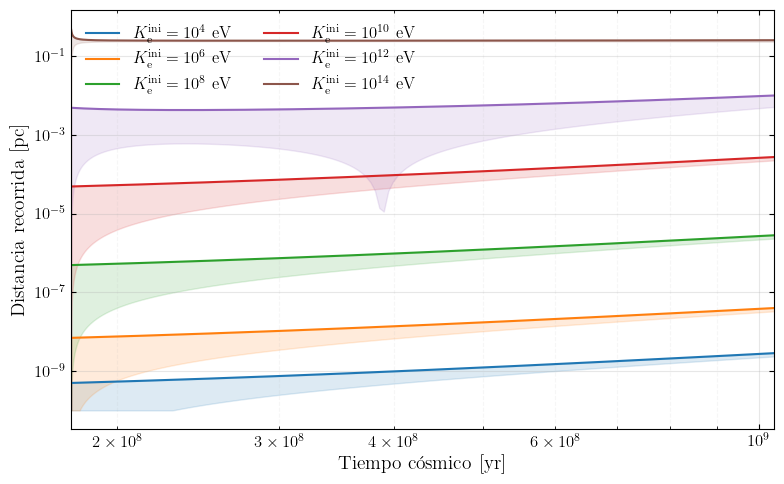

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, cumulative_trapezoid, nquad
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u

# --- 1. Publication-Quality Formatting ---
# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["STIXGeneral", "Computer Modern Roman"],
#     "mathtext.fontset": "stix",
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.top": True,
#     "ytick.right": True,
#     "xtick.minor.visible": True,
#     "ytick.minor.visible": True
# })




# --- Cosmology & Injection Parameters ---
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

# Mapping z(t)
z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

# Field and Particle Initializations
B0 = 1e-9 * 1e-4  
initial_kinetic_energies_eV = np.array([1e4, 1e6, 1e8, 1e10, 1e12, 1e14]) 
E0 = ELECTRON_REST_ENERGY_MKS

v_dir = np.array([1.0, 0.0, 0.0])
v_norm = np.linalg.norm(v_dir)

sin_theta = np.sqrt(v_dir[0]**2 + v_dir[2]**2) / v_norm
cos_theta = v_dir[1] / v_norm

# Unified Evaluation Time Array
elapsed_t_years = np.logspace(0, np.log10((t_final - t_init)/YEAR_MKS), 1000)
t_eval = t_init + elapsed_t_years * YEAR_MKS
cosmic_t_years = t_eval / YEAR_MKS
z_eval = z_interp(t_eval)

# --- Define ODE System ---
def cooling_rate(t, K):
    # Solve directly for Kinetic Energy to prevent numerical cancellation at low energies
    K_J = np.maximum(K[0], 0.0)
    gamma = (K_J + E0) / E0
    z = z_interp(t)
    
    # Rigorous momentum expansion: p^2 c^2 = K^2 + 2KE0
    p_sqrd_c_sqrd = K_J**2 + 2 * K_J * E0
    
    # 1. Synchrotron Cooling
    B_z = B0 * (1 + z)**2
    U_B_z = (B_z**2) / (2 * VACUUM_PERMEABILITY)
    C_rad = (4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B_z
    
    dKdt_sync = - (C_rad / E0**2) * p_sqrd_c_sqrd * (1.5 * sin_theta**2)
    
    # # 2. Exact Blackbody Inverse Compton Cooling
    # T_CMB_z = T_CMB_0 * (1.0 + z)
    # thermal_energy_J = BOLTZMANN_CONSTANT_MKS * T_CMB_z
    
    # if K_J > thermal_energy_J:
    #     U_CMB_z = U_CMB_0_J_M3 * (1 + z)**4
    #     b_param = 4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0
        
    #     f_kn = F_KN_interp(b_param)
    #     C_ic = (4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z
        
    #     dKdt_ic = - (C_ic / E0**2) * p_sqrd_c_sqrd * f_kn
    # else:
    #     dKdt_ic = 0.0
    dKdt_ic = 0.0
    
    return [dKdt_sync + dKdt_ic]

# --- Numerical Resolution and Plotting ---
print("Integrating ODEs...")
fig, ax = plt.subplots(figsize=(8.0, 5.0))

for i, K_init_eV in enumerate(initial_kinetic_energies_eV):
    K_init_J = K_init_eV * EV_MKS
    
    sol = solve_ivp(cooling_rate, 
                    t_span=(t_init, t_eval[-1]), 
                    y0=[K_init_J], 
                    t_eval=t_eval, 
                    method='Radau', 
                    rtol=1e-8, atol=1e-20)
    
    K_t_Joules = np.maximum(sol.y[0], 0.0)
    E_t_Joules = K_t_Joules + E0
    
    B_eval = B0 * (1 + z_eval)**2
    B_init = B0 * (1 + z_init)**2
    
    p_init = np.sqrt(K_init_J**2 + 2 * K_init_J * E0) / LIGHT_SPEED_MKS
    p_t = np.sqrt(K_t_Joules**2 + 2 * K_t_Joules * E0) / LIGHT_SPEED_MKS
    
    # 1. Larmor radius
    rg_init_m = (p_init * sin_theta) / (ELECTRON_CHARGE_MKS * B_init)
    rg_init_pc = rg_init_m / PARSEC_MKS
    
    rg_m = (p_t * sin_theta) / (ELECTRON_CHARGE_MKS * B_eval)
    rg_pc = rg_m / PARSEC_MKS
    
    # 2. Helicoidal drift
    v_parallel_t = (p_t * cos_theta) * LIGHT_SPEED_MKS**2 / E_t_Joules
    
    y_m = cumulative_trapezoid(v_parallel_t, t_eval, initial=0)
    y_pc = y_m / PARSEC_MKS
    
    # 3. 3D Distance Bounds
    d_max = np.sqrt((rg_pc + rg_init_pc)**2 + y_pc**2)
    d_min_raw = np.sqrt(np.abs(rg_pc - rg_init_pc)**2 + y_pc**2)
    d_min = np.maximum(d_min_raw, 1e-10)
    
    exp_val = int(np.log10(K_init_eV))
    label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    # Plotting target figure (Cosmic Time)
    line, = ax.plot(cosmic_t_years, d_max, label=label_str, lw=1.5)
    ax.fill_between(cosmic_t_years, d_min, d_max, color=line.get_color(), alpha=0.15)


# --- Formatting ---
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Distancia recorrida [pc]', fontsize=14)
ax.set_xlabel('Tiempo cósmico [yr]', fontsize=14)

ax.grid(True, which="minor", ls="--", alpha=0.1)

ax.set_xlim(t_init/YEAR_MKS, t_final/YEAR_MKS)
#ax.set_ylim(1e4, 1e9)
#ax.set_title(f'$v_{{\\mathrm{{dir}}}} = [{v_dir[0]}, {v_dir[1]}, {v_dir[2]}]$', fontsize=14)
ax.legend(loc='upper left', fontsize=12, ncol=2, frameon=False)

plt.tight_layout()
plt.savefig('Distance_Evolution_Synchrotron_Only_vel_1-0-0-Z_20.png', dpi=300)
plt.show()

Integrating ODEs...


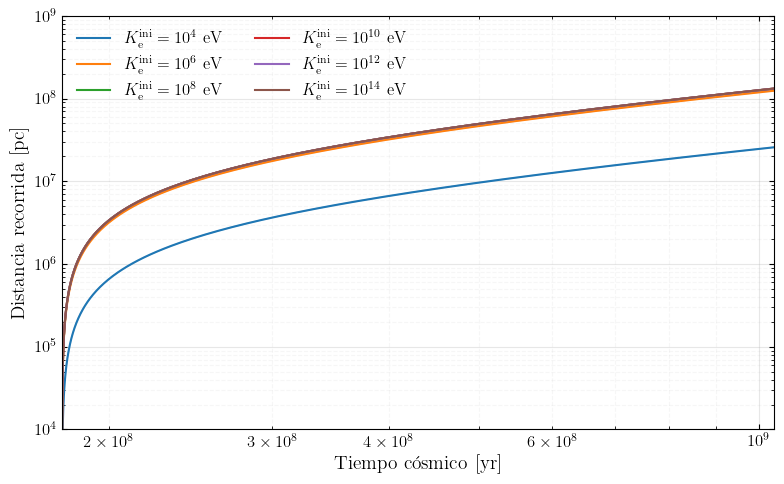

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u

# --- Cosmology & Injection Parameters ---
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

# Mapping z(t)
z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

# Field and Particle Initializations
B0 = 1e-9 * 1e-4  
initial_kinetic_energies_eV = np.array([1e4, 1e6, 1e8, 1e10, 1e12, 1e14]) 
E0 = ELECTRON_REST_ENERGY_MKS

# --- Isotropic Averages over Pitch Angle alpha ---
# 1. <sin^2(alpha)> = 2/3 for synchrotron energy loss
mean_sin2_alpha = 2.0 / 3.0  

# 2. Geometric averages for trajectories
mean_sin_alpha = np.pi / 4.0      # <sin(alpha)> = pi/4 ~ 0.7854 for Larmor radius
mean_abs_cos_alpha = 0.5          # <|cos(alpha)|> = 1/2 for longitudinal drift

# Unified Evaluation Time Array
elapsed_t_years = np.logspace(0, np.log10((t_final - t_init)/YEAR_MKS), 1000)
t_eval = t_init + elapsed_t_years * YEAR_MKS
cosmic_t_years = t_eval / YEAR_MKS
z_eval = z_interp(t_eval)

# --- Define ODE System ---
def cooling_rate(t, K):
    K_J = np.maximum(K[0], 0.0)
    z = z_interp(t)
    
    # Rigorous momentum expansion: p^2 c^2 = K^2 + 2KE0
    p_sqrd_c_sqrd = K_J**2 + 2 * K_J * E0
    
    # 1. Isotropic Synchrotron Cooling Rate
    B_z = B0 * (1 + z)**2
    U_B_z = (B_z**2) / (2 * VACUUM_PERMEABILITY)
    
    # Standard isotropic synchrotron formula (using 4/3 * sigma_T * c * U_B)
    C_rad = (4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B_z
    dKdt_sync = - (C_rad / E0**2) * p_sqrd_c_sqrd
    
    dKdt_ic = 0.0
    return [dKdt_sync + dKdt_ic]

# --- Numerical Resolution and Plotting ---
print("Integrating ODEs...")
fig, ax = plt.subplots(figsize=(8.0, 5.0))

for i, K_init_eV in enumerate(initial_kinetic_energies_eV):
    K_init_J = K_init_eV * EV_MKS
    
    sol = solve_ivp(cooling_rate, 
                    t_span=(t_init, t_eval[-1]), 
                    y0=[K_init_J], 
                    t_eval=t_eval, 
                    method='Radau', 
                    rtol=1e-8, atol=1e-20)
    
    K_t_Joules = np.maximum(sol.y[0], 0.0)
    E_t_Joules = K_t_Joules + E0
    
    B_eval = B0 * (1 + z_eval)**2
    B_init = B0 * (1 + z_init)**2
    
    p_init = np.sqrt(K_init_J**2 + 2 * K_init_J * E0) / LIGHT_SPEED_MKS
    p_t = np.sqrt(K_t_Joules**2 + 2 * K_t_Joules * E0) / LIGHT_SPEED_MKS
    
    # 1. Ensemble-averaged Larmor radius
    rg_init_m = (p_init * mean_sin_alpha) / (ELECTRON_CHARGE_MKS * B_init)
    rg_init_pc = rg_init_m / PARSEC_MKS
    
    rg_m = (p_t * mean_sin_alpha) / (ELECTRON_CHARGE_MKS * B_eval)
    rg_pc = rg_m / PARSEC_MKS
    
    # 2. Ensemble-averaged drift velocity along B-field line
    v_parallel_t = (p_t * mean_abs_cos_alpha) * LIGHT_SPEED_MKS**2 / E_t_Joules
    
    y_m = cumulative_trapezoid(v_parallel_t, t_eval, initial=0)
    y_pc = y_m / PARSEC_MKS
    
    # 3. 3D Envelope Distance Bounds
    d_max = np.sqrt((rg_pc + rg_init_pc)**2 + y_pc**2)
    d_min_raw = np.sqrt(np.abs(rg_pc - rg_init_pc)**2 + y_pc**2)
    d_min = np.maximum(d_min_raw, 1e-10)
    
    exp_val = int(np.log10(K_init_eV))
    label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    # Plotting target figure (Cosmic Time)
    line, = ax.plot(cosmic_t_years, d_max, label=label_str, lw=1.5)
    ax.fill_between(cosmic_t_years, d_min, d_max, color=line.get_color(), alpha=0.15)

# --- Formatting ---
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Distancia recorrida [pc]', fontsize=14)
ax.set_xlabel('Tiempo cósmico [yr]', fontsize=14)

ax.grid(True, which="minor", ls="--", alpha=0.1)

ax.set_xlim(t_init/YEAR_MKS, t_final/YEAR_MKS)
ax.set_ylim(1e4, 1e9)
ax.legend(loc='upper left', fontsize=12, ncol=2, frameon=False)

plt.tight_layout()
plt.savefig('Distance_Evolution_Synchrotron_Only_vel_isotropic-Z_20.png', dpi=300)
plt.show()

Integrating ODEs...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


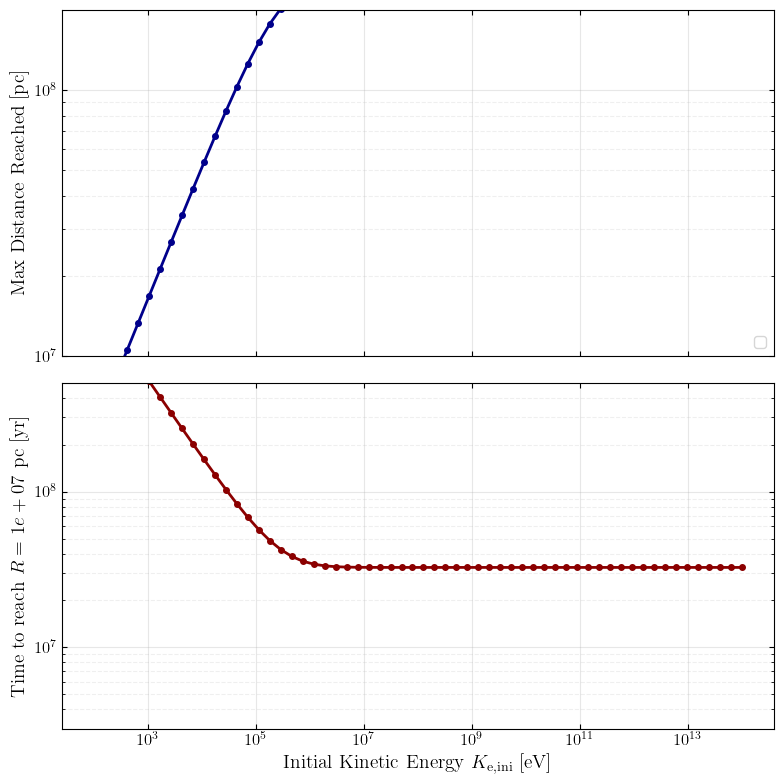

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u

# --- 1. Publication-Quality Formatting ---
# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["STIXGeneral", "Computer Modern Roman"],
#     "mathtext.fontset": "stix",
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.top": True,
#     "ytick.right": True,
#     "xtick.minor.visible": True,
#     "ytick.minor.visible": True
# })


# --- Cosmology Parameters ---
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

# --- Injection Parameters ---
E0 = ELECTRON_REST_ENERGY_MKS

# Distancia objetivo para el cálculo de tiempo
R_TARGET_PC = 1e7
R_TARGET_MKS = R_TARGET_PC * PARSEC_MKS

# Define a dense grid of initial kinetic energies for a smooth curve
initial_kinetic_energies_eV = np.logspace(2, 14, 60)

# --- Define ODE System ---
def free_propagation(t, y):
    # y[0] = Energy (Joules), y[1] = Distance (Meters)
    E_val = np.maximum(y[0], E0)
    gamma = E_val / E0
    
    # 1. Sin pérdidas radiativas (Free-streaming)
    dEdt = 0.0
    
    # 2. Velocity calculation for straight-line propagation
    v_t = LIGHT_SPEED_MKS * np.sqrt(1.0 - 1.0/np.maximum(gamma, 1.0)**2)
    dDdt = v_t
    
    return [dEdt, dDdt]

# Evento para detectar exactamente cuando el electrón alcanza la distancia objetivo
def reached_target_distance(t, y):
    return y[1] - R_TARGET_MKS

# No terminamos la integración al alcanzar R, para poder seguir hasta z_final y obtener la distancia máxima
reached_target_distance.terminal = False

# --- Numerical Resolution ---
print("Integrating ODEs...")
max_distances_pc = []
times_to_target_yr = []

for K_init_eV in initial_kinetic_energies_eV:
    E_init_J = E0 + (K_init_eV * EV_MKS)
    
    sol = solve_ivp(free_propagation, 
                    t_span=(t_init, t_final), 
                    y0=[E_init_J, 0.0], 
                    method='Radau', 
                    events=reached_target_distance,
                    rtol=1e-6, atol=[1e-20, 1e-3])
    
    # Extraer la distancia final alcanzada
    final_distance_m = sol.y[1][-1]
    max_distances_pc.append(final_distance_m / PARSEC_MKS)
    
    # Extraer el tiempo en el que se alcanzó la distancia R (si ocurrió)
    if sol.t_events[0].size > 0:
        time_elapsed_s = sol.t_events[0][0] - t_init
        times_to_target_yr.append(time_elapsed_s / YEAR_MKS)
    else:
        times_to_target_yr.append(np.nan) # Nunca alcanzó la distancia R en la ventana cosmológica

max_distances_pc = np.array(max_distances_pc)
times_to_target_yr = np.array(times_to_target_yr)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Panel 1: Distancia Máxima Alcanzada
ax1.plot(initial_kinetic_energies_eV, max_distances_pc, 
         lw=2, color='darkblue', marker='o', markersize=4, linestyle='-')

# Graficamos la línea de la distancia objetivo como referencia

ax1.set_yscale('log')
ax1.set_ylabel(r'Max Distance Reached [pc]', fontsize=14)
#ax1.set_title(f'Electron Propagation Limits (Free Streaming from $z={z_init}$ to $z={z_final}$)', fontsize=14)
#ax1.grid(True, which="major", ls="-", alpha=0.5)
ax1.grid(True, which="minor", ls="--", alpha=0.2)
ax1.set_ylim(1e7, 2e8)
ax1.legend(loc='lower right')

# Panel 2: Tiempo de Vuelo para alcanzar R_TARGET
ax2.plot(initial_kinetic_energies_eV, times_to_target_yr, 
         lw=2, color='darkred', marker='o', markersize=4, linestyle='-')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'Initial Kinetic Energy $K_{\mathrm{e,ini}}$ [eV]', fontsize=14)
ax2.set_ylabel(f'Time to reach $R={R_TARGET_PC:.0e}$ pc [yr]', fontsize=14)
#ax2.grid(True, which="major", ls="-", alpha=0.5)
ax2.grid(True, which="minor", ls="--", alpha=0.2)
ax2.set_ylim(3e6, 5e8)


plt.tight_layout()
plt.show()

In [8]:
from astropy.cosmology import z_at_value
import astropy.units as u

z_start = 10.0
delta_t = 3e7 * u.yr  # Tiempo de evolución deseado

# Asumiendo que delta_t es una cantidad con unidades de astropy (ej. delta_t = 1e7 * u.yr)
delta_z = z_start - z_at_value(Planck18.age, Planck18.age(z_start) + delta_t) 

delta_z = delta_z.to_value(u.dimensionless_unscaled)  # Convertir a un valor numérico sin unidades
print(f"Redshift change over {delta_t.to_value(u.yr):.2e} years from z={z_start}: Δz = {delta_z:.4f}")

Redshift change over 3.00e+07 years from z=10.0: Δz = 0.4424


Integrating ODEs...


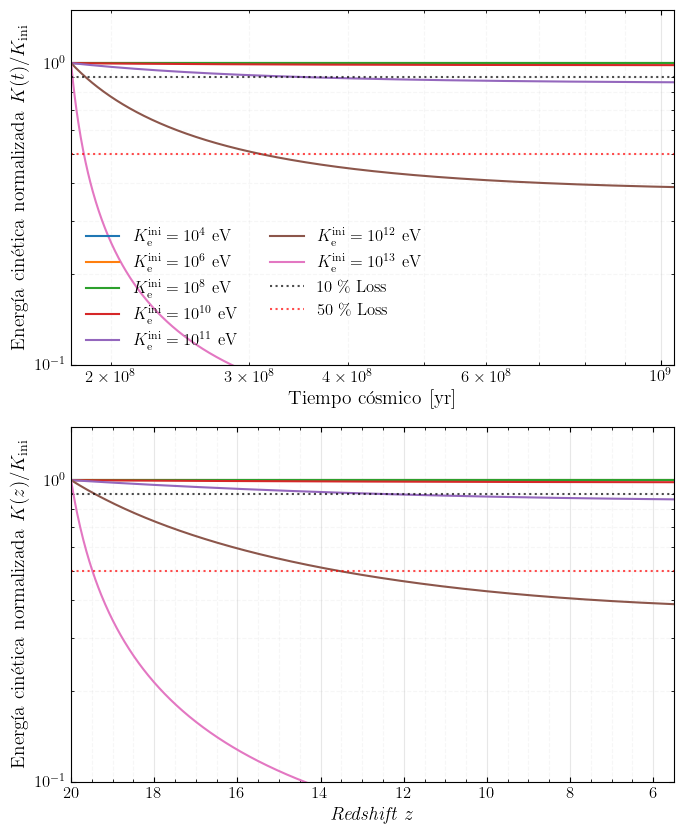

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u

# --- 1. Publication-Quality Formatting ---
# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["STIXGeneral", "Computer Modern Roman"],
#     "mathtext.fontset": "stix",
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.top": True,
#     "ytick.right": True,
#     "xtick.minor.visible": True,
#     "ytick.minor.visible": True
# })


# --- Cosmological Parameters ---
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

# Interpolations
z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

# --- Injection Parameters ---
B0 = 1e-9 * 1e-4  # 1 nG in Tesla
initial_kinetic_energies_eV = np.array([1e4, 1e6, 1e8, 1e10, 1e11, 1e12, 1e13])
E0 = ELECTRON_REST_ENERGY_MKS

# Refactored for clarity and numerical cleanliness
initial_energies_J = E0 + (initial_kinetic_energies_eV * EV_MKS)

# Time arrays: Absolute cosmic time (Reduced to 1000 points for speed without losing ODE precision)
cosmic_t_years = np.logspace(np.log10(t_init/YEAR_MKS), np.log10(t_final/YEAR_MKS), 1000)
t_eval = cosmic_t_years * YEAR_MKS
z_eval = z_interp(t_eval)

# --- Synchrotron ODE System ---
def cooling_rate(t, K):
    # Solve directly for Kinetic Energy to avoid catastrophic cancellation (E^2 - E0^2)
    K_val = np.maximum(K[0], 0.0)
    z = z_interp(t)
    
    # B(z) = B0 * (1+z)^2 scaling
    B_z = B0 * (1 + z)**2
    U_B = (B_z**2) / (2 * VACUUM_PERMEABILITY)
    
    C_t = (4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B
    
    # Rigorous momentum expansion p^2 c^2 = K^2 + 2 K E0
    p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
    
    dKdt = - (C_t / E0**2) * p_sqrd_c_sqrd
    return [dKdt]

# --- Setup Subplots ---
print("Integrating ODEs...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 8.5), sharey=True)

for i, E_init_J in enumerate(initial_energies_J):
    
    K_init_J = E_init_J - E0
    
    sol = solve_ivp(cooling_rate, 
                    t_span=(t_eval[0], t_eval[-1]), 
                    y0=[K_init_J], 
                    t_eval=t_eval, 
                    method='Radau', 
                    rtol=1e-8, atol=1e-20)
    
    K_t_Joules = np.maximum(sol.y[0], 0.0)
    K_t_eV = K_t_Joules / EV_MKS 
    
    # Prevent divide-by-zero or log(0) visual artifacts
    K_t_eV = np.clip(K_t_eV, a_min=1e-20, a_max=None)
    
    normalized_kinetic = K_t_eV / initial_kinetic_energies_eV[i]
    
    exp_val = int(np.log10(initial_kinetic_energies_eV[i]))
    label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    ax1.plot(cosmic_t_years, normalized_kinetic, label=label_str, lw=1.5)
    ax2.plot(z_eval, normalized_kinetic, label=label_str, lw=1.5)

# --- Formatting Panel 1 (Top: Absolute Time) ---
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Tiempo cósmico [yr]', fontsize=14)
ax1.set_ylabel(r'Energía cinética normalizada $K(t)/K_{\mathrm{ini}}$', fontsize=14)

# X-Limits fixed to match t_init exactly
ax1.set_xlim(t_init/YEAR_MKS, t_final/YEAR_MKS)
ax1.set_ylim(1e-1, 1.5)
#ax1.set_title(f'Cosmological Synchrotron Cooling ($B_0 = 1$ nG)', loc='left', fontsize=14)

ax1.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7, label='10 $\%$ Loss')
ax1.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7, label='50 $\%$ Loss')
#ax1.grid(True, which="major", ls="-", alpha=0.3)
ax1.grid(True, which="minor", ls="--", alpha=0.1)

# --- Formatting Panel 2 (Bottom: Redshift) ---
ax2.set_yscale('log')
ax2.invert_xaxis() 
ax2.set_xlabel(r'\textit{Redshift} $z$', fontsize=14)
ax2.set_ylabel(r'Energía cinética normalizada $K(z)/K_{\mathrm{ini}}$', fontsize=14)

# X-limits fixed to match z_init and z_final exactly
ax2.set_xlim(z_init, z_final)

ax2.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7)
ax2.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7)
#ax2.grid(True, which="major", ls="-", alpha=0.3)
ax2.grid(True, which="minor", ls="--", alpha=0.1)

ax1.legend(loc='lower left', fontsize=12, ncol=2, frameon=False)

plt.tight_layout()
plt.savefig('Normalized_Kinetic_Energy_Evolution_Synchrotron_Only-Z_20.png', dpi=300)
plt.show()

Integrating ODEs...


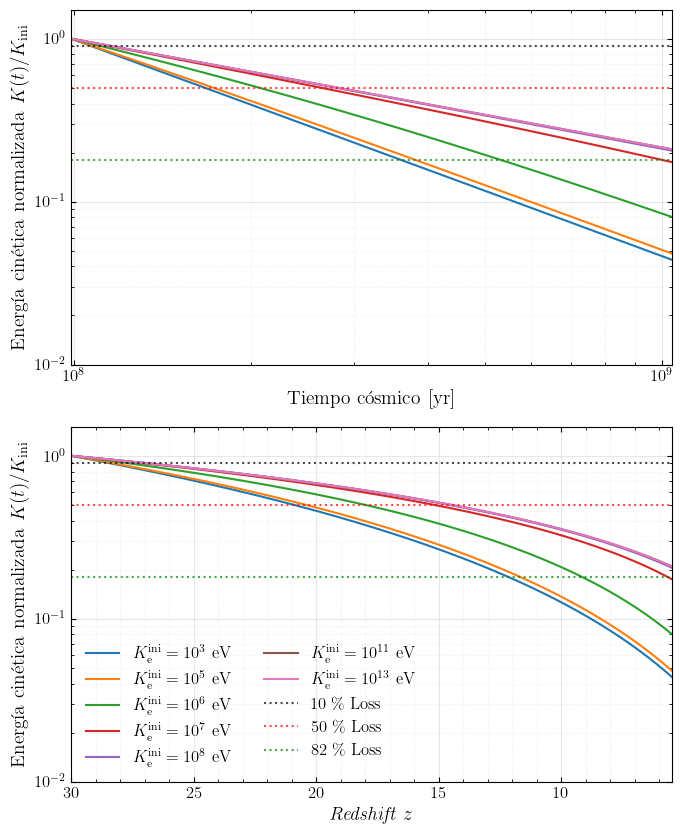

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u

# --- Cosmology and Injection Parameters ---
z_init = 30.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

# --- Pre-calculate z(t) and H(t) interpolations ---
z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]

z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")
H_grid_sort = Planck18.H(z_grid_sort).to(u.s**-1).value
H_interp = interp1d(t_grid_sort, H_grid_sort, kind='cubic', fill_value="extrapolate")

# --- Initial Parameters ---
initial_kinetic_energies_eV = np.array([1e3, 1e5, 1e6, 1e7, 1e8, 1e11, 1e13])
E0 = ELECTRON_REST_ENERGY_MKS

# Unified Evaluation Time Arrays
elapsed_t_years = np.logspace(0, np.log10((t_final - t_init)/YEAR_MKS), 1000)
t_eval = t_init + elapsed_t_years * YEAR_MKS
cosmic_t_years = t_eval / YEAR_MKS
z_eval = z_interp(t_eval)

# --- Pure Adiabatic ODE System (Numerically Stable) ---
def adiabatic_cooling_rate(t, K):
    K_val = np.maximum(K[0], 0.0)
    E_val = K_val + E0
    
    H_t = H_interp(t)
    
    p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
    
    dKdt_ad = - H_t * p_sqrd_c_sqrd / E_val
    return [dKdt_ad]

# --- Setup Subplots (2 Panels) ---
print("Integrating ODEs...")
fig, axes = plt.subplots(2, 1, figsize=(7.0, 8.5), sharey=True)

for i, K_init_eV in enumerate(initial_kinetic_energies_eV):
    K_init_J = K_init_eV * EV_MKS
    
    sol = solve_ivp(adiabatic_cooling_rate, 
                    t_span=(t_eval[0], t_eval[-1]), 
                    y0=[K_init_J], 
                    t_eval=t_eval, 
                    method='Radau', 
                    rtol=1e-8, atol=1e-20)
    
    K_t_Joules = np.maximum(sol.y[0], 0.0)
    K_t_eV = K_t_Joules / EV_MKS 
    normalized_kinetic = K_t_eV / K_init_eV
    
    exp_val = int(np.log10(initial_kinetic_energies_eV[i]))
    label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    # Panel 1: Cosmic Time (formerly axes[1])
    axes[0].plot(cosmic_t_years, normalized_kinetic, label=label_str, lw=1.5)
    
    # Panel 2: Redshift (formerly axes[2])
    axes[1].plot(z_eval, normalized_kinetic, label=label_str, lw=1.5)

# --- Shared Formatting ---
for ax in axes:
    ax.set_yscale('log')
    ax.set_ylabel(r'Energía cinética normalizada $K(t)/K_{\mathrm{ini}}$', fontsize=14)
    ax.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7, label='10 $\%$ Loss')
    ax.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7, label='50 $\%$ Loss')
    ax.axhline(0.18, color='g', linestyle=':', lw=1.5, alpha=0.7, label='82 $\%$ Loss')
    ax.grid(True, which="minor", ls="--", alpha=0.1)

# --- Format Panel 1 (Absolute Cosmic Time) ---
axes[0].set_xscale('log')
axes[0].set_xlabel('Tiempo cósmico [yr]', fontsize=14)
axes[0].set_xlim(t_init/YEAR_MKS, t_final/YEAR_MKS)
axes[0].set_ylim(1e-2, 1.5)
axes[1].legend(loc='lower left', fontsize=12, ncol=2, frameon=False)

# --- Format Panel 2 (Redshift) ---
axes[1].invert_xaxis() 
axes[1].set_xlabel(r'\textit{Redshift} $z$', fontsize=14)
axes[1].set_xlim(z_init, z_final)

plt.tight_layout()
plt.savefig('Normalized_Kinetic_Energy_Evolution_Adiabatic_Only_z30-Z_20.png', dpi=300)
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u

# --- 1. Publication-Quality Formatting ---
# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["STIXGeneral", "Computer Modern Roman"],
#     "mathtext.fontset": "stix",
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.top": True,
#     "ytick.right": True,
#     "xtick.minor.visible": True,
#     "ytick.minor.visible": True
# })

# CMB Constants
T_CMB_0 = 2.7255
U_CMB_0_J_M3 = 4.17e-14  

# --- PRE-CALCULATION: Exact Blackbody Inverse Compton ---
print("Pre-calculating exact CMB Inverse Compton Klein-Nishina kernel over Blackbody spectrum...")

def compute_F_KN(b_val):
    if b_val < 1e-4:
        return 1.0
        
    def integrand(q, x):
        if x < 1e-5:
            planck = x**2
        elif x > 100:
            return 0.0
        else:
            planck = x**3 / (np.exp(x) - 1.0)
            
        if q <= 0:
            kernel = 1.0
        else:
            xb = x * b_val
            kernel = 2*q*np.log(q) + (1+2*q)*(1-q) + ((xb*q)**2 * (1-q))/(2*(1+xb*q))
            kernel /= (1 + xb*q)**3
            
        return planck * kernel

    res, _ = nquad(integrand, [[0, 1], [0, 100]], opts=[{'limit': 50}, {'limit': 50}])
    return res * 45.0 / (np.pi**4)

b_grid = np.logspace(-4, 4, 50)
F_KN_grid = np.array([compute_F_KN(b) for b in b_grid])
F_KN_interp = interp1d(b_grid, F_KN_grid, kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))



# --- Cosmology Parameters ---
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

# Interpolations
z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

cosmic_t_years = np.logspace(np.log10(t_init/YEAR_MKS), np.log10(t_final/YEAR_MKS), 1000)
t_eval = cosmic_t_years * YEAR_MKS
z_eval = z_interp(t_eval)

# --- Inverse Compton ODE System ---
def cooling_rate(t, K):
    # Integrate Kinetic Energy directly to prevent catastrophic cancellation
    K_val = np.maximum(K[0], 0.0)
    E_val = K_val + E0
    z = z_interp(t)
    gamma = E_val / E0
    U_CMB_z = U_CMB_0_J_M3 * (1 + z)**4
    
    p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
    T_CMB_z = T_CMB_0 * (1.0 + z)
    b_KN = 4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0
    
    # Active KN interpolation
    f_KN = F_KN_interp(b_KN) 
    
    C_t = (4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z
    dKdt_ic = - (C_t / E0**2) * p_sqrd_c_sqrd * f_KN
    return [dKdt_ic]

# Stop integrating if kinetic energy reaches the CMB thermal bath level
def thermalization_limit(t, K):
    K_val = K[0]
    z = z_interp(t)
    T_CMB_z = T_CMB_0 * (1.0 + z)
    return K_val - (BOLTZMANN_CONSTANT_MKS * T_CMB_z)

thermalization_limit.terminal = True
thermalization_limit.direction = -1


Pre-calculating exact CMB Inverse Compton Klein-Nishina kernel over Blackbody spectrum...


/home/byaku/anaconda3/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1233: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


Integrating ODEs...


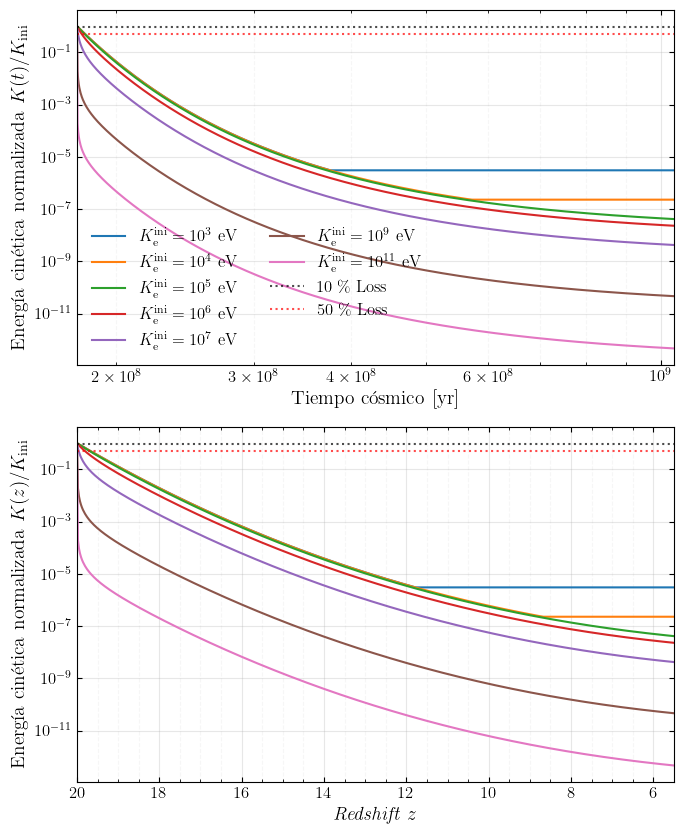

In [12]:
# --- Injection Parameters ---
initial_kinetic_energies_eV = np.array([1e3, 1e4, 1e5, 1e6, 1e7, 1e9, 1e11])
initial_kinetic_energies_J = initial_kinetic_energies_eV * EV_MKS
E0 = ELECTRON_REST_ENERGY_MKS

# --- Setup Subplots ---
print("Integrating ODEs...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 8.5), sharey=True)

for i, K_init_J in enumerate(initial_kinetic_energies_J):
    sol = solve_ivp(cooling_rate,
                    t_span=(t_eval[0], t_eval[-1]),
                    y0=[K_init_J],
                    t_eval=t_eval,
                    events=thermalization_limit,
                    method='Radau',
                    rtol=1e-8, atol=1e-25)
    
    # Use sol.t to map the exact output grid, padding with thermal limits if the solver stopped early
    K_t_Joules = np.interp(t_eval, sol.t, np.maximum(sol.y[0], 0.0)) 
    K_t_eV = K_t_Joules / EV_MKS
    normalized_kinetic = K_t_eV / initial_kinetic_energies_eV[i]
    
    exp_val = int(np.log10(initial_kinetic_energies_eV[i]))
    label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    ax1.plot(t_eval / YEAR_MKS, normalized_kinetic, label=label_str, lw=1.5)
    ax2.plot(z_interp(t_eval), normalized_kinetic, label=label_str, lw=1.5)

# --- Formatting Panel 1 (Top: Absolute Time) ---
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Tiempo cósmico [yr]', fontsize=14)
ax1.set_ylabel(r'Energía cinética normalizada $K(t)/K_{\mathrm{ini}}$', fontsize=14)

# Corrected to display the full simulated range
ax1.set_xlim(t_init/YEAR_MKS, t_final/YEAR_MKS)
#ax1.set_ylim(1e-4, 1.5)
#ax1.set_title(r'Inverse Compton Cooling vs CMB (w/ z fijo - UTOPIA)', loc='left', fontsize=14)

ax1.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7, label='10 $\%$ Loss')
ax1.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7, label='50 $\%$ Loss')
#ax1.grid(True, which="major", ls="-", alpha=0.3)
ax1.grid(True, which="minor", ls="--", alpha=0.1)

# --- Formatting Panel 2 (Bottom: Redshift) ---
ax2.set_yscale('log')
ax2.invert_xaxis() 
ax2.set_xlabel(r'\textit{Redshift} $z$', fontsize=14)
ax2.set_ylabel(r'Energía cinética normalizada $K(z)/K_{\mathrm{ini}}$', fontsize=14)

# Corrected to display the full simulated range
ax2.set_xlim(z_init, z_final)
##ax2.set_title(r'$U_{\mathrm{CMB}}(z) \propto (1+z)^4$', loc='left', fontsize=14)

ax2.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7)
ax2.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7)
#ax2.axvline(z_init-delta_z, color='g', linestyle='--', lw=1.5, alpha=0.7, label=f'Δz over 3e7 yr from z={z_init:.1f}')
#ax2.grid(True, which="major", ls="-", alpha=0.3)
ax2.grid(True, which="minor", ls="--", alpha=0.1)

ax1.legend(loc='lower left', fontsize=12, ncol=2, frameon=False)

plt.tight_layout()
plt.savefig('Normalized_Kinetic_Energy_Evolution_IC_CMB-Z_20.png', dpi=300)
plt.show()

Pre-calculating exact CMB Inverse Compton Klein-Nishina kernel over Blackbody spectrum...
Integrating ODEs...


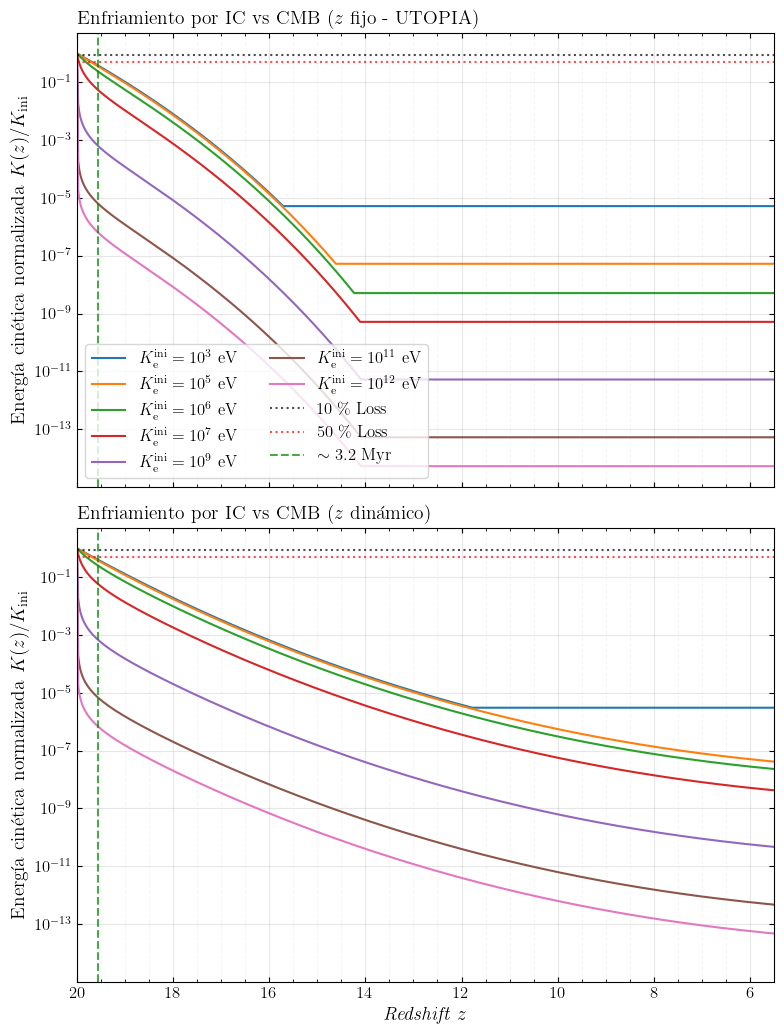

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, nquad
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u

# --- 1. Publication-Quality Formatting ---
# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["STIXGeneral", "Computer Modern Roman"],
#     "mathtext.fontset": "stix",
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.top": True,
#     "ytick.right": True,
#     "xtick.minor.visible": True,
#     "ytick.minor.visible": True
# })

# CMB Constants
T_CMB_0 = 2.7255
U_CMB_0_J_M3 = 4.17e-14  

# --- PRE-CALCULATION: Exact Blackbody Inverse Compton ---
print("Pre-calculating exact CMB Inverse Compton Klein-Nishina kernel over Blackbody spectrum...")

def compute_F_KN(b_val):
    if b_val < 1e-4:
        return 1.0
        
    def integrand(q, x):
        if x < 1e-5:
            planck = x**2
        elif x > 100:
            return 0.0
        else:
            planck = x**3 / (np.exp(x) - 1.0)
            
        if q <= 0:
            kernel = 1.0
        else:
            xb = x * b_val
            kernel = 2*q*np.log(q) + (1+2*q)*(1-q) + ((xb*q)**2 * (1-q))/(2*(1+xb*q))
            kernel /= (1 + xb*q)**3
            
        return planck * kernel

    res, _ = nquad(integrand, [[0, 1], [0, 100]], opts=[{'limit': 50}, {'limit': 50}])
    return res * 45.0 / (np.pi**4)

b_grid = np.logspace(-4, 4, 50)
F_KN_grid = np.array([compute_F_KN(b) for b in b_grid])
F_KN_interp = interp1d(b_grid, F_KN_grid, kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

# --- Cosmology Parameters ---
z_init = 20.0  
z_final = 5.5 # Ensure delta_z is defined in your previous cells
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

# Interpolations
z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

# --- Injection Parameters ---
initial_kinetic_energies_eV = np.array([1e3, 1e5, 1e6, 1e7, 1e9, 1e11, 1e12])
initial_kinetic_energies_J = initial_kinetic_energies_eV * EV_MKS # Ensure EV_MKS is defined
E0 = ELECTRON_REST_ENERGY_MKS # Ensure constant is defined

cosmic_t_years = np.logspace(np.log10(t_init/YEAR_MKS), np.log10(t_final/YEAR_MKS), 1000)
t_eval = cosmic_t_years * YEAR_MKS
z_eval = z_interp(t_eval)

# --- Inverse Compton ODE Systems ---

# System 1: Fixed Redshift (UTOPIA)
def cooling_rate_fixed(t, K):
    K_val = np.maximum(K[0], 0.0)
    E_val = K_val + E0
    z = z_init # Fixed z
    gamma = E_val / E0
    U_CMB_z = U_CMB_0_J_M3 * (1 + z)**4
    
    p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
    T_CMB_z = T_CMB_0 * (1.0 + z)
    b_KN = 4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0
    
    f_KN = F_KN_interp(b_KN) 
    C_t = (4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z
    dKdt_ic = - (C_t / E0**2) * p_sqrd_c_sqrd * f_KN
    return [dKdt_ic]

def thermalization_limit_fixed(t, K):
    K_val = K[0]
    z = z_init # Consistent fixed z for thermal bath check
    T_CMB_z = T_CMB_0 * (1.0 + z)
    return K_val - (BOLTZMANN_CONSTANT_MKS * T_CMB_z)

thermalization_limit_fixed.terminal = True
thermalization_limit_fixed.direction = -1

# System 2: Dynamic Redshift (Realista)
def cooling_rate_dynamic(t, K):
    K_val = np.maximum(K[0], 0.0)
    E_val = K_val + E0
    z = z_interp(t) # Dynamic z
    gamma = E_val / E0
    U_CMB_z = U_CMB_0_J_M3 * (1 + z)**4
    
    p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
    T_CMB_z = T_CMB_0 * (1.0 + z)
    b_KN = 4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0
    
    f_KN = F_KN_interp(b_KN) 
    C_t = (4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z
    dKdt_ic = - (C_t / E0**2) * p_sqrd_c_sqrd * f_KN
    return [dKdt_ic]

def thermalization_limit_dynamic(t, K):
    K_val = K[0]
    z = z_interp(t)
    T_CMB_z = T_CMB_0 * (1.0 + z)
    return K_val - (BOLTZMANN_CONSTANT_MKS * T_CMB_z)

thermalization_limit_dynamic.terminal = True
thermalization_limit_dynamic.direction = -1

# --- Setup Subplots (2x1 Vertical Layout) ---
print("Integrating ODEs...")
fig, axes = plt.subplots(2, 1, figsize=(8.0, 10.5), sharex=True, sharey=True)

ax_fix, ax_dyn = axes[0], axes[1]

# --- Integration Loop ---
for i, K_init_J in enumerate(initial_kinetic_energies_J):
    exp_val = int(np.log10(initial_kinetic_energies_eV[i]))
    label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    # 1. Integrate Fixed
    sol_fix = solve_ivp(cooling_rate_fixed, t_span=(t_eval[0], t_eval[-1]),
                        y0=[K_init_J], t_eval=t_eval, events=thermalization_limit_fixed,
                        method='Radau', rtol=1e-8, atol=1e-25)
    
    K_t_Joules_fix = np.interp(t_eval, sol_fix.t, np.maximum(sol_fix.y[0], 0.0)) 
    norm_kin_fix = (K_t_Joules_fix / EV_MKS) / initial_kinetic_energies_eV[i]
    
    ax_fix.plot(z_interp(t_eval), norm_kin_fix, label=label_str, lw=1.5)

    # 2. Integrate Dynamic
    sol_dyn = solve_ivp(cooling_rate_dynamic, t_span=(t_eval[0], t_eval[-1]),
                        y0=[K_init_J], t_eval=t_eval, events=thermalization_limit_dynamic,
                        method='Radau', rtol=1e-8, atol=1e-25)
    
    K_t_Joules_dyn = np.interp(t_eval, sol_dyn.t, np.maximum(sol_dyn.y[0], 0.0)) 
    norm_kin_dyn = (K_t_Joules_dyn / EV_MKS) / initial_kinetic_energies_eV[i]
    
    ax_dyn.plot(z_interp(t_eval), norm_kin_dyn, label=label_str, lw=1.5)

# --- Formatting ---

for ax in (ax_fix, ax_dyn):
    ax.set_yscale('log')
    ax.set_ylabel(r'Energía cinética normalizada $K(z)/K_{\mathrm{ini}}$', fontsize=14)
    
    # Restored \% for LaTeX and used \Delta instead of the Unicode character
    ax.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7, label=r'10 \% Loss' if ax == ax_fix else None)
    ax.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7, label=r'50 \% Loss' if ax == ax_fix else None)
    ax.axvline(z_init-delta_z, color='g', linestyle='--', lw=1.5, alpha=0.7, label=r'$\sim$ 3.2 Myr' if ax == ax_fix else None)
    
    ax.grid(True, which="minor", ls="--", alpha=0.1)

# X-axis configuration (Shared)
ax_dyn.set_xlabel(r'\textit{Redshift} $z$', fontsize=14)
ax_fix.invert_xaxis() 
ax_fix.set_xlim(z_init, z_final)

# Titles
ax_fix.set_title(r'Enfriamiento por IC vs CMB ($z$ fijo - UTOPIA)', loc='left', fontsize=14)
ax_dyn.set_title(r'Enfriamiento por IC vs CMB ($z$ dinámico)', loc='left', fontsize=14)

# Legend
ax_fix.legend(loc='lower left', fontsize=12, ncol=2, frameon=True)

plt.tight_layout()
plt.savefig('Normalized_Kinetic_Energy_Evolution_IC_CMB_Fixed_vs_Dynamic-Z_20.png', dpi=300)
plt.show()

Integrating ODEs...


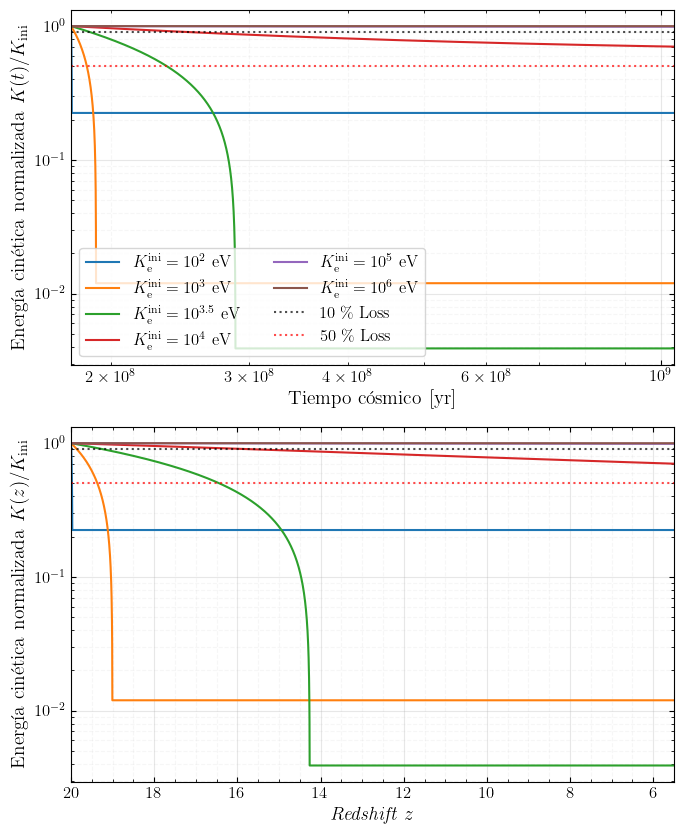

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u

# --- 1. Publication-Quality Formatting ---
# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["STIXGeneral", "Computer Modern Roman"],
#     "mathtext.fontset": "stix",
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.top": True,
#     "ytick.right": True,
#     "xtick.minor.visible": True,
#     "ytick.minor.visible": True
# })

# --- Physical Constants (MKS) ---
# YEAR_MKS = 31557600
# LIGHT_SPEED_MKS = 299792458.0
# ELECTRON_REST_ENERGY_MKS = 8.18710578e-14
# EV_MKS = 1.602176634e-19
# BOLTZMANN_CONSTANT_MKS = 1.380649e-23
# T_CMB_0 = 2.7255

# Constants specific to Coulomb/Plasma calculations
#VACUUM_PERMITTIVITY = 8.8541878128e-12
ELECTRON_MASS = ELECTRON_MASS_MKS 
PLANCK_CONSTANT_REDUCED = PLANCK_CONSTANT_REDUCED_MKS #1.054571817e-34 # h-bar

# --- Cosmology Parameters ---
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

# Interpolations for z(t) mapping
z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

# --- Injection & Plasma Parameters ---
ION_FRACTION = 1e-4  
Z_target = 1.0 # Target atomic number (Hydrogen)
delta_gould = 0.5 # Maximum fractional energy transfer (Gould 1972)

initial_kinetic_energies_eV = np.array([1e2,1e3, 10**(7/2), 1e4, 1e5, 1e6])
initial_kinetic_energies_J = initial_kinetic_energies_eV * EV_MKS
E0 = ELECTRON_REST_ENERGY_MKS

# Time arrays: Absolute cosmic time
cosmic_t_years = np.logspace(np.log10(t_init/YEAR_MKS), np.log10(t_final/YEAR_MKS), 5000)
t_eval = cosmic_t_years * YEAR_MKS
z_eval = z_interp(t_eval)

# --- Pure Coulomb ODE System ---
def cooling_rate(t, K):
    # Integrate Kinetic Energy directly to prevent catastrophic cancellation
    K_val = np.maximum(K[0], 0.0)
    E_val = K_val + E0
    z = z_interp(t)
    
    gamma = E_val / E0
    gamma_minus_one = K_val / E0 # Rigorous evaluation of gamma - 1
    
    # Rigorous velocity calculation avoiding sqrt(1 - 1/gamma^2)
    p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
    current_velocity = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
    
    n_HI_z = 1.8e3 * ((z + 1.0) / 21.0)**3
    electron_density = ION_FRACTION * n_HI_z
    
    # Coulomb Loss Calculation (Gould 1972)
    plasma_freq = np.sqrt(electron_density * (ELECTRON_CHARGE_MKS**2) / (VACUUM_PERMITTIVITY * ELECTRON_MASS))
    
    x = np.sqrt(gamma_minus_one) * current_velocity * LIGHT_SPEED_MKS * ELECTRON_MASS * np.sqrt(2.0 * delta_gould)
    x /= (PLANCK_CONSTANT_REDUCED * plasma_freq)
    
    # Safe logarithm handling
    if x <= 0:
        return [0.0]
        
    factor_b = np.log(x)
    factor_b += np.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2))
    factor_b += 0.5 * delta_gould / (1.0 - delta_gould)
    factor_b += 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
    
    coulomb_force = electron_density * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * factor_b
    coulomb_force /= 4.0 * np.pi * (VACUUM_PERMITTIVITY**2)
    coulomb_force /= ELECTRON_MASS * (current_velocity**2)
    
    dKdt_coulomb = - coulomb_force * current_velocity
    
    return [dKdt_coulomb]

# Stop integrating if kinetic energy reaches the thermal bath level (CMB minimum)
def thermalization_limit(t, K):
    K_val = K[0]
    z = z_interp(t)
    T_CMB_z = T_CMB_0 * (1.0 + z)
    return K_val - (BOLTZMANN_CONSTANT_MKS * T_CMB_z)

thermalization_limit.terminal = True
thermalization_limit.direction = -1

# --- Setup Subplots ---
print("Integrating ODEs...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 8.5), sharey=True)

for i, K_init_J in enumerate(initial_kinetic_energies_J):
    
    sol = solve_ivp(cooling_rate, 
                    t_span=(t_eval[0], t_eval[-1]), 
                    y0=[K_init_J], 
                    t_eval=t_eval, 
                    events=thermalization_limit,
                    method='Radau', 
                    rtol=1e-8, atol=1e-20)
    
    # Map exact output grid, padding with thermal limits if the solver stopped early
    K_t_Joules = np.interp(t_eval, sol.t, np.maximum(sol.y[0], 0.0)) 
    K_t_eV = K_t_Joules / EV_MKS 
    normalized_kinetic = K_t_eV / initial_kinetic_energies_eV[i]
    
    exp_val = int(np.log10(initial_kinetic_energies_eV[i]))
    if i==2:
        label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{3.5}}$ eV'
    else:
        label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    ax1.plot(cosmic_t_years, normalized_kinetic, label=label_str, lw=1.5)
    ax2.plot(z_eval, normalized_kinetic, label=label_str, lw=1.5)

# --- Formatting Panel 1 (Top: Absolute Time) ---
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Tiempo cósmico [yr]', fontsize=14)
ax1.set_ylabel(r'Energía cinética normalizada $K(t)/K_{\mathrm{ini}}$', fontsize=14)
ax1.set_xlim(t_init/YEAR_MKS, t_final/YEAR_MKS)
#ax1.set_ylim(1e-2, 1.5) 
#ax1.set_title(r'Pure Coulomb Cooling ($\chi_e = 10^{-4}$)', loc='left', fontsize=14)

ax1.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7, label=r'10 \% Loss')
ax1.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7, label=r'50 \% Loss')
#ax1.grid(True, which="major", ls="-", alpha=0.3)
ax1.grid(True, which="minor", ls="--", alpha=0.1)

# --- Formatting Panel 2 (Bottom: Redshift) ---
ax2.set_yscale('log')
ax2.invert_xaxis() 
ax2.set_xlabel(r'\textit{Redshift} $z$', fontsize=14)
ax2.set_ylabel(r'Energía cinética normalizada $K(z)/K_{\mathrm{ini}}$', fontsize=14)
ax2.set_xlim(z_init, z_final)
##ax2.set_title(r'$n_e(z) = \chi_e \times 1.8 \times 10^3 \left(\frac{1+z}{21}\right)^3 \: [\mathrm{m}^{-3}]$', loc='left', fontsize=14)

ax2.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7)
ax2.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7)
#ax2.grid(True, which="major", ls="-", alpha=0.3)
ax2.grid(True, which="minor", ls="--", alpha=0.1)

ax1.legend(loc='lower left', fontsize=12, ncol=2, frameon=True)

plt.tight_layout()
plt.savefig('Normalized_Kinetic_Energy_Evolution_Coulomb_Only-Z_20.png', dpi=300)
plt.show()

In [15]:
import numpy as np
from scipy.integrate import quad, solve_ivp
from scipy.special import genlaguerre, spherical_jn, roots_laguerre
from scipy.interpolate import interp1d
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.cosmology import Planck18
import astropy.units as u
import scipy.integrate

# Suppress integration warnings near threshold
#warnings.filterwarnings("ignore", category=scipy.integrate.IntegrationWarning)

# --- Physical Constants ---


# --- Pre-compute Laguerre Roots ---
_laguerre_x, _laguerre_w = roots_laguerre(70)

def exact_gos_hydrogen_1s_np(n, Q):
    if Q <= 0:
        Q = 1e-12
        
    q = np.sqrt(Q)
    delta_E = 1.0 - 1.0 / (n**2)
    norm_np = np.sqrt((2.0 / n)**3 * math.factorial(n - 2) / (2 * n * math.factorial(n + 1)))
    
    L_poly = genlaguerre(n - 2, 3)
    alpha = 1.0 + 1.0 / n
    r = _laguerre_x / alpha  
    
    rho = 2.0 * r / n
    poly_part = 2.0 * norm_np * rho * L_poly(rho) * spherical_jn(1, q * r) * (r**2) * np.sqrt(3)
    
    F_q = np.sum(_laguerre_w * poly_part) / alpha
    return (delta_E / Q) * (F_q**2)

def calculate_sigma_hydrogen_universal(T, n, mode='auto'):
    a0 = BOHR_RADIUS_MKS * 1e10  # Bohr radius (A)
    R = RY_ENERGY_MKS / EV_MKS     # Rydberg energy (eV)
    mc2 = ELECTRON_REST_ENERGY_MKS / EV_MKS  # Electron rest mass energy (eV)
    
    params = {
        2: [10.204, 0.4164, 0.555512, 0.271785, 0.000112, 2.2500],
        3: [12.094, 0.0791, 0.089083, 0.060202,-0.019775, 1.7778],
        4: [12.755, 0.0290, 0.030956, 0.022984,-0.009279, 1.5625],
        5: [13.061, 0.0139, 0.014534, 0.011243,-0.004880, 1.4400],
        6: [13.228, 0.00780, 0.008031, 0.006348, -0.002853, 1.3611],
        7: [13.328, 0.004816, 0.004919, 0.003939, -0.001806, 1.3061],
        8: [13.393, 0.003185,  0.003237,  0.002550, -0.001213, 1.2656],
        9: [13.438,  0.002217, 0.002246,  0.001824, -0.000854, 1.2345],
        10: [13.470, 0.001606, 0.001623,  0.001323, -0.000623, 1.2100],
    }
    
    if n not in params:
        raise ValueError("Parameters only available for n = 2 through 10.")
        
    E, f0, a_bethe, b_bethe, c_bethe, kn = params[n]
    B = R 
    
    if T <= E:
        return 0.0

    if mode == 'auto':
        if T < 3000:
            mode = 'low'
        elif T < 1e5:
            mode = 'asympt'
        else:
            mode = 'rel'

    if mode == 'low':
        q_min = (np.sqrt(T) - np.sqrt(T - E))**2 / R
        q_max = (np.sqrt(T) + np.sqrt(T - E))**2 / R
        
        integrand = lambda Q: exact_gos_hydrogen_1s_np(n, Q) / (E/R) / Q
        f_pwb_val, _ = scipy.integrate.quad(integrand, q_min, q_max, limit=200)
        
        sigma_pwb = (4 * np.pi * a0**2 * R / T) * f_pwb_val
        return sigma_pwb * (T / (T + B + E))

    elif mode == 'asympt':
        prefactor = (4 * np.pi * a0**2 * R) / (T + B + E)
        bracket = a_bethe * np.log(T / R) + b_bethe + (c_bethe * R / T)
        return prefactor * bracket

    elif mode == 'rel':
        gamma = 1 + (T / mc2)
        beta2 = 1.0 - 1.0 / (gamma**2)
        term_rel = np.log(gamma**2 - 1.0) - beta2
        C_rel = b_bethe - a_bethe * np.log(2 * R / mc2)
        prefactor = (8 * np.pi * a0**2 / beta2) * (R / mc2)
        return prefactor * (a_bethe * term_rel + C_rel)


# --- Tabulate Effective Cross-Section Loss ---
print("Tabulating continuous energy loss interpolation grid...")
E_levels = [10.204, 12.094, 12.755, 13.061, 13.228, 13.328, 13.393, 13.438, 13.470]
N_levels = [2, 3, 4, 5, 6, 7, 8, 9, 10]

# Generating a dense grid for fast evaluation during ODE integration
K_e_grid = np.logspace(np.log10(10.204), 11, 2000) # eV
loss_array = np.zeros_like(K_e_grid)

for i, K_e in enumerate(K_e_grid):
    loss_val = 0.0
    for j in range(len(N_levels)):
        n = N_levels[j]
        En = E_levels[j]
        if K_e > En:
            # Calculate sigma in Angstroms^2, convert to m^2, multiply by energy loss in eV
            sigma_A2 = calculate_sigma_hydrogen_universal(K_e, n)
            loss_val += sigma_A2 * 1e-20 * En 
    loss_array[i] = loss_val

loss_interp = interp1d(K_e_grid, loss_array, kind='cubic', fill_value=0.0, bounds_error=False)


# --- Cosmology Parameters ---
print("Initializing Cosmological Framework...")
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

# --- Injection Parameters ---
initial_kinetic_energies_eV = np.array([1e4, 1e5, 1e6, 1e7, 1e8, 1e9])
initial_kinetic_energies_J = initial_kinetic_energies_eV * EV_MKS
E0 = ELECTRON_REST_ENERGY_MKS

elapsed_t_years = np.logspace(0, np.log10((t_final - t_init)/YEAR_MKS), 1000)
t_eval = t_init + elapsed_t_years * YEAR_MKS
cosmic_t_years = t_eval / YEAR_MKS
z_eval = z_interp(t_eval)

# --- Collisional ODE System ---
def cooling_rate(t, K):
    K_val = np.maximum(K[0], 0.0)
    E_val = K_val + E0
    K_eV = K_val / EV_MKS
    
    z = z_interp(t)
    
    p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
    current_velocity = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
    
    # Hydrogen number density parametrization
    n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
    
    # loss_interp(K_eV) returns effective cross section * delta E in (m^2 * eV)
    power_eV_s = n_HI_z * current_velocity * loss_interp(K_eV)
    
    dKdt = - power_eV_s * EV_MKS
    return [dKdt]

def lyman_alpha_limit(t, K):
    K_eV = K[0] / EV_MKS
    return K_eV - 10.204

lyman_alpha_limit.terminal = True
lyman_alpha_limit.direction = -1

Tabulating continuous energy loss interpolation grid...
Initializing Cosmological Framework...


In [16]:
z=20

T_CMB_z = T_CMB_0 * (1.0 + z)
BOLTZMANN_CONSTANT_MKS * T_CMB_z/EV_MKS


0.004932172064522818

Integrating ODEs...


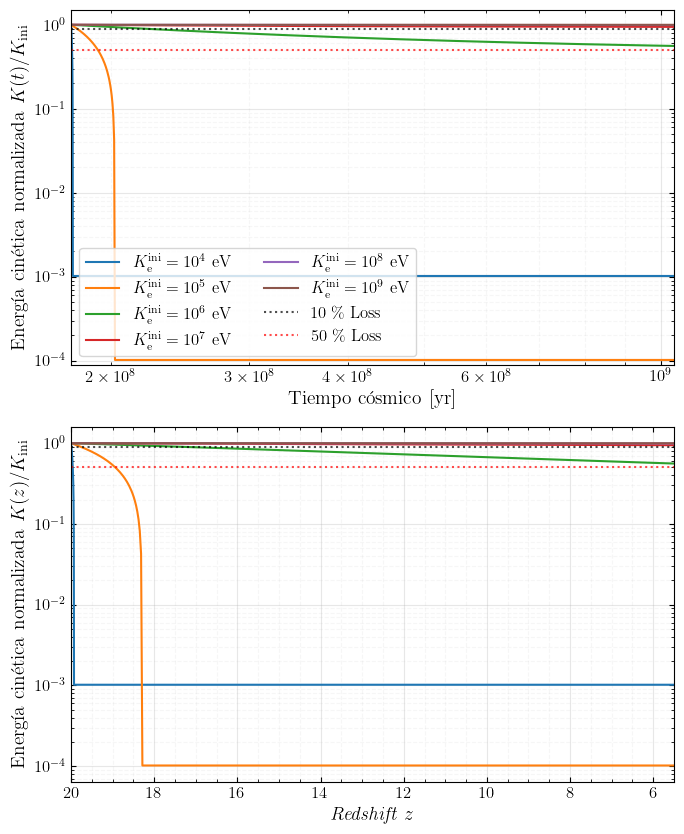

In [17]:



# --- Integration and Plotting ---
print("Integrating ODEs...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 8.5), sharey=False)

for i, K_init_J in enumerate(initial_kinetic_energies_J):
    sol = scipy.integrate.solve_ivp(cooling_rate, 
                    t_span=(t_eval[0], t_eval[-1]), 
                    y0=[K_init_J], 
                    events=lyman_alpha_limit,
                    dense_output=True,  # Generate a continuous interpolant
                    method='Radau', 
                    rtol=1e-8, atol=1e-20)
    
    # Identify the exact time the solver terminated (either t_final or event trigger)
    t_terminal = sol.t[-1]
    
    # Initialize the energy array
    K_t_Joules = np.zeros_like(t_eval)
    
    # Create a boolean mask for the period before the electron hits the threshold
    active_mask = t_eval <= t_terminal
    
    # 1. Use the dense output interpolant for the active cooling phase
    K_t_Joules[active_mask] = sol.sol(t_eval[active_mask])[0]
    
    # 2. Enforce the exact physical limit for the remainder of cosmic time
    K_t_Joules[~active_mask] = 10.204 * EV_MKS
    
    K_t_eV = K_t_Joules / EV_MKS 
    
    normalized_kinetic = K_t_eV / initial_kinetic_energies_eV[i]
    
    exp_val = int(np.log10(initial_kinetic_energies_eV[i]))
    label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    ax1.plot(cosmic_t_years, normalized_kinetic, label=label_str, lw=1.5)
    ax2.plot(z_eval, normalized_kinetic, label=label_str, lw=1.5)

# --- Formatting ---
ax1.set_xscale('log')
ax1.set_yscale('log')

locmaj = ticker.LogLocator(base=10.0, numticks=15)
ax1.yaxis.set_major_locator(locmaj)

ax1.set_xlabel('Tiempo cósmico [yr]', fontsize=14)
ax1.set_ylabel(r'Energía cinética normalizada $K(t)/K_{\mathrm{ini}}$', fontsize=14)
ax1.set_xlim(t_init/YEAR_MKS, t_final/YEAR_MKS)
ax1.set_ylim(0.9e-4, 1.5) 
#ax1.set_title(r'Collisional Excitation Cooling $\mathrm{H}(1s) \rightarrow \mathrm{H}(np)$', loc='left', fontsize=14)

ax1.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7, label=r'10 \% Loss')
ax1.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7, label=r'50 \% Loss')
#ax1.grid(True, which="major", ls="-", alpha=0.3)
ax1.grid(True, which="minor", ls="--", alpha=0.1)

ax2.set_yscale('log')
ax2.yaxis.set_major_locator(locmaj)
ax2.invert_xaxis() 
ax2.set_xlabel(r'\textit{Redshift} $z$', fontsize=14)
ax2.set_ylabel(r'Energía cinética normalizada $K(z)/K_{\mathrm{ini}}$', fontsize=14)
ax2.set_xlim(z_init, z_final)
##ax2.set_title(r'$n_{\mathrm{HI}}(z) = 1.8 \times 10^3 \left(\frac{1+z}{21}\right)^3 \: [\mathrm{m}^{-3}]$', loc='left', fontsize=14)

ax2.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7)
ax2.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7)
#ax2.grid(True, which="major", ls="-", alpha=0.3)
ax2.grid(True, which="minor", ls="--", alpha=0.1)

ax1.legend(loc='lower left', fontsize=12, ncol=2, frameon=True)

plt.tight_layout()
plt.savefig('Normalized_Kinetic_Energy_Evolution_Collisional_Excitation_Hydrogen-Z_20.png', dpi=300)
plt.show()

In [18]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.cosmology import Planck18
import astropy.units as u

# --- Physical Constants ---
# EV_MKS = 1.602176634e-19
# ELECTRON_REST_ENERGY_MKS = 510998.950 * EV_MKS
# RY_ENERGY_MKS = 13.605693122994 * EV_MKS
# ELECTRON_RADIUS_MKS = 2.8179403227e-15
# LIGHT_SPEED_MKS = 299792458.0
# YEAR_MKS = 31557600.0

# --- Global Constants & Variables for RBEB ---
UT_ION_FIT_COUNT = 4  
UT_ION_COUNT = 3
ElectronRestEnergy = ELECTRON_REST_ENERGY_MKS 

DipoleFit = [-0.0224728, 1.177455, -0.4626461, 0.08906479] 
DipoleFitFirstTerm = 2
OccupationNumber = 1
BindingEnergy = RY_ENERGY_MKS 
OrbitalEnergy = BindingEnergy
IonScreeningCorr = 0.0
IonisationConstant = 2.0 * np.pi * ELECTRON_RADIUS_MKS**2 

UT_FIRST_ION = 8

def initialize_dipole_coefficients():
    global DipoleIntegralFit, DipoleStrength, DipoleIntegralSum

    DipoleIntegralFit = np.zeros(UT_ION_FIT_COUNT)
    DipoleStrength = 0.0
    DipoleIntegralSum = 0.0
    
    for j in range(UT_ION_FIT_COUNT):
        DipoleIntegralFit[j] = DipoleFit[j] / (j + DipoleFitFirstTerm)

    for j in range(UT_ION_FIT_COUNT):
        DipoleStrength += DipoleFit[j] / (DipoleFitFirstTerm + j - 1)
        DipoleIntegralSum += DipoleIntegralFit[j]

    DipoleStrength = 2.0 - DipoleStrength / OccupationNumber

def dipole_integral(kinetic_to_binding):
    integral_limit = 2.0 / (kinetic_to_binding + 1.0)
    integral = DipoleIntegralFit[UT_ION_FIT_COUNT - 1]
    
    for i in range(UT_ION_FIT_COUNT - 2, -1, -1):
        integral *= integral_limit
        integral += DipoleIntegralFit[i]

    for _ in range(DipoleFitFirstTerm):
        integral *= integral_limit

    integral = DipoleIntegralSum - integral
    integral /= OccupationNumber

    return integral

def coll_ionisation_cross_section(CurrentKineticEnergy: float) -> float:
    # Safety catch: No ionization below binding energy
    if CurrentKineticEnergy <= BindingEnergy:
        return 0.0

    kinetic_energy = CurrentKineticEnergy / ElectronRestEnergy
    kinetic_to_binding = CurrentKineticEnergy / BindingEnergy
    orbital_energy = OrbitalEnergy / ElectronRestEnergy
    binding_energy = BindingEnergy / ElectronRestEnergy
    binding_energy_sq = binding_energy ** 2
    energy = 1.0 + kinetic_energy  

    velocity_sq = 1.0 - 1.0 / (energy * energy)
    orbital_velocity_sq = 1.0 - 1.0 / ((1.0 + orbital_energy) ** 2)
    binding_velocity_sq = 1.0 - 1.0 / ((1.0 + binding_energy) ** 2)

    # --- Term 1
    term_1 = np.log(0.5 * kinetic_to_binding * (energy + 1.0)) - velocity_sq
    term_1 *= dipole_integral(kinetic_to_binding)
    
    # --- Term 2
    term_2 = (
        0.5 * (kinetic_to_binding - 1.0) * binding_energy_sq
        - np.log(kinetic_to_binding) * (energy + kinetic_energy) / (1.0 + kinetic_to_binding)
    )
    term_2 /= (1.0 + 0.5 * kinetic_energy) ** 2
    term_2 += 1.0 - 1.0 / kinetic_to_binding
    term_2 *= DipoleStrength
    
    # --- Prefactor ---
    factor = (IonisationConstant * OccupationNumber 
              / (binding_energy * (velocity_sq + orbital_velocity_sq + binding_velocity_sq)))
    
    factor *= (1.0 + IonScreeningCorr * (orbital_velocity_sq + binding_velocity_sq) / velocity_sq)

    return factor * (term_1 + term_2)

# Initialize the atomic physics constants
initialize_dipole_coefficients()

# # --- Tabulate Effective Cross-Section Loss ---
# print("Tabulating continuous energy loss interpolation grid...")
# # Threshold is 13.605 eV
# threshold_eV = RY_ENERGY_MKS / EV_MKS
# K_e_grid = np.logspace(np.log10(threshold_eV), 11, 2000) # eV
# loss_array = np.zeros_like(K_e_grid)

# for i, K_e in enumerate(K_e_grid):
#     K_e_joules = K_e * EV_MKS
#     # Cross section in m^2
#     sigma_m2 = coll_ionisation_cross_section(K_e_joules)
    
#     # Energy loss per collision (assuming minimum loss = Binding Energy)
#     # loss_array stores standard effective loss area: cross_section * delta_E
#     loss_array[i] = sigma_m2 * threshold_eV 

# loss_interp = interp1d(K_e_grid, loss_array, kind='cubic', fill_value=0.0, bounds_error=False)


import scipy.integrate as integrate

# --- Tabulate Effective Cross-Section Loss ---
print("Tabulating continuous energy loss interpolation grid...")
# Threshold is 13.605 eV
threshold_eV = RY_ENERGY_MKS / EV_MKS
K_e_grid = np.logspace(np.log10(threshold_eV), 11, 2000) # eV
loss_array = np.zeros_like(K_e_grid)

# Probability distribution functions for the secondary electron
def secondary_pdf_unnorm(eps):
    return 1.0 / (1.0 + (eps / 8.0)**2.1)

def secondary_eps_pdf_unnorm(eps):
    return eps / (1.0 + (eps / 8.0)**2.1)

for i, K_e in enumerate(K_e_grid):
    K_e_joules = K_e * EV_MKS
    # Cross section in m^2
    sigma_m2 = coll_ionisation_cross_section(K_e_joules)
    
    # Calculate expected energy loss: Binding Energy + <Kinetic Energy of Secondary>
    if K_e > threshold_eV:
        # The maximum kinetic energy for the secondary electron is (K - B) / 2
        eps_max = (K_e - threshold_eV) / 2.0
        
        # Provide a known peak point to ensure quad doesn't miss the 
        # distribution peak when evaluating extremely large upper bounds.
        pts = [8.0] if eps_max > 8.0 else None
        
        norm_integral, _ = integrate.quad(secondary_pdf_unnorm, 0, eps_max, points=pts)
        eps_integral, _ = integrate.quad(secondary_eps_pdf_unnorm, 0, eps_max, points=pts)
        
        expected_eps = eps_integral / norm_integral if norm_integral > 0 else 0.0
        average_energy_loss_eV = threshold_eV + expected_eps
    else:
        average_energy_loss_eV = threshold_eV
        
    # loss_array stores standard effective loss area: cross_section * average_delta_E
    loss_array[i] = sigma_m2 * average_energy_loss_eV 

loss_interp = interp1d(K_e_grid, loss_array, kind='cubic', fill_value=0.0, bounds_error=False)

# --- Cosmology Parameters ---
print("Initializing Cosmological Framework...")
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

# --- Injection Parameters ---
initial_kinetic_energies_eV = np.array([1e4, 1e5, 1e6, 1e7, 1e8, 1e9])
initial_kinetic_energies_J = initial_kinetic_energies_eV * EV_MKS

elapsed_t_years = np.logspace(0, np.log10((t_final - t_init)/YEAR_MKS), 1000)
t_eval = t_init + elapsed_t_years * YEAR_MKS
cosmic_t_years = t_eval / YEAR_MKS
z_eval = z_interp(t_eval)

# --- Collisional ODE System ---
def cooling_rate(t, K):
    K_val = np.maximum(K[0], 0.0)
    E_val = K_val + ELECTRON_REST_ENERGY_MKS
    K_eV = K_val / EV_MKS
    
    z = z_interp(t)
    
    p_sqrd_c_sqrd = K_val**2 + 2 * K_val * ELECTRON_REST_ENERGY_MKS
    current_velocity = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
    
    n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
    power_eV_s = n_HI_z * current_velocity * loss_interp(K_eV)
    
    dKdt = - power_eV_s * EV_MKS
    return [dKdt]

def ionization_limit(t, K):
    K_eV = K[0] / EV_MKS
    return K_eV - threshold_eV

ionization_limit.terminal = True
ionization_limit.direction = -1


Tabulating continuous energy loss interpolation grid...


/tmp/ipykernel_5870/3140244407.py:154: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  eps_integral, _ = integrate.quad(secondary_eps_pdf_unnorm, 0, eps_max, points=pts)


Initializing Cosmological Framework...


Integrating ODEs...


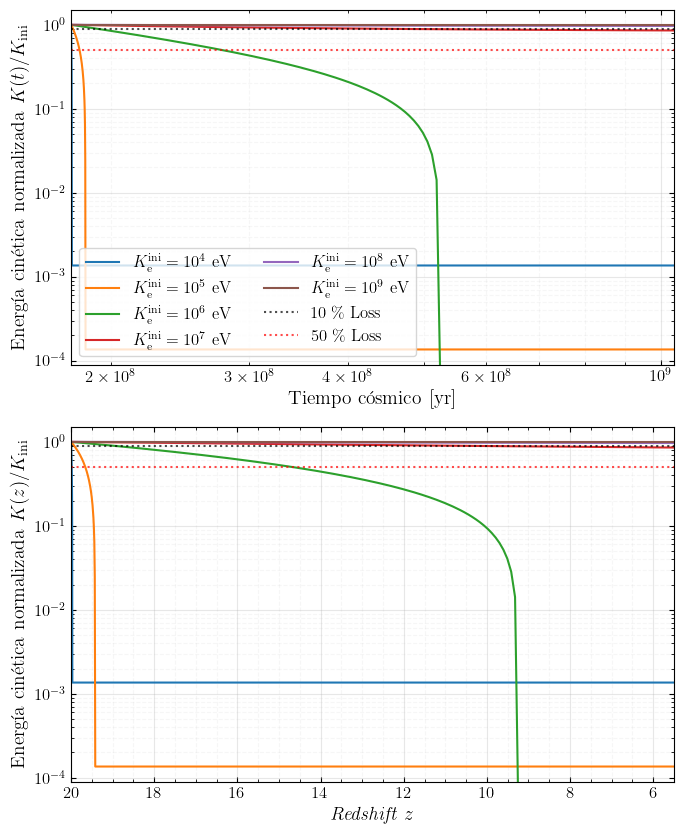

In [19]:


# --- Integration and Plotting ---
print("Integrating ODEs...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 8.5), sharey=True)

for i, K_init_J in enumerate(initial_kinetic_energies_J):
    sol = solve_ivp(cooling_rate, 
                    t_span=(t_eval[0], t_eval[-1]), 
                    y0=[K_init_J], 
                    events=ionization_limit,
                    dense_output=True,  
                    method='Radau', 
                    rtol=1e-8, atol=1e-20)
    
    t_terminal = sol.t[-1]
    K_t_Joules = np.zeros_like(t_eval)
    active_mask = t_eval <= t_terminal
    
    # 1. Use the dense output interpolant for the active cooling phase
    K_t_Joules[active_mask] = sol.sol(t_eval[active_mask])[0]
    
    # 2. Enforce the exact physical limit for the remainder of cosmic time
    K_t_Joules[~active_mask] = threshold_eV * EV_MKS
    
    K_t_eV = K_t_Joules / EV_MKS 
    normalized_kinetic = K_t_eV / initial_kinetic_energies_eV[i]
    
    exp_val = int(np.log10(initial_kinetic_energies_eV[i]))
    label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    ax1.plot(cosmic_t_years, normalized_kinetic, label=label_str, lw=1.5)
    ax2.plot(z_eval, normalized_kinetic, label=label_str, lw=1.5)

# --- Formatting ---
ax1.set_xscale('log')
ax1.set_yscale('log')

locmaj = ticker.LogLocator(base=10.0, numticks=15)
ax1.yaxis.set_major_locator(locmaj)

ax1.set_xlabel('Tiempo cósmico [yr]', fontsize=14)
ax1.set_ylabel(r'Energía cinética normalizada $K(t)/K_{\mathrm{ini}}$', fontsize=14)
ax1.set_xlim(t_init/YEAR_MKS, t_final/YEAR_MKS)
ax1.set_ylim(0.9e-4, 1.5) 
#ax1.set_title(r'Collisional Ionization Cooling $\mathrm{H}(1s) \rightarrow \mathrm{H}^+ + e^-$', loc='left', fontsize=14)

ax1.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7, label='10 \% Loss')
ax1.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7, label='50 \% Loss')
#ax1.grid(True, which="major", ls="-", alpha=0.3)
ax1.grid(True, which="minor", ls="--", alpha=0.1)

ax2.set_yscale('log')
ax2.yaxis.set_major_locator(locmaj)
ax2.invert_xaxis() 
ax2.set_xlabel(r'\textit{Redshift} $z$', fontsize=14)
ax2.set_ylabel(r'Energía cinética normalizada $K(z)/K_{\mathrm{ini}}$', fontsize=14)
ax2.set_xlim(z_init, z_final)
##ax2.set_title(r'$n_{\mathrm{HI}}(z) = 1.8 \times 10^3 \left(\frac{1+z}{21}\right)^3 \: [\mathrm{m}^{-3}]$', loc='left', fontsize=14)

ax2.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7)
ax2.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7)
#ax2.grid(True, which="major", ls="-", alpha=0.3)
ax2.grid(True, which="minor", ls="--", alpha=0.1)

ax1.legend(loc='lower left', fontsize=12, ncol=2, frameon=True)

plt.tight_layout()
plt.savefig('Normalized_Kinetic_Energy_Evolution_Collisional_Ionization_Hydrogen-Z_20.png', dpi=300)
plt.show()

In [20]:
n_CR = 1e-9 * np.array([1e-5,1e-1, 1, 10, 1e2, 1e3, 1e4]) *1e6 #1/m³ Densidad de CR dentro de una galaxia: 1e-9 veces la densidad del ISM. La cual puede ser entre 1 y 1e4
n_CR_e = n_CR * 0.05 # Suponiendo que el 5% de los CR son electrones

sigma = 1e-20 # Ionization CS ~ 0.5e-20 m^2 , 1 barn = 1e-28 m²

int_rate = sigma * n_CR_e * LIGHT_SPEED_MKS # Suponiendo la maxima velocidad relativa posible

t_int = 1/int_rate

t_int/YEAR_MKS/1e6

array([2.11404688e+07, 2.11404688e+03, 2.11404688e+02, 2.11404688e+01,
       2.11404688e+00, 2.11404688e-01, 2.11404688e-02])

Integrating ODEs...


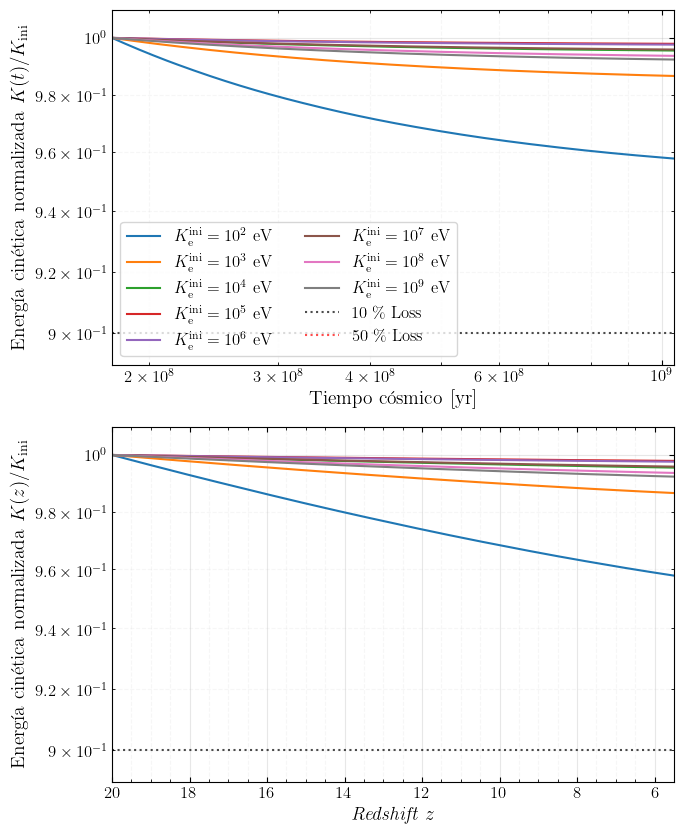

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u
import matplotlib.ticker as ticker

# --- Physical Constants (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
YEAR_MKS = 3.15569251e7
ELECTRON_MASS_MKS = 9.1093837139e-31
VACUUM_PERMEABILITY_NORM = 1.00000000055
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS**2)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS**2 / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS**2 / (2.0 * VACUUM_PERMITTIVITY * PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS)
EV_MKS = ELECTRON_CHARGE_MKS

# --- Cosmology Parameters ---
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

# Interpolations for z(t) mapping
z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

# --- Injection & Field Parameters ---
ION_FRACTION = 1e-4  
initial_kinetic_energies_eV = np.array([1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9])
initial_kinetic_energies_J = initial_kinetic_energies_eV * EV_MKS
E0 = ELECTRON_REST_ENERGY_MKS

# Unified Evaluation Time Arrays
elapsed_t_years = np.logspace(0, np.log10((t_final - t_init)/YEAR_MKS), 1000)
t_eval = t_init + elapsed_t_years * YEAR_MKS
cosmic_t_years = t_eval / YEAR_MKS
z_eval = z_interp(t_eval)

# --- Bremsstrahlung ODE System ---
def bremsstrahlung_cooling_rate(t, K):
    # Integrate Kinetic Energy directly 
    K_val = np.maximum(K[0], 0.0)
    E_val = K_val + E0
    gamma = E_val / E0
    z = z_interp(t)
    
    p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
    current_velocity = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
    
    n_HI_z = 1.8e3 * ((z + 1.0) / 21.0)**3
    electron_density = ION_FRACTION * n_HI_z
    
    # Bremsstrahlung cross-section factor (phi)
    # Strong shielding threshold for Neutral Hydrogen: gamma >= 137
    if gamma >= 137.0:
        phi_rad_neutral = np.log(183.0) + 1.0/18.0
    else:
        # Weak shielding limit
        phi_rad_neutral = np.maximum(np.log(2.0 * gamma) - 1.0/3.0, 0.0)
        
    # Unshielded limit for ions
    phi_rad_ion = np.maximum(np.log(2.0 * gamma) - 1.0/3.0, 0.0)
    
    # e-e Bremsstrahlung approximate contribution (scales with total electrons)
    phi_rad_ee = phi_rad_ion
    
    prefactor = 4.0 * FINE_STRUCTURE_CONSTANT * (ELECTRON_RADIUS_MKS**2)
    
    # Accumulate cross-sections weighted by target densities (Z=1 for Hydrogen)
    rate_HI = n_HI_z * phi_rad_neutral
    rate_HII = electron_density * phi_rad_ion
    rate_ee = (n_HI_z + electron_density) * phi_rad_ee
    
    loss_rate_m_inv = rate_HI + rate_HII + rate_ee
    
    # Power Loss dK/dt [Joules / s]
    dKdt_brem = - prefactor * current_velocity * E_val * loss_rate_m_inv
    
    return [dKdt_brem]

# --- Setup Subplots ---
print("Integrating ODEs...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 8.5), sharey=True)

for i, K_init_J in enumerate(initial_kinetic_energies_J):
    
    sol = solve_ivp(bremsstrahlung_cooling_rate, 
                    t_span=(t_eval[0], t_eval[-1]), 
                    y0=[K_init_J], 
                    t_eval=t_eval, 
                    method='Radau', 
                    rtol=1e-8, atol=1e-20)
    
    K_t_Joules = np.maximum(sol.y[0], 0.0)
    K_t_eV = K_t_Joules / EV_MKS 
    normalized_kinetic = K_t_eV / initial_kinetic_energies_eV[i]
    
    exp_val = int(np.log10(initial_kinetic_energies_eV[i]))
    label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    ax1.plot(cosmic_t_years, normalized_kinetic, label=label_str, lw=1.5)
    ax2.plot(z_eval, normalized_kinetic, label=label_str, lw=1.5)

# --- Formatting Panel 1 (Top: Absolute Time) ---
ax1.set_xscale('log')
ax1.set_yscale('log')

locmaj = ticker.LogLocator(base=10.0, numticks=15)
ax1.yaxis.set_major_locator(locmaj)

ax1.set_xlabel('Tiempo cósmico [yr]', fontsize=14)
ax1.set_ylabel(r'Energía cinética normalizada $K(t)/K_{\mathrm{ini}}$', fontsize=14)
ax1.set_xlim(t_init/YEAR_MKS, t_final/YEAR_MKS)
ax1.set_ylim(0.89, 1.01) 

ax1.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7, label=r'10 \% Loss')
ax1.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7, label=r'50 \% Loss')
ax1.grid(True, which="minor", ls="--", alpha=0.1)

# --- Formatting Panel 2 (Bottom: Redshift) ---
ax2.set_yscale('log')
ax2.yaxis.set_major_locator(locmaj)
ax2.invert_xaxis() 
ax2.set_xlabel(r'\textit{Redshift} $z$', fontsize=14)
ax2.set_ylabel(r'Energía cinética normalizada $K(z)/K_{\mathrm{ini}}$', fontsize=14)
ax2.set_xlim(z_init, z_final)

ax2.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7)
ax2.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7)
ax2.grid(True, which="minor", ls="--", alpha=0.1)

ax1.legend(loc='lower left', fontsize=12, ncol=2, frameon=True)

plt.tight_layout()
plt.savefig('Normalized_Kinetic_Energy_Evolution_Bremsstrahlung_Hydrogen-Z_20.png', dpi=300)
plt.show()

In [22]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.integrate import solve_ivp, quad, nquad
from scipy.special import genlaguerre, spherical_jn, roots_laguerre
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u

# --- 1. Constantes Físicas (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
YEAR_MKS = 3.15569251e7
PARSEC_MKS = 3.085677581491367e16
VACUUM_PERMEABILITY_NORM = 1.00000000055
ELECTRON_MASS_MKS = 9.1093837139e-31
PROTON_MASS_MKS = 1.67262192369e-27
T_CMB_0 = 2.7255
U_CMB_0_J_M3 = 4.17e-14  

EV_MKS = ELECTRON_CHARGE_MKS
PLANCK_CONSTANT_REDUCED_MKS = PLANCK_CONSTANT_MKS / (2.0 * np.pi)
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS**2)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS**2 / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS**2 / (2.0 * VACUUM_PERMITTIVITY * PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS)
RY_ENERGY_MKS = FINE_STRUCTURE_CONSTANT**2 * ELECTRON_REST_ENERGY_MKS / 2.0
THOMSON_CROSS_SECTION_MKS = (8.0 * np.pi / 3.0) * ELECTRON_RADIUS_MKS**2
BOHR_RADIUS_MKS = PLANCK_CONSTANT_REDUCED_MKS / (ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * FINE_STRUCTURE_CONSTANT)

E0 = ELECTRON_REST_ENERGY_MKS

# --- Parámetros Astrofísicos y de Plasma ---
B0 = 1e-9 * 1e-4  # 1 nG en Tesla
ION_FRACTION = 1e-4  
Z_target = 1.0 
delta_gould = 0.5 
threshold_eV_ion = RY_ENERGY_MKS / EV_MKS
threshold_eV_exc = 10.204

# --- 2. Interpolaciones Cosmológicas ---
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

H_grid_sort = Planck18.H(z_grid_sort).to(u.s**-1).value
H_interp = interp1d(t_grid_sort, H_grid_sort, kind='cubic', fill_value="extrapolate")

cosmic_t_years = np.logspace(np.log10(t_init/YEAR_MKS), np.log10(t_final/YEAR_MKS), 1000)
t_eval = cosmic_t_years * YEAR_MKS
z_eval = z_interp(t_eval)

# --- 3. Pre-cálculos de Secciones Eficaces e Integrales ---

# A) Kernel de Klein-Nishina para CMB (Compton Inverso)
print("Pre-calculando kernel Klein-Nishina (Inverse Compton)...")
def compute_F_KN(b_val):
    if b_val < 1e-4: return 1.0
    def integrand(q, x):
        if x < 1e-5: planck = x**2
        elif x > 100: return 0.0
        else: planck = x**3 / (np.exp(x) - 1.0)
        
        if q <= 0: kernel = 1.0
        else:
            xb = x * b_val
            kernel = 2*q*np.log(q) + (1+2*q)*(1-q) + ((xb*q)**2 * (1-q))/(2*(1+xb*q))
            kernel /= (1 + xb*q)**3
        return planck * kernel
    res, _ = nquad(integrand, [[0, 1], [0, 100]], opts=[{'limit': 50}, {'limit': 50}])
    return res * 45.0 / (np.pi**4)

b_grid = np.logspace(-4, 4, 50)
F_KN_grid = np.array([compute_F_KN(b) for b in b_grid])
F_KN_interp = interp1d(b_grid, F_KN_grid, kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

# B) Excitación Colisional (Hidrógeno)
print("Tabulando grilla de pérdida para Excitación Colisional...")
_laguerre_x, _laguerre_w = roots_laguerre(70)

def exact_gos_hydrogen_1s_np(n, Q):
    if Q <= 0: Q = 1e-12
    q, delta_E = np.sqrt(Q), 1.0 - 1.0 / (n**2)
    norm_np = np.sqrt((2.0 / n)**3 * math.factorial(n - 2) / (2 * n * math.factorial(n + 1)))
    L_poly, alpha = genlaguerre(n - 2, 3), 1.0 + 1.0 / n
    r = _laguerre_x / alpha  
    rho = 2.0 * r / n
    poly_part = 2.0 * norm_np * rho * L_poly(rho) * spherical_jn(1, q * r) * (r**2) * np.sqrt(3)
    F_q = np.sum(_laguerre_w * poly_part) / alpha
    return (delta_E / Q) * (F_q**2)

def calculate_sigma_hydrogen_universal(T, n, mode='auto'):
    a0 = BOHR_RADIUS_MKS * 1e10
    R = RY_ENERGY_MKS / EV_MKS
    mc2 = ELECTRON_REST_ENERGY_MKS / EV_MKS
    params = {
        2: [10.204, 0.4164, 0.555512, 0.271785, 0.000112, 2.2500],
        3: [12.094, 0.0791, 0.089083, 0.060202,-0.019775, 1.7778],
        4: [12.755, 0.0290, 0.030956, 0.022984,-0.009279, 1.5625],
        5: [13.061, 0.0139, 0.014534, 0.011243,-0.004880, 1.4400],
        6: [13.228, 0.00780, 0.008031, 0.006348, -0.002853, 1.3611],
        7: [13.328, 0.004816, 0.004919, 0.003939, -0.001806, 1.3061],
        8: [13.393, 0.003185, 0.003237, 0.002550, -0.001213, 1.2656],
        9: [13.438, 0.002217, 0.002246, 0.001824, -0.000854, 1.2345],
        10: [13.470, 0.001606, 0.001623, 0.001323, -0.000623, 1.2100],
    }
    E, f0, a_bethe, b_bethe, c_bethe, kn = params[n]
    if T <= E: return 0.0

    if mode == 'auto':
        mode = 'low' if T < 3000 else 'asympt' if T < 1e5 else 'rel'

    if mode == 'low':
        q_min = (np.sqrt(T) - np.sqrt(T - E))**2 / R
        q_max = (np.sqrt(T) + np.sqrt(T - E))**2 / R
        integrand = lambda Q: exact_gos_hydrogen_1s_np(n, Q) / (E/R) / Q
        f_pwb_val, _ = quad(integrand, q_min, q_max, limit=200)
        return (4 * np.pi * a0**2 * R / T) * f_pwb_val * (T / (T + R + E))
    elif mode == 'asympt':
        return ((4 * np.pi * a0**2 * R) / (T + R + E)) * (a_bethe * np.log(T / R) + b_bethe + (c_bethe * R / T))
    elif mode == 'rel':
        gamma = 1 + (T / mc2)
        beta2 = 1.0 - 1.0 / (gamma**2)
        return ((8 * np.pi * a0**2 / beta2) * (R / mc2)) * (a_bethe * (np.log(gamma**2 - 1.0) - beta2) + b_bethe - a_bethe * np.log(2 * R / mc2))

E_levels = [10.204, 12.094, 12.755, 13.061, 13.228, 13.328, 13.393, 13.438, 13.470]
N_levels = [2, 3, 4, 5, 6, 7, 8, 9, 10]
K_e_grid = np.logspace(np.log10(10.204), 13, 2000) 
loss_array_exc = np.zeros_like(K_e_grid)

for i, K_e in enumerate(K_e_grid):
    for j, n in enumerate(N_levels):
        if K_e > E_levels[j]:
            loss_array_exc[i] += calculate_sigma_hydrogen_universal(K_e, n) * 1e-20 * E_levels[j]

loss_interp_exc = interp1d(K_e_grid, loss_array_exc, kind='cubic', fill_value=0.0, bounds_error=False)

# C) Ionización Colisional (Modelo RBEB)
print("Tabulando grilla de pérdida para Ionización Colisional...")
UT_ION_FIT_COUNT = 4  
DipoleFit = [-0.0224728, 1.177455, -0.4626461, 0.08906479] 
DipoleIntegralFit = np.array([df / (j + 2) for j, df in enumerate(DipoleFit)])
DipoleIntegralSum = np.sum(DipoleIntegralFit)
DipoleStrength = 2.0 - np.sum([df / (2 + j - 1) for j, df in enumerate(DipoleFit)])
IonisationConstant = 2.0 * np.pi * ELECTRON_RADIUS_MKS**2 

def dipole_integral(kinetic_to_binding):
    integral_limit = 2.0 / (kinetic_to_binding + 1.0)
    integral = DipoleIntegralFit[-1]
    for i in range(UT_ION_FIT_COUNT - 2, -1, -1):
        integral = integral * integral_limit + DipoleIntegralFit[i]
    for _ in range(2):
        integral *= integral_limit
    return DipoleIntegralSum - integral

def coll_ionisation_cross_section(CurrentKineticEnergy):
    if CurrentKineticEnergy <= RY_ENERGY_MKS: return 0.0
    k = CurrentKineticEnergy / E0
    k_b = CurrentKineticEnergy / RY_ENERGY_MKS
    b = RY_ENERGY_MKS / E0
    e = 1.0 + k
    
    v2 = 1.0 - 1.0 / (e**2)
    bv2 = 1.0 - 1.0 / ((1.0 + b)**2)

    t1 = (np.log(0.5 * k_b * (e + 1.0)) - v2) * dipole_integral(k_b)
    t2 = (0.5 * (k_b - 1.0) * b**2 - np.log(k_b) * (e + k) / (1.0 + k_b)) / (1.0 + 0.5 * k)**2
    t2 = (t2 + 1.0 - 1.0 / k_b) * DipoleStrength
    
    factor = IonisationConstant / (b * (v2 + 2 * bv2))
    return factor * (t1 + t2)

loss_array_ion = np.zeros_like(K_e_grid)
for i, K_e in enumerate(K_e_grid):
    if K_e > threshold_eV_ion:
        sigma_m2 = coll_ionisation_cross_section(K_e * EV_MKS)
        eps_max = (K_e - threshold_eV_ion) / 2.0
        pts = [8.0] if eps_max > 8.0 else None
        norm_int, _ = quad(lambda eps: 1.0 / (1.0 + (eps/8.0)**2.1), 0, eps_max, points=pts)
        eps_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max, points=pts)
        expected_eps = eps_int / norm_int if norm_int > 0 else 0.0
        loss_array_ion[i] = sigma_m2 * (threshold_eV_ion + expected_eps)

loss_interp_ion = interp1d(K_e_grid, loss_array_ion, kind='cubic', fill_value=0.0, bounds_error=False)

# --- 4. Sistema ODE Unificado ---
print("Integrando EDO de pérdida total de energía...")

def total_cooling_rate(t, K):
    K_val = np.maximum(K[0], 0.0)
    if K_val <= 0: return [0.0]
    
    E_val = K_val + E0
    K_eV = K_val / EV_MKS
    gamma = E_val / E0
    z = z_interp(t)
    
    p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
    current_velocity = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
    n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
    
    # 1. Pérdida Adiabática
    dKdt_ad = - H_interp(t) * p_sqrd_c_sqrd / E_val
    
    # 2. Radiación Sincrotrón
    U_B = ((B0 * (1 + z)**2)**2) / (2 * VACUUM_PERMEABILITY)
    dKdt_synch = - ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p_sqrd_c_sqrd
    
    # 3. Efecto Compton Inverso (CMB)
    T_CMB_z = T_CMB_0 * (1.0 + z)
    U_CMB_z = U_CMB_0_J_M3 * (1 + z)**4
    b_KN = 4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0
    dKdt_ic = - ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z / E0**2) * p_sqrd_c_sqrd * F_KN_interp(b_KN)
    
    # 4. Interacciones de Coulomb (Plasma)
    electron_density = ION_FRACTION * n_HI_z
    plasma_freq = np.sqrt(electron_density * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS))
    x = np.sqrt(K_val / E0) * current_velocity * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * plasma_freq)
    dKdt_coulomb = 0.0
    if x > 0:
        factor_b = np.log(x) + np.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
        coulomb_force = electron_density * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * factor_b / (4.0 * np.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * current_velocity**2)
        dKdt_coulomb = - coulomb_force * current_velocity

    # 5. Excitación Colisional
    dKdt_exc = 0.0
    if K_eV >= threshold_eV_exc:
        dKdt_exc = - (n_HI_z * current_velocity * loss_interp_exc(K_eV)) * EV_MKS

    # 6. Ionización Colisional
    dKdt_ion = 0.0
    if K_eV >= threshold_eV_ion:
        dKdt_ion = - (n_HI_z * current_velocity * loss_interp_ion(K_eV)) * EV_MKS

    dKdt_total = dKdt_ad + dKdt_synch + dKdt_ic + dKdt_coulomb + dKdt_exc + dKdt_ion
    return [dKdt_total]

# Condición de termalización (detener si K alcanza la energía del CMB)
def thermalization_limit(t, K):
    z = z_interp(t)
    return K[0] - (BOLTZMANN_CONSTANT_MKS * T_CMB_0 * (1.0 + z))
thermalization_limit.terminal = True
thermalization_limit.direction = -1



Pre-calculando kernel Klein-Nishina (Inverse Compton)...
Tabulando grilla de pérdida para Excitación Colisional...
Tabulando grilla de pérdida para Ionización Colisional...


/tmp/ipykernel_5870/206680426.py:193: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  eps_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max, points=pts)


Integrando EDO de pérdida total de energía...


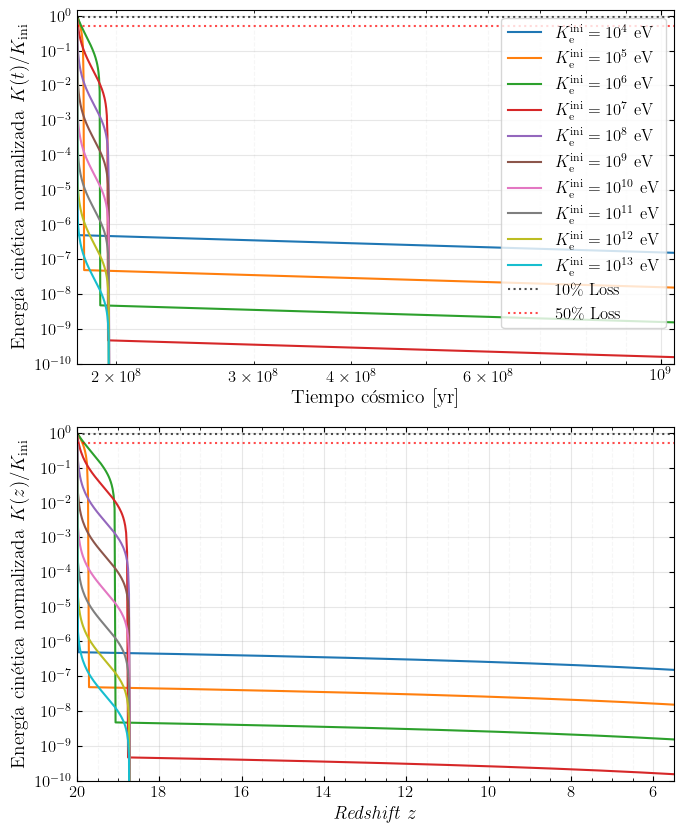

In [23]:
# --- 5. Ejecución y Gráficos ---
initial_kinetic_energies_eV = np.array([1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10, 1e11, 1e12, 1e13])
initial_kinetic_energies_J = initial_kinetic_energies_eV * EV_MKS

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 8.5), sharey=True)

for i, K_init_J in enumerate(initial_kinetic_energies_J):
    sol = solve_ivp(total_cooling_rate, 
                    t_span=(t_eval[0], t_eval[-1]), 
                    y0=[K_init_J], 
                    events=thermalization_limit,
                    dense_output=True,
                    method='Radau', 
                    rtol=1e-8, atol=1e-25)
    
    t_terminal = sol.t[-1]
    K_t_Joules = np.zeros_like(t_eval)
    active_mask = t_eval <= t_terminal
    
    K_t_Joules[active_mask] = sol.sol(t_eval[active_mask])[0]
    # Llenar el resto del array con el límite termal si terminó prematuramente
    thermal_energy = BOLTZMANN_CONSTANT_MKS * T_CMB_0 * (1.0 + z_eval[~active_mask])
    K_t_Joules[~active_mask] = thermal_energy
    
    K_t_eV = K_t_Joules / EV_MKS 
    normalized_kinetic = K_t_eV / initial_kinetic_energies_eV[i]
    
    exp_val = int(np.log10(initial_kinetic_energies_eV[i]))
    label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    ax1.plot(cosmic_t_years, normalized_kinetic, label=label_str, lw=1.5)
    ax2.plot(z_eval, normalized_kinetic, label=label_str, lw=1.5)

# --- Formato ---
locmaj = ticker.LogLocator(base=10.0, numticks=15)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.yaxis.set_major_locator(locmaj)
ax1.set_xlabel('Tiempo cósmico [yr]', fontsize=14)
ax1.set_ylabel(r'Energía cinética normalizada $K(t)/K_{\mathrm{ini}}$', fontsize=14)
ax1.set_xlim(t_init/YEAR_MKS, t_final/YEAR_MKS)
ax1.set_ylim(1e-10, 1.5) 

ax1.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7, label=r'$10 \%$ Loss')
ax1.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7, label=r'$50 \%$ Loss')
ax1.grid(True, which="minor", ls="--", alpha=0.1)

ax2.set_yscale('log')
ax2.yaxis.set_major_locator(locmaj)
ax2.invert_xaxis() 
ax2.set_xlabel(r'\textit{Redshift} $z$', fontsize=14)
ax2.set_ylabel(r'Energía cinética normalizada $K(z)/K_{\mathrm{ini}}$', fontsize=14)
ax2.set_xlim(z_init, z_final)

ax2.axhline(0.9, color='k', linestyle=':', lw=1.5, alpha=0.7)
ax2.axhline(0.5, color='r', linestyle=':', lw=1.5, alpha=0.7)
ax2.grid(True, which="minor", ls="--", alpha=0.1)

ax1.legend(loc='upper right', fontsize=12, ncol=1, frameon=True)
plt.tight_layout()
plt.savefig('Normalized_Kinetic_Energy_Evolution_Total_Cooling_Hydrogen-Z_20.png', dpi=300)
plt.show()

In [24]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.integrate import solve_ivp, quad, nquad
from scipy.special import genlaguerre, spherical_jn, roots_laguerre
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u

# --- 1. Constantes Físicas (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
YEAR_MKS = 3.15569251e7
PARSEC_MKS = 3.085677581491367e16
VACUUM_PERMEABILITY_NORM = 1.00000000055
ELECTRON_MASS_MKS = 9.1093837139e-31
PROTON_MASS_MKS = 1.67262192369e-27
T_CMB_0 = 2.7255
U_CMB_0_J_M3 = 4.17e-14  

EV_MKS = ELECTRON_CHARGE_MKS
PLANCK_CONSTANT_REDUCED_MKS = PLANCK_CONSTANT_MKS / (2.0 * np.pi)
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS**2)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS**2 / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS**2 / (2.0 * VACUUM_PERMITTIVITY * PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS)
RY_ENERGY_MKS = FINE_STRUCTURE_CONSTANT**2 * ELECTRON_REST_ENERGY_MKS / 2.0
THOMSON_CROSS_SECTION_MKS = (8.0 * np.pi / 3.0) * ELECTRON_RADIUS_MKS**2
BOHR_RADIUS_MKS = PLANCK_CONSTANT_REDUCED_MKS / (ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * FINE_STRUCTURE_CONSTANT)

E0 = ELECTRON_REST_ENERGY_MKS

# --- Parámetros Astrofísicos y de Plasma ---
B0 = 1e-9 * 1e-4  # 1 nG en Tesla
ION_FRACTION = 1e-4  
Z_target = 1.0 
delta_gould = 0.5 
threshold_eV_ion = RY_ENERGY_MKS / EV_MKS
threshold_eV_exc = 10.204

# --- 2. Interpolaciones Cosmológicas ---
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")

H_grid_sort = Planck18.H(z_grid_sort).to(u.s**-1).value
H_interp = interp1d(t_grid_sort, H_grid_sort, kind='cubic', fill_value="extrapolate")

cosmic_t_years = np.logspace(np.log10(t_init/YEAR_MKS), np.log10(t_final/YEAR_MKS), 1000)
t_eval = cosmic_t_years * YEAR_MKS
z_eval = z_interp(t_eval)

# --- 3. Pre-cálculos de Secciones Eficaces e Integrales ---

print("Pre-calculando kernel Klein-Nishina (Inverse Compton)...")
def compute_F_KN(b_val):
    if b_val < 1e-4: return 1.0
    def integrand(q, x):
        if x < 1e-5: planck = x**2
        elif x > 100: return 0.0
        else: planck = x**3 / (np.exp(x) - 1.0)
        
        if q <= 0: kernel = 1.0
        else:
            xb = x * b_val
            kernel = 2*q*np.log(q) + (1+2*q)*(1-q) + ((xb*q)**2 * (1-q))/(2*(1+xb*q))
            kernel /= (1 + xb*q)**3
        return planck * kernel
    res, _ = nquad(integrand, [[0, 1], [0, 100]], opts=[{'limit': 50}, {'limit': 50}])
    return res * 45.0 / (np.pi**4)

b_grid = np.logspace(-4, 4, 50)
F_KN_grid = np.array([compute_F_KN(b) for b in b_grid])
F_KN_interp = interp1d(b_grid, F_KN_grid, kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

print("Tabulando grilla de pérdida para Excitación Colisional...")
_laguerre_x, _laguerre_w = roots_laguerre(70)

def exact_gos_hydrogen_1s_np(n, Q):
    if Q <= 0: Q = 1e-12
    q, delta_E = np.sqrt(Q), 1.0 - 1.0 / (n**2)
    norm_np = np.sqrt((2.0 / n)**3 * math.factorial(n - 2) / (2 * n * math.factorial(n + 1)))
    L_poly, alpha = genlaguerre(n - 2, 3), 1.0 + 1.0 / n
    r = _laguerre_x / alpha  
    rho = 2.0 * r / n
    poly_part = 2.0 * norm_np * rho * L_poly(rho) * spherical_jn(1, q * r) * (r**2) * np.sqrt(3)
    F_q = np.sum(_laguerre_w * poly_part) / alpha
    return (delta_E / Q) * (F_q**2)

def calculate_sigma_hydrogen_universal(T, n, mode='auto'):
    a0 = BOHR_RADIUS_MKS * 1e10
    R = RY_ENERGY_MKS / EV_MKS
    mc2 = ELECTRON_REST_ENERGY_MKS / EV_MKS
    params = {
        2: [10.204, 0.4164, 0.555512, 0.271785, 0.000112, 2.2500],
        3: [12.094, 0.0791, 0.089083, 0.060202,-0.019775, 1.7778],
        4: [12.755, 0.0290, 0.030956, 0.022984,-0.009279, 1.5625],
        5: [13.061, 0.0139, 0.014534, 0.011243,-0.004880, 1.4400],
        6: [13.228, 0.00780, 0.008031, 0.006348, -0.002853, 1.3611],
        7: [13.328, 0.004816, 0.004919, 0.003939, -0.001806, 1.3061],
        8: [13.393, 0.003185, 0.003237, 0.002550, -0.001213, 1.2656],
        9: [13.438, 0.002217, 0.002246, 0.001824, -0.000854, 1.2345],
        10: [13.470, 0.001606, 0.001623, 0.001323, -0.000623, 1.2100],
    }
    E, f0, a_bethe, b_bethe, c_bethe, kn = params[n]
    if T <= E: return 0.0

    if mode == 'auto':
        mode = 'low' if T < 3000 else 'asympt' if T < 1e5 else 'rel'

    if mode == 'low':
        q_min = (np.sqrt(T) - np.sqrt(T - E))**2 / R
        q_max = (np.sqrt(T) + np.sqrt(T - E))**2 / R
        integrand = lambda Q: exact_gos_hydrogen_1s_np(n, Q) / (E/R) / Q
        f_pwb_val, _ = quad(integrand, q_min, q_max, limit=200)
        return (4 * np.pi * a0**2 * R / T) * f_pwb_val * (T / (T + R + E))
    elif mode == 'asympt':
        return ((4 * np.pi * a0**2 * R) / (T + R + E)) * (a_bethe * np.log(T / R) + b_bethe + (c_bethe * R / T))
    elif mode == 'rel':
        gamma = 1 + (T / mc2)
        beta2 = 1.0 - 1.0 / (gamma**2)
        return ((8 * np.pi * a0**2 / beta2) * (R / mc2)) * (a_bethe * (np.log(gamma**2 - 1.0) - beta2) + b_bethe - a_bethe * np.log(2 * R / mc2))

E_levels = [10.204, 12.094, 12.755, 13.061, 13.228, 13.328, 13.393, 13.438, 13.470]
N_levels = [2, 3, 4, 5, 6, 7, 8, 9, 10]
K_e_grid = np.logspace(np.log10(10.204), 13, 2000) 
loss_array_exc = np.zeros_like(K_e_grid)

for i, K_e in enumerate(K_e_grid):
    for j, n in enumerate(N_levels):
        if K_e > E_levels[j]:
            loss_array_exc[i] += calculate_sigma_hydrogen_universal(K_e, n) * 1e-20 * E_levels[j]

loss_interp_exc = interp1d(K_e_grid, loss_array_exc, kind='cubic', fill_value=0.0, bounds_error=False)

print("Tabulando grilla de pérdida para Ionización Colisional...")
UT_ION_FIT_COUNT = 4  
DipoleFit = [-0.0224728, 1.177455, -0.4626461, 0.08906479] 
DipoleIntegralFit = np.array([df / (j + 2) for j, df in enumerate(DipoleFit)])
DipoleIntegralSum = np.sum(DipoleIntegralFit)
DipoleStrength = 2.0 - np.sum([df / (2 + j - 1) for j, df in enumerate(DipoleFit)])
IonisationConstant = 2.0 * np.pi * ELECTRON_RADIUS_MKS**2 

def dipole_integral(kinetic_to_binding):
    integral_limit = 2.0 / (kinetic_to_binding + 1.0)
    integral = DipoleIntegralFit[-1]
    for i in range(UT_ION_FIT_COUNT - 2, -1, -1):
        integral = integral * integral_limit + DipoleIntegralFit[i]
    for _ in range(2):
        integral *= integral_limit
    return DipoleIntegralSum - integral

def coll_ionisation_cross_section(CurrentKineticEnergy):
    if CurrentKineticEnergy <= RY_ENERGY_MKS: return 0.0
    k = CurrentKineticEnergy / E0
    k_b = CurrentKineticEnergy / RY_ENERGY_MKS
    b = RY_ENERGY_MKS / E0
    e = 1.0 + k
    
    v2 = 1.0 - 1.0 / (e**2)
    bv2 = 1.0 - 1.0 / ((1.0 + b)**2)

    t1 = (np.log(0.5 * k_b * (e + 1.0)) - v2) * dipole_integral(k_b)
    t2 = (0.5 * (k_b - 1.0) * b**2 - np.log(k_b) * (e + k) / (1.0 + k_b)) / (1.0 + 0.5 * k)**2
    t2 = (t2 + 1.0 - 1.0 / k_b) * DipoleStrength
    
    factor = IonisationConstant / (b * (v2 + 2 * bv2))
    return factor * (t1 + t2)

loss_array_ion = np.zeros_like(K_e_grid)
for i, K_e in enumerate(K_e_grid):
    if K_e > threshold_eV_ion:
        sigma_m2 = coll_ionisation_cross_section(K_e * EV_MKS)
        eps_max = (K_e - threshold_eV_ion) / 2.0
        pts = [8.0] if eps_max > 8.0 else None
        norm_int, _ = quad(lambda eps: 1.0 / (1.0 + (eps/8.0)**2.1), 0, eps_max, points=pts)
        eps_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max, points=pts)
        expected_eps = eps_int / norm_int if norm_int > 0 else 0.0
        loss_array_ion[i] = sigma_m2 * (threshold_eV_ion + expected_eps)

loss_interp_ion = interp1d(K_e_grid, loss_array_ion, kind='cubic', fill_value=0.0, bounds_error=False)

# --- 4. Sistema ODE Modular ---
print("Integrando EDOs de pérdida total y parcial de energía...")

def get_cooling_rate(include_synch=True, include_ad=True):
    def cooling_rate(t, K):
        K_val = np.maximum(K[0], 0.0)
        if K_val <= 0: return [0.0]
        
        E_val = K_val + E0
        K_eV = K_val / EV_MKS
        gamma = E_val / E0
        z = z_interp(t)
        
        p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
        current_velocity = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
        n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
        
        dKdt_ad = 0.0
        if include_ad:
            dKdt_ad = - H_interp(t) * p_sqrd_c_sqrd / E_val
        
        dKdt_synch = 0.0
        if include_synch:
            U_B = ((B0 * (1 + z)**2)**2) / (2 * VACUUM_PERMEABILITY)
            dKdt_synch = - ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p_sqrd_c_sqrd
        
        T_CMB_z = T_CMB_0 * (1.0 + z)
        U_CMB_z = U_CMB_0_J_M3 * (1 + z)**4
        b_KN = 4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0
        dKdt_ic = - ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z / E0**2) * p_sqrd_c_sqrd * F_KN_interp(b_KN)
        
        electron_density = ION_FRACTION * n_HI_z
        plasma_freq = np.sqrt(electron_density * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS))
        x = np.sqrt(K_val / E0) * current_velocity * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * plasma_freq)
        dKdt_coulomb = 0.0
        if x > 0:
            factor_b = np.log(x) + np.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
            coulomb_force = electron_density * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * factor_b / (4.0 * np.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * current_velocity**2)
            dKdt_coulomb = - coulomb_force * current_velocity

        dKdt_exc = 0.0
        if K_eV >= threshold_eV_exc:
            dKdt_exc = - (n_HI_z * current_velocity * loss_interp_exc(K_eV)) * EV_MKS

        dKdt_ion = 0.0
        if K_eV >= threshold_eV_ion:
            dKdt_ion = - (n_HI_z * current_velocity * loss_interp_ion(K_eV)) * EV_MKS

        dKdt_total = dKdt_ad + dKdt_synch + dKdt_ic + dKdt_coulomb + dKdt_exc + dKdt_ion
        return [dKdt_total]
    return cooling_rate

def thermalization_limit(t, K):
    z = z_interp(t)
    return K[0] - (BOLTZMANN_CONSTANT_MKS * T_CMB_0 * (1.0 + z))
thermalization_limit.terminal = True
thermalization_limit.direction = -1

def solve_evolution(K_init_J, include_synch, include_ad):
    sol = solve_ivp(get_cooling_rate(include_synch, include_ad), 
                    t_span=(t_eval[0], t_eval[-1]), 
                    y0=[K_init_J], 
                    events=thermalization_limit,
                    dense_output=True,
                    method='Radau', 
                    rtol=1e-8, atol=1e-25)
    
    t_terminal = sol.t[-1]
    K_t_Joules = np.zeros_like(t_eval)
    active_mask = t_eval <= t_terminal
    
    K_t_Joules[active_mask] = sol.sol(t_eval[active_mask])[0]
    thermal_energy = BOLTZMANN_CONSTANT_MKS * T_CMB_0 * (1.0 + z_eval[~active_mask])
    K_t_Joules[~active_mask] = thermal_energy
    return K_t_Joules



Pre-calculando kernel Klein-Nishina (Inverse Compton)...
Tabulando grilla de pérdida para Excitación Colisional...
Tabulando grilla de pérdida para Ionización Colisional...


/tmp/ipykernel_5870/2710939897.py:190: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  eps_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max, points=pts)


Integrando EDOs de pérdida total y parcial de energía...


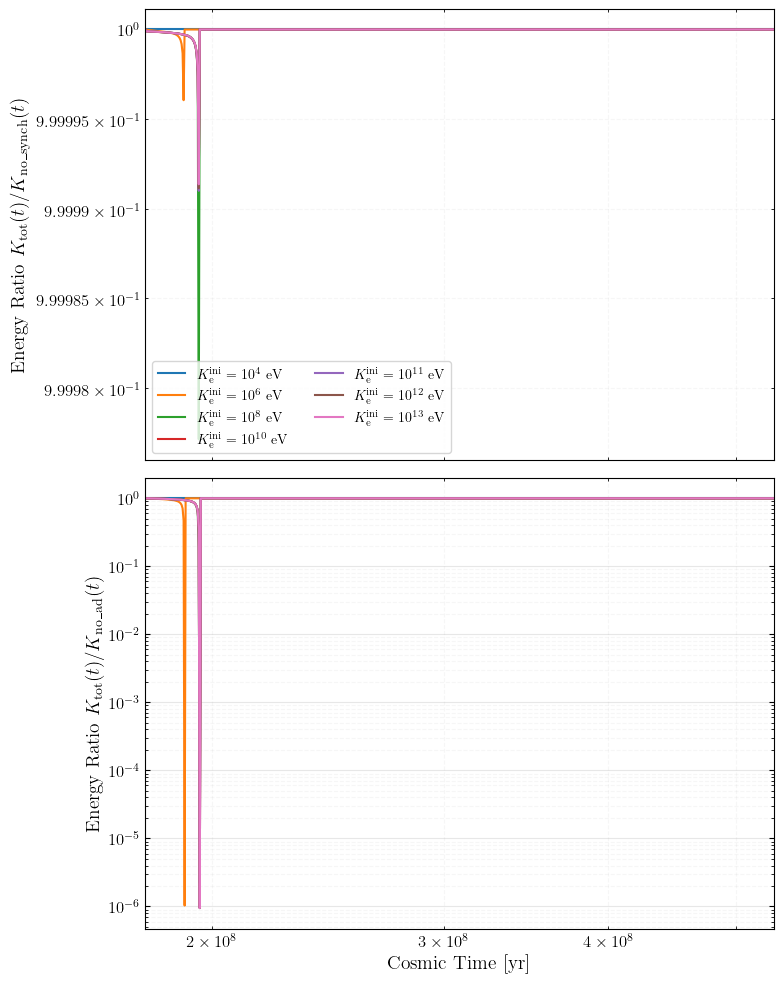

In [25]:
# --- 5. Ejecución y Gráficos ---
initial_kinetic_energies_eV = np.array([1e4, 1e6, 1e8, 1e10, 1e11, 1e12, 1e13])
initial_kinetic_energies_J = initial_kinetic_energies_eV * EV_MKS

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.0, 10.0), sharex=True)

for i, K_init_J in enumerate(initial_kinetic_energies_J):
    K_tot = solve_evolution(K_init_J, include_synch=True, include_ad=True)
    K_no_sync = solve_evolution(K_init_J, include_synch=False, include_ad=True)
    K_no_ad = solve_evolution(K_init_J, include_synch=True, include_ad=False)
    
    # Ratios (Avoiding division by zero errors near absolute limits is inherently handled since thermal floor is strictly > 0)
    ratio_sync = K_tot / K_no_sync
    ratio_ad = K_tot / K_no_ad
    
    exp_val = int(np.log10(initial_kinetic_energies_eV[i]))
    label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    ax1.plot(cosmic_t_years, ratio_sync, label=label_str, lw=1.5)
    ax2.plot(cosmic_t_years, ratio_ad, label=label_str, lw=1.5)

# --- Formato ---
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel(r'Energy Ratio $K_{\mathrm{tot}}(t) / K_{\mathrm{no\_synch}}(t)$', fontsize=14)
ax1.grid(True, which="minor", ls="--", alpha=0.1)
ax1.legend(loc='lower left', fontsize=10, ncol=2, frameon=True)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Cosmic Time [yr]', fontsize=14)
ax2.set_ylabel(r'Energy Ratio $K_{\mathrm{tot}}(t) / K_{\mathrm{no\_ad}}(t)$', fontsize=14)
ax2.set_xlim(t_init/YEAR_MKS, 3*t_init/YEAR_MKS)
ax2.grid(True, which="minor", ls="--", alpha=0.1)

plt.tight_layout()
plt.show()

In [26]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.integrate import solve_ivp, quad, nquad
from scipy.special import genlaguerre, spherical_jn, roots_laguerre
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u
import warnings

#warnings.filterwarnings("ignore", category=IntegrationWarning)

# --- 1. Physical Constants (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
YEAR_MKS = 3.15569251e7
VACUUM_PERMEABILITY_NORM = 1.00000000055
ELECTRON_MASS_MKS = 9.1093837139e-31
T_CMB_0 = 2.7255
U_CMB_0_J_M3 = 4.17e-14  

EV_MKS = ELECTRON_CHARGE_MKS
PLANCK_CONSTANT_REDUCED_MKS = PLANCK_CONSTANT_MKS / (2.0 * np.pi)
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS**2)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS**2 / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS**2 / (2.0 * VACUUM_PERMITTIVITY * PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS)
RY_ENERGY_MKS = FINE_STRUCTURE_CONSTANT**2 * ELECTRON_REST_ENERGY_MKS / 2.0
THOMSON_CROSS_SECTION_MKS = (8.0 * np.pi / 3.0) * ELECTRON_RADIUS_MKS**2
BOHR_RADIUS_MKS = PLANCK_CONSTANT_REDUCED_MKS / (ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * FINE_STRUCTURE_CONSTANT)

E0 = ELECTRON_REST_ENERGY_MKS

# --- Astrophysical & Plasma Parameters ---
B0 = 1e-9 * 1e-4  # 1 nG in Tesla
ION_FRACTION = 1e-4  
Z_target = 1.0 
delta_gould = 0.5 
threshold_eV_ion = RY_ENERGY_MKS / EV_MKS
threshold_eV_exc = 10.204

# --- 2. Cosmological Interpolations ---
z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

z_grid = np.logspace(-3, np.log10(z_init + 5), 5000)
z_grid = np.insert(z_grid, 0, 0.0)
t_grid = Planck18.age(z_grid).to(u.s).value

# Interpolators require strictly increasing x-axis
t_grid_sort = t_grid[::-1]
z_grid_sort = z_grid[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")
H_interp = interp1d(t_grid_sort, Planck18.H(z_grid_sort).to(u.s**-1).value, kind='cubic', fill_value="extrapolate")

cosmic_t_years = np.logspace(np.log10(t_init/YEAR_MKS), np.log10(t_final/YEAR_MKS), 1000)
t_eval = cosmic_t_years * YEAR_MKS
z_eval = z_interp(t_eval)

# --- 3. Physics Pre-computations ---
print("Pre-calculating cross-sections and kernels...")
def compute_F_KN(b_val):
    if b_val < 1e-4: return 1.0
    def integrand(q, x):
        if x < 1e-5: planck = x**2
        elif x > 100: return 0.0
        else: planck = x**3 / (np.exp(x) - 1.0)
        
        if q <= 0: return planck
        xb = x * b_val
        kernel = 2*q*np.log(q) + (1+2*q)*(1-q) + ((xb*q)**2 * (1-q))/(2*(1+xb*q))
        return planck * kernel / (1 + xb*q)**3
    res, _ = nquad(integrand, [[0, 1], [0, 100]], opts=[{'limit': 50}, {'limit': 50}])
    return res * 45.0 / (np.pi**4)

b_grid = np.logspace(-4, 4, 50)
F_KN_interp = interp1d(b_grid, np.array([compute_F_KN(b) for b in b_grid]), kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

_laguerre_x, _laguerre_w = roots_laguerre(70)
def calculate_sigma_hydrogen_universal(T, n):
    if T <= 10.204: return 0.0
    a0, R, mc2 = BOHR_RADIUS_MKS * 1e10, RY_ENERGY_MKS / EV_MKS, ELECTRON_REST_ENERGY_MKS / EV_MKS
    params = {2: [10.204, 0.4164, 0.555512, 0.271785, 0.000112], 3: [12.094, 0.0791, 0.089083, 0.060202,-0.019775]}
    if n not in params: return 0.0 
    E, f0, a_bethe, b_bethe, c_bethe = params[n]
    if T < 3000:
        q_min, q_max = (np.sqrt(T) - np.sqrt(T - E))**2 / R, (np.sqrt(T) + np.sqrt(T - E))**2 / R
        def exact_gos(Q):
            q, norm = np.sqrt(max(Q, 1e-12)), np.sqrt((2.0/n)**3 * math.factorial(n-2) / (2*n*math.factorial(n+1)))
            r = _laguerre_x / (1.0 + 1.0/n)
            poly_part = 2.0 * norm * (2.0*r/n) * genlaguerre(n-2, 3)(2.0*r/n) * spherical_jn(1, q*r) * (r**2) * np.sqrt(3)
            return ((1.0 - 1.0/(n**2)) / max(Q, 1e-12)) * (np.sum(_laguerre_w * poly_part) / (1.0 + 1.0/n))**2
        f_pwb_val, _ = quad(lambda Q: exact_gos(Q) / (E/R) / Q, q_min, q_max, limit=200)
        return (4 * np.pi * a0**2 * R / T) * f_pwb_val * (T / (T + R + E))
    elif T < 1e5:
        return ((4 * np.pi * a0**2 * R) / (T + R + E)) * (a_bethe * np.log(T / R) + b_bethe + (c_bethe * R / T))
    else:
        gamma, beta2 = 1 + (T / mc2), 1.0 - 1.0 / ((1 + (T / mc2))**2)
        return ((8 * np.pi * a0**2 / beta2) * (R / mc2)) * (a_bethe * (np.log(gamma**2 - 1.0) - beta2) + b_bethe - a_bethe * np.log(2 * R / mc2))

K_e_grid = np.logspace(np.log10(10.204), 13, 500) 
loss_array_exc = np.array([sum(calculate_sigma_hydrogen_universal(K_e, n) * 1e-20 * E for n, E in zip([2,3], [10.204, 12.094]) if K_e > E) for K_e in K_e_grid])
loss_interp_exc = interp1d(K_e_grid, loss_array_exc, kind='cubic', fill_value=0.0, bounds_error=False)

DipoleFit = [-0.0224728, 1.177455, -0.4626461, 0.08906479] 
DipoleIntegralFit = np.array([df / (j + 2) for j, df in enumerate(DipoleFit)])
DipoleIntegralSum, DipoleStrength = np.sum(DipoleIntegralFit), 2.0 - np.sum([df / (j + 1) for j, df in enumerate(DipoleFit)])
def coll_ionisation_cross_section(K):
    if K <= RY_ENERGY_MKS: return 0.0
    k, k_b, b, e = K / E0, K / RY_ENERGY_MKS, RY_ENERGY_MKS / E0, 1.0 + K / E0
    v2, bv2 = 1.0 - 1.0 / (e**2), 1.0 - 1.0 / ((1.0 + b)**2)
    integral = DipoleIntegralFit[-1]
    for i in range(2, -1, -1): integral = integral * (2.0 / (k_b + 1.0)) + DipoleIntegralFit[i]
    t1 = (np.log(0.5 * k_b * (e + 1.0)) - v2) * (DipoleIntegralSum - integral * (2.0 / (k_b + 1.0))**2)
    t2 = ((0.5 * (k_b - 1.0) * b**2 - np.log(k_b) * (e + k) / (1.0 + k_b)) / (1.0 + 0.5 * k)**2 + 1.0 - 1.0 / k_b) * DipoleStrength
    return (2.0 * np.pi * ELECTRON_RADIUS_MKS**2 / (b * (v2 + 2 * bv2))) * (t1 + t2)

loss_array_ion = []
for K_e in K_e_grid:
    if K_e <= threshold_eV_ion: loss_array_ion.append(0.0)
    else:
        eps_max = (K_e - threshold_eV_ion) / 2.0
        n_int, _ = quad(lambda eps: 1.0 / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        e_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        loss_array_ion.append(coll_ionisation_cross_section(K_e * EV_MKS) * (threshold_eV_ion + (e_int/n_int if n_int>0 else 0.0)))
loss_interp_ion = interp1d(K_e_grid, np.array(loss_array_ion), kind='cubic', fill_value=0.0, bounds_error=False)


# --- 4. Fast Evaluator & Vectorized Component Processor ---
def fast_total_cooling_rate(t, K):
    """Scalar evaluator strictly optimized for solve_ivp inside Radau method."""
    K_val = K[0]
    if K_val <= 0: return [0.0]
    
    E_val = K_val + E0
    gamma = E_val / E0
    z = float(z_interp(t))
    
    p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
    v = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
    n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
    
    L_ad = float(H_interp(t)) * p_sqrd_c_sqrd / E_val
    
    U_B = ((B0 * (1 + z)**2)**2) / (2 * VACUUM_PERMEABILITY)
    L_synch = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p_sqrd_c_sqrd
    
    T_CMB_z, U_CMB_z = T_CMB_0 * (1.0 + z), U_CMB_0_J_M3 * (1 + z)**4
    L_ic = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z / E0**2) * p_sqrd_c_sqrd * float(F_KN_interp(4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0))
    
    n_e = ION_FRACTION * n_HI_z
    x = np.sqrt(K_val / E0) * v * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * np.sqrt(n_e * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS)))
    L_coulomb = 0.0
    if x > 0:
        fb = math.log(x) + math.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
        L_coulomb = (n_e * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * fb / (4.0 * math.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * v**2)) * v

    K_eV = K_val / EV_MKS
    L_exc = (n_HI_z * v * float(loss_interp_exc(K_eV))) * EV_MKS if K_eV >= threshold_eV_exc else 0.0
    L_ion = (n_HI_z * v * float(loss_interp_ion(K_eV))) * EV_MKS if K_eV >= threshold_eV_ion else 0.0

    return [-(L_ad + L_synch + L_ic + L_coulomb + L_exc + L_ion)]

def compute_loss_components(t_arr, K_arr):
    """Vectorized processor applied only once per calculated trajectory path."""
    L_ad, L_synch, L_total = np.zeros_like(t_arr), np.zeros_like(t_arr), np.zeros_like(t_arr)
    
    for i, (t, K_val) in enumerate(zip(t_arr, K_arr)):
        E_val, K_eV, gamma = K_val + E0, K_val / EV_MKS, (K_val + E0) / E0
        z = z_interp(t)
        p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
        v = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
        n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
        
        rate_ad = H_interp(t) * p_sqrd_c_sqrd / E_val
        U_B = ((B0 * (1 + z)**2)**2) / (2 * VACUUM_PERMEABILITY)
        rate_synch = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p_sqrd_c_sqrd
        T_CMB_z, U_CMB_z = T_CMB_0 * (1.0 + z), U_CMB_0_J_M3 * (1 + z)**4
        rate_ic = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z / E0**2) * p_sqrd_c_sqrd * F_KN_interp(4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0)
        
        n_e = ION_FRACTION * n_HI_z
        x = np.sqrt(K_val / E0) * v * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * np.sqrt(n_e * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS)))
        rate_coulomb = 0.0
        if x > 0:
            fb = math.log(x) + math.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
            rate_coulomb = (n_e * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * fb / (4.0 * math.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * v**2)) * v

        rate_exc = (n_HI_z * v * loss_interp_exc(K_eV)) * EV_MKS if K_eV >= threshold_eV_exc else 0.0
        rate_ion = (n_HI_z * v * loss_interp_ion(K_eV)) * EV_MKS if K_eV >= threshold_eV_ion else 0.0

        L_ad[i] = rate_ad
        L_synch[i] = rate_synch
        L_total[i] = rate_ad + rate_synch + rate_ic + rate_coulomb + rate_exc + rate_ion
        
    return L_ad, L_synch, L_total

def thermalization_limit(t, K):
    return K[0] - (BOLTZMANN_CONSTANT_MKS * T_CMB_0 * (1.0 + z_interp(t)))
thermalization_limit.terminal = True
thermalization_limit.direction = -1



Pre-calculating cross-sections and kernels...


/tmp/ipykernel_5870/118643901.py:129: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  n_int, _ = quad(lambda eps: 1.0 / (1.0 + (eps/8.0)**2.1), 0, eps_max)
/tmp/ipykernel_5870/118643901.py:129: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  n_int, _ = quad(lambda eps: 1.0 / (1.0 + (eps/8.0)**2.1), 0, eps_max)
/tmp/ipykernel_5870/118643901.py:130: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  e_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max)


Integrating trajectories and calculating loss ratios...


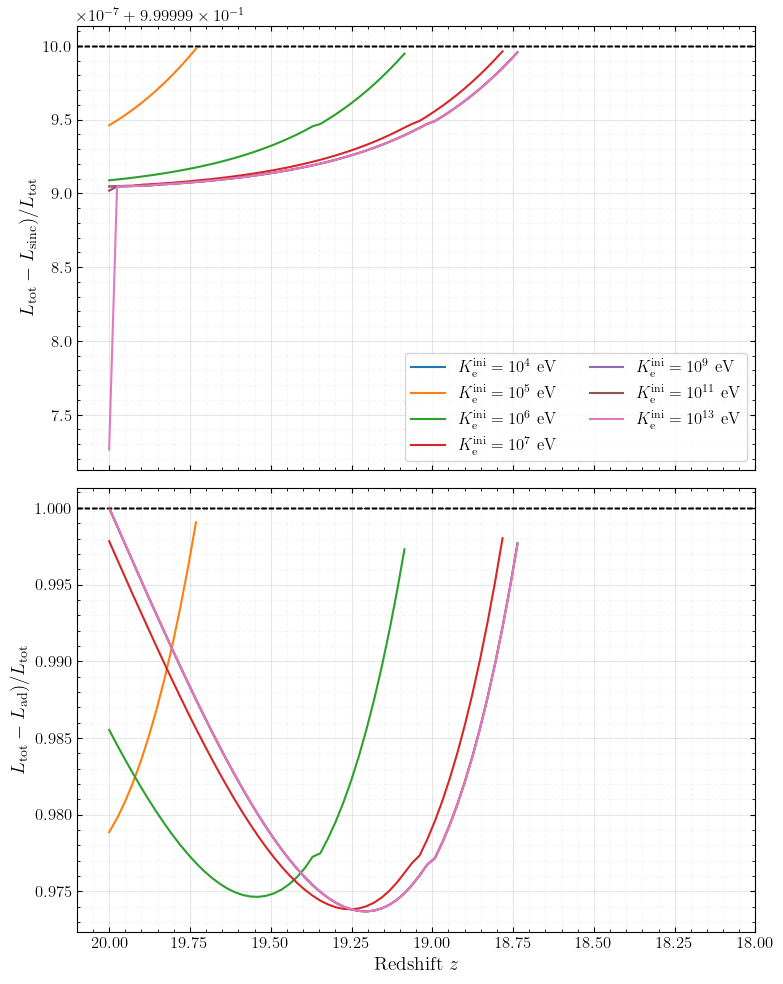

In [27]:

# --- 5. Integration and Plotting ---
initial_kinetic_energies_eV = np.array([1e4,1e5, 1e6, 1e7, 1e9, 1e11, 1e13])
initial_kinetic_energies_J = initial_kinetic_energies_eV * EV_MKS

print("Integrating trajectories and calculating loss ratios...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.0, 10.0), sharex=True)

for i, K_init_J in enumerate(initial_kinetic_energies_J):
    sol = solve_ivp(fast_total_cooling_rate, 
                    t_span=(t_eval[0], t_eval[-1]), 
                    y0=[K_init_J], 
                    events=thermalization_limit,
                    dense_output=True,
                    method='Radau', 
                    rtol=1e-6, atol=1e-25)
    
    t_terminal = sol.t[-1]
    active_mask = t_eval <= t_terminal
    
    # Process physical components solely for active epochs mapping
    K_active = sol.sol(t_eval[active_mask])[0]
    L_ad, L_synch, L_total = compute_loss_components(t_eval[active_mask], K_active)
    
    # Calculate Ratios (Protected against exact 100% loss zero-division singularities)
    ratio_synch = np.maximum(L_total - L_synch, 1e-100) / L_total
    ratio_ad = np.maximum(L_total - L_ad, 1e-100) / L_total
    
    exp_val = int(np.log10(initial_kinetic_energies_eV[i]))
    label_str = rf'$K_{{\mathrm{{e}}}}^{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV'
    
    # X-Axis corresponds to Active Redshift
    ax1.plot(z_eval[active_mask], ratio_synch, label=label_str, lw=1.5)
    ax2.plot(z_eval[active_mask], ratio_ad, label=label_str, lw=1.5)
    ax1.axhline(y=1.0, color='k', lw=1.0, ls='--', alpha=0.5)
    ax2.axhline(y=1.0, color='k', lw=1.0, ls='--', alpha=0.5)

# --- Formatting ---
#locmaj = ticker.LogLocator(base=10.0, numticks=15)

ax1.set_xscale('linear')
ax1.set_yscale('linear')
#ax1.yaxis.set_major_locator(locmaj)
ax1.set_ylabel(r'$L_{\mathrm{tot}} - L_{\mathrm{sinc}}) / L_{\mathrm{tot}}$', fontsize=14)
#ax1.set_ylim(bottom=1.0)
ax1.grid(True, which="minor", ls="--", alpha=0.1)
ax1.grid(True, which="major", ls="-", alpha=0.3)
ax1.legend(loc='lower right', fontsize=12, ncol=2, frameon=True)

ax2.set_xscale('linear')
ax2.set_yscale('linear')
#ax2.yaxis.set_major_locator(locmaj)
ax2.set_xlabel('Redshift $z$', fontsize=14)
ax2.set_ylabel(r'$L_{\mathrm{tot}} - L_{\mathrm{ad}}) / L_{\mathrm{tot}}$', fontsize=14)

# Redshift configuration: high z (early universe) to low z (late universe)
ax2.set_xlim(z_init+0.1, 18)

ax2.grid(True, which="minor", ls="--", alpha=0.1)
ax2.grid(True, which="major", ls="-", alpha=0.3)

plt.tight_layout()
plt.savefig("energy_loss_ratios-Z_20.png", dpi=300)
plt.show()


In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from scipy.integrate import solve_ivp, quad, nquad
from scipy.special import genlaguerre, spherical_jn, roots_laguerre
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u
import warnings

warnings.filterwarnings("ignore", category=IntegrationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- 1. Publication-Quality Formatting ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 14,
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "lines.linewidth": 1.5
})

# --- 2. Physical Constants (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
YEAR_MKS = 3.15569251e7
VACUUM_PERMEABILITY_NORM = 1.00000000055
ELECTRON_MASS_MKS = 9.1093837139e-31
T_CMB_0 = 2.7255
U_CMB_0_J_M3 = 4.17e-14  

EV_MKS = ELECTRON_CHARGE_MKS
PLANCK_CONSTANT_REDUCED_MKS = PLANCK_CONSTANT_MKS / (2.0 * np.pi)
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS**2)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS**2 / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS**2 / (2.0 * VACUUM_PERMITTIVITY * PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS)
RY_ENERGY_MKS = FINE_STRUCTURE_CONSTANT**2 * ELECTRON_REST_ENERGY_MKS / 2.0
THOMSON_CROSS_SECTION_MKS = (8.0 * np.pi / 3.0) * ELECTRON_RADIUS_MKS**2
BOHR_RADIUS_MKS = PLANCK_CONSTANT_REDUCED_MKS / (ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * FINE_STRUCTURE_CONSTANT)

E0 = ELECTRON_REST_ENERGY_MKS

# --- Astrophysical Parameters ---
B0 = 1e-9 * 1e-4  
ION_FRACTION = 1e-4
Z_target = 1.0 
delta_gould = 0.5 
threshold_eV_ion = RY_ENERGY_MKS / EV_MKS
threshold_eV_exc = 10.204

z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

z_array_interp = np.logspace(-3, np.log10(z_init + 5), 10000)
z_array_interp = np.insert(z_array_interp, 0, 0.0)
t_array_interp = Planck18.age(z_array_interp).to(u.s).value

t_grid_sort = t_array_interp[::-1]
z_grid_sort = z_array_interp[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")
H_interp = interp1d(t_grid_sort, Planck18.H(z_grid_sort).to(u.s**-1).value, kind='cubic', fill_value="extrapolate")

# --- 3. Physics Pre-computations (Cross Sections & Kernels) ---
print("Pre-calculating kernels...")
def compute_F_KN(b_val):
    if b_val < 1e-4: return 1.0
    def integrand(q, x):
        if x < 1e-5: planck = x**2
        elif x > 100: return 0.0
        else: planck = x**3 / (np.exp(x) - 1.0)
        
        if q <= 0: return planck
        xb = x * b_val
        kernel = 2*q*np.log(q) + (1+2*q)*(1-q) + ((xb*q)**2 * (1-q))/(2*(1+xb*q))
        return planck * kernel / (1 + xb*q)**3
    res, _ = nquad(integrand, [[0, 1], [0, 100]], opts=[{'limit': 50}, {'limit': 50}])
    return res * 45.0 / (np.pi**4)

b_grid = np.logspace(-4, 4, 50)
F_KN_interp = interp1d(b_grid, np.array([compute_F_KN(b) for b in b_grid]), kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

_laguerre_x, _laguerre_w = roots_laguerre(70)
def calculate_sigma_hydrogen_universal(T, n):
    if T <= 10.204: return 0.0
    a0, R, mc2 = BOHR_RADIUS_MKS * 1e10, RY_ENERGY_MKS / EV_MKS, ELECTRON_REST_ENERGY_MKS / EV_MKS
    params = {2: [10.204, 0.4164, 0.555512, 0.271785, 0.000112], 3: [12.094, 0.0791, 0.089083, 0.060202,-0.019775]}
    if n not in params: return 0.0 
    E, f0, a_bethe, b_bethe, c_bethe = params[n]
    if T < 3000:
        q_min, q_max = (np.sqrt(T) - np.sqrt(T - E))**2 / R, (np.sqrt(T) + np.sqrt(T - E))**2 / R
        def exact_gos(Q):
            q, norm = np.sqrt(max(Q, 1e-12)), np.sqrt((2.0/n)**3 * math.factorial(n-2) / (2*n*math.factorial(n+1)))
            r = _laguerre_x / (1.0 + 1.0/n)
            poly_part = 2.0 * norm * (2.0*r/n) * genlaguerre(n-2, 3)(2.0*r/n) * spherical_jn(1, q*r) * (r**2) * np.sqrt(3)
            return ((1.0 - 1.0/(n**2)) / max(Q, 1e-12)) * (np.sum(_laguerre_w * poly_part) / (1.0 + 1.0/n))**2
        f_pwb_val, _ = quad(lambda Q: exact_gos(Q) / (E/R) / Q, q_min, q_max, limit=200)
        return (4 * np.pi * a0**2 * R / T) * f_pwb_val * (T / (T + R + E))
    elif T < 1e5:
        return ((4 * np.pi * a0**2 * R) / (T + R + E)) * (a_bethe * np.log(T / R) + b_bethe + (c_bethe * R / T))
    else:
        gamma, beta2 = 1 + (T / mc2), 1.0 - 1.0 / ((1 + (T / mc2))**2)
        return ((8 * np.pi * a0**2 / beta2) * (R / mc2)) * (a_bethe * (np.log(gamma**2 - 1.0) - beta2) + b_bethe - a_bethe * np.log(2 * R / mc2))

K_e_grid_eval = np.logspace(np.log10(10.204), 14, 500) 
loss_array_exc = np.array([sum(calculate_sigma_hydrogen_universal(K_e, n) * 1e-20 * E for n, E in zip([2,3], [10.204, 12.094]) if K_e > E) for K_e in K_e_grid_eval])
loss_interp_exc = interp1d(K_e_grid_eval, loss_array_exc, kind='cubic', fill_value=0.0, bounds_error=False)

DipoleFit = [-0.0224728, 1.177455, -0.4626461, 0.08906479] 
DipoleIntegralFit = np.array([df / (j + 2) for j, df in enumerate(DipoleFit)])
DipoleIntegralSum, DipoleStrength = np.sum(DipoleIntegralFit), 2.0 - np.sum([df / (j + 1) for j, df in enumerate(DipoleFit)])
def coll_ionisation_cross_section(K):
    if K <= RY_ENERGY_MKS: return 0.0
    k, k_b, b, e = K / E0, K / RY_ENERGY_MKS, RY_ENERGY_MKS / E0, 1.0 + K / E0
    v2, bv2 = 1.0 - 1.0 / (e**2), 1.0 - 1.0 / ((1.0 + b)**2)
    integral = DipoleIntegralFit[-1]
    for i in range(2, -1, -1): integral = integral * (2.0 / (k_b + 1.0)) + DipoleIntegralFit[i]
    t1 = (np.log(0.5 * k_b * (e + 1.0)) - v2) * (DipoleIntegralSum - integral * (2.0 / (k_b + 1.0))**2)
    t2 = ((0.5 * (k_b - 1.0) * b**2 - np.log(k_b) * (e + k) / (1.0 + k_b)) / (1.0 + 0.5 * k)**2 + 1.0 - 1.0 / k_b) * DipoleStrength
    return (2.0 * np.pi * ELECTRON_RADIUS_MKS**2 / (b * (v2 + 2 * bv2))) * (t1 + t2)

loss_array_ion = []
for K_e in K_e_grid_eval:
    if K_e <= threshold_eV_ion: loss_array_ion.append(0.0)
    else:
        eps_max = (K_e - threshold_eV_ion) / 2.0
        n_int, _ = quad(lambda eps: 1.0 / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        e_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        loss_array_ion.append(coll_ionisation_cross_section(K_e * EV_MKS) * (threshold_eV_ion + (e_int/n_int if n_int>0 else 0.0)))
loss_interp_ion = interp1d(K_e_grid_eval, np.array(loss_array_ion), kind='cubic', fill_value=0.0, bounds_error=False)


# --- 4. Scalar ODE Evaluator ---
def fast_total_cooling_rate(t, K):
    K_val = K[0]
    if K_val <= 0: return [0.0]
    
    E_val = K_val + E0
    gamma = E_val / E0
    z = float(z_interp(t))
    
    p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
    v = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
    n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
    
    L_ad = float(H_interp(t)) * p_sqrd_c_sqrd / E_val
    U_B = ((B0 * (1 + z)**2)**2) / (2 * VACUUM_PERMEABILITY)
    L_synch = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p_sqrd_c_sqrd
    T_CMB_z, U_CMB_z = T_CMB_0 * (1.0 + z), U_CMB_0_J_M3 * (1 + z)**4
    L_ic = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z / E0**2) * p_sqrd_c_sqrd * float(F_KN_interp(4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0))
    
    n_e = ION_FRACTION * n_HI_z
    x = np.sqrt(K_val / E0) * v * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * np.sqrt(n_e * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS)))
    L_coulomb = 0.0
    if x > 0:
        fb = math.log(x) + math.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
        L_coulomb = (n_e * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * fb / (4.0 * math.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * v**2)) * v

    K_eV = K_val / EV_MKS
    L_exc = (n_HI_z * v * float(loss_interp_exc(K_eV))) * EV_MKS if K_eV >= threshold_eV_exc else 0.0
    L_ion = (n_HI_z * v * float(loss_interp_ion(K_eV))) * EV_MKS if K_eV >= threshold_eV_ion else 0.0

    return [-(L_ad + L_synch + L_ic + L_coulomb + L_exc + L_ion)]

def thermalization_limit(t, K):
    return K[0] - (BOLTZMANN_CONSTANT_MKS * T_CMB_0 * (1.0 + z_interp(t)))
thermalization_limit.terminal = True
thermalization_limit.direction = -1


# --- 5. 2D Phase Space Grid Evaluation ---
print("Evaluating 2D Phase Space Grid...")
z_resolution = 1000
K_resolution = 600

z_grid_1d = np.linspace(z_final, z_init, z_resolution)
Ke_eV_grid_1d = np.logspace(0, 14, K_resolution)

Z_mesh, Ke_eV_mesh = np.meshgrid(z_grid_1d, Ke_eV_grid_1d)

# Vectorized Kinematics
K_J_mesh = Ke_eV_mesh * EV_MKS
E_tot_mesh = K_J_mesh + E0
gamma_mesh = E_tot_mesh / E0
p2c2_mesh = K_J_mesh**2 + 2 * K_J_mesh * E0
v_mesh = LIGHT_SPEED_MKS * np.sqrt(p2c2_mesh) / E_tot_mesh

# Cosmological Field Mapping
n_HI_mesh = 1.8e3 * ((1.0 + Z_mesh) / 21.0)**3
n_e_mesh = ION_FRACTION * n_HI_mesh
H_mesh = Planck18.H(Z_mesh).to(u.s**-1).value
U_B_mesh = ((B0 * (1 + Z_mesh)**2)**2) / (2 * VACUUM_PERMEABILITY)
T_CMB_mesh = T_CMB_0 * (1.0 + Z_mesh)
U_CMB_mesh = U_CMB_0_J_M3 * (1 + Z_mesh)**4

# 0: Adiabatic Loss Map
L_ad_map = H_mesh * p2c2_mesh / E_tot_mesh

# 1: Synchrotron Loss Map
L_synch_map = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B_mesh / E0**2) * p2c2_mesh

# 2: Inverse Compton Loss Map
b_KN_mesh = 4.0 * gamma_mesh * BOLTZMANN_CONSTANT_MKS * T_CMB_mesh / E0
L_ic_map = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_mesh / E0**2) * p2c2_mesh * F_KN_interp(b_KN_mesh)

# 3: Coulomb Loss Map
plasma_freq_mesh = np.sqrt(n_e_mesh * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS))
x_mesh = np.sqrt(K_J_mesh / E0) * v_mesh * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * plasma_freq_mesh)
x_mesh = np.maximum(x_mesh, 1e-50) # Safe log evaluation
fb_mesh = np.log(x_mesh) + np.log(1.0 - delta_gould) * (0.5 + 1.0/gamma_mesh - 0.5/(gamma_mesh**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma_mesh)**2) * (delta_gould**2)
L_coulomb_map = np.where(x_mesh > 1e-40, (n_e_mesh * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * fb_mesh / (4.0 * np.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * v_mesh**2)) * v_mesh, 0.0)

# 4 & 5: Excitation and Ionization Loss Maps
L_exc_map = np.where(Ke_eV_mesh >= threshold_eV_exc, (n_HI_mesh * v_mesh * loss_interp_exc(Ke_eV_mesh)) * EV_MKS, 0.0)
L_ion_map = np.where(Ke_eV_mesh >= threshold_eV_ion, (n_HI_mesh * v_mesh * loss_interp_ion(Ke_eV_mesh)) * EV_MKS, 0.0)

# Stack and determine the index of the dominant mechanism
Loss_Stack = np.stack((L_ad_map, L_synch_map, L_ic_map, L_coulomb_map, L_exc_map, L_ion_map))
dominant_idx_map = np.argmax(Loss_Stack, axis=0)

# --- 4. Kinematic Threshold Vectorization ---
print("Pre-calculating kinematic thresholds...")
def compute_threshold_curves(z_array, min_sim_eV=10.2, target_upscatter_eV=1e3, losing_tolerance=1e-2):
    total_planck_area = 2.4041138
    
    def planck_integrand(x):
        if x < 1e-8: return x
        return (x * x) / np.expm1(x)
        
    # 1. Roots are constant and scale-independent
    max_area = total_planck_area * (1.0 - losing_tolerance)
    res_max = root_scalar(lambda x: quad(planck_integrand, 0, x)[0] - max_area, bracket=[1e-5, 50.0])
    x_max_val = res_max.root
    
    min_area = total_planck_area * 0.01
    res_min = root_scalar(lambda x: quad(planck_integrand, 0, x)[0] - min_area, bracket=[1e-5, 10.0])
    x_min_val = res_min.root
    
    # 2. Vectorized evaluation for array of z
    cmb_energy_0 = BOLTZMANN_CONSTANT_MKS * T_CMB_0
    thermal_energy = cmb_energy_0 * (1.0 + z_array)
    
    max_photon_energy = x_max_val * thermal_energy
    min_photon_energy_99 = x_min_val * thermal_energy
    
    # param_values_6 calculation
    min_sim_J = min_sim_eV * EV_MKS
    ratio_rest_max = min_sim_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_max = min_sim_J / max_photon_energy
    g_max = ratio_rest_max + np.sqrt(ratio_rest_max**2 + ratio_phot_max)
    gamma_cut = (g_max**2 + 1.0) / (2.0 * g_max)
    ke_cutoff_array = ELECTRON_REST_ENERGY_MKS * (gamma_cut - 1.0) / EV_MKS
    
    # ke_99_percent_scatter calculation
    target_J = target_upscatter_eV * EV_MKS
    ratio_rest_min = target_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_min = target_J / min_photon_energy_99
    g_min = ratio_rest_min + np.sqrt(ratio_rest_min**2 + ratio_phot_min)
    gamma_target = (g_min**2 + 1.0) / (2.0 * g_min)
    ke_99_array = ELECTRON_REST_ENERGY_MKS * (gamma_target - 1.0) / EV_MKS
    
    return ke_cutoff_array, ke_99_array

# Compute thresholds for the global interpolation grid
ke_cutoff_array, ke_99_array = compute_threshold_curves(z_array_interp)


Pre-calculating kernels...
Evaluating 2D Phase Space Grid...


Integrating individual trajectories for overlay...


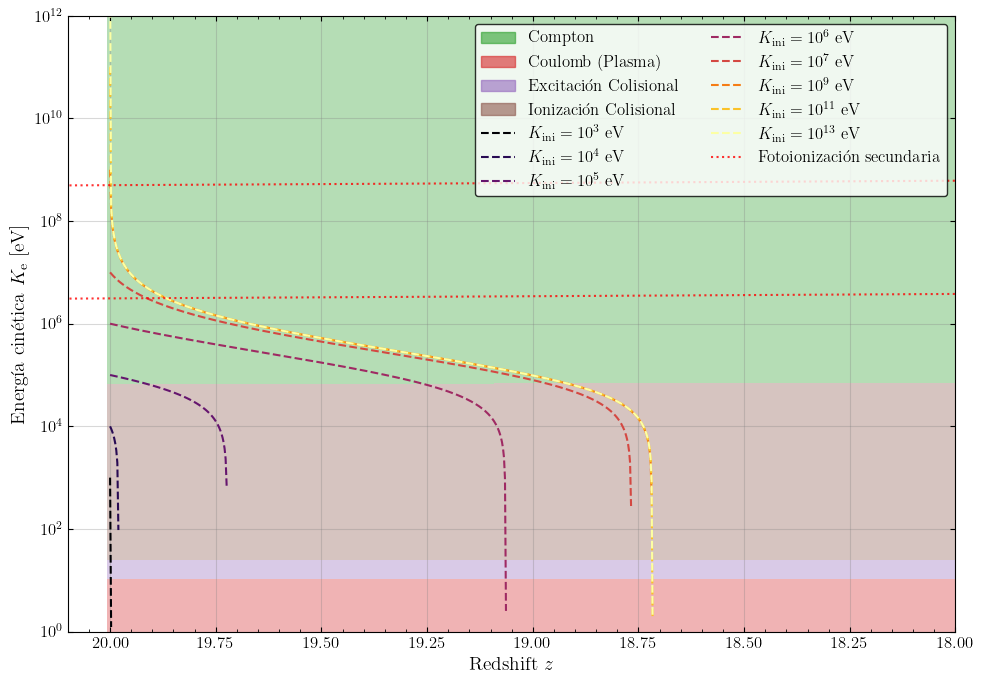

In [29]:
#--- 6. Plotting Phase Space and Trajectories ---
print("Integrating individual trajectories for overlay...")

fig, ax = plt.subplots(figsize=(10.0, 7.0))

# Define categorical colors matching mechanism indices
mechanism_names = ['Exp.Adiabática', 'Sincrotrón', 'Compton', 'Coulomb (Plasma)', 'Excitación Colisional', 'Ionización Colisional']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
cmap = ListedColormap(colors)

# Pcolormesh for Phase Space
mesh = ax.pcolormesh(Z_mesh, Ke_eV_mesh, dominant_idx_map, cmap=cmap, vmin=-0.5, vmax=5.5, shading='auto', alpha=0.35)

# Integrate trajectories and overlay
initial_energies_eV = np.array([1e3, 1e4, 1e5, 1e6, 1e7, 1e9, 1e11, 1e13])
t_eval = np.logspace(np.log10(t_init), np.log10(t_final), 10000)

# Generar paleta de colores para las trayectorias
trajectory_colors = plt.cm.inferno(np.linspace(0, 1, len(initial_energies_eV)))

for i, K_ini_eV in enumerate(initial_energies_eV):
    K_ini_J = K_ini_eV * EV_MKS
    sol = solve_ivp(fast_total_cooling_rate, 
                    t_span=(t_eval[0], t_eval[-1]), 
                    y0=[K_ini_J], 
                    events=thermalization_limit,
                    dense_output=True,
                    method='Radau', 
                    rtol=1e-6, atol=1e-25)
    
    active_mask = t_eval <= sol.t[-1]
    K_active_eV = sol.sol(t_eval[active_mask])[0] / EV_MKS
    z_active = z_interp(t_eval[active_mask])
    
    exp_val = int(np.log10(K_ini_eV))
    
    # Trazar la curva usando el color correspondiente y añadiendo el label para la leyenda
    ax.plot(z_active, K_active_eV, color=trajectory_colors[i], lw=1.5, ls='--', label=rf'$K_{{\mathrm{{ini}}}} = 10^{{{exp_val}}}$ eV')

# Formatting 
ax.set_yscale('log')
ax.set_xlim(z_init + 0.1, 18)
ax.set_ylim(1e0, 1e12)
#ax.invert_xaxis() 
ax.plot(z_array_interp, 3.11e6*((1+z_init)/(1+z_array_interp))**2, color='red', linestyle=':', alpha=0.8, label=r'Fotoionización secundaria')
ax.plot(z_array_interp, 5e8*((1+z_init)/(1+z_array_interp))**2, color='red', linestyle=':', alpha=0.8)

ax.set_xlabel(r'Redshift $z$', fontsize=14)
ax.set_ylabel(r'Energía cinética $K_{\mathrm{e}}$ [eV]', fontsize=14)
#ax.set_title(r'Dominance Phase Space \& Electron Cooling Trajectories', fontsize=14, pad=15)

# Build custom legend based on unique dominant indices found in the domain
unique_dominant_indices = np.unique(dominant_idx_map)
legend_patches = [mpatches.Patch(color=colors[idx], label=mechanism_names[idx], alpha=0.6) for idx in unique_dominant_indices]

# Extraer los elementos gráficos de las trayectorias
line_handles, line_labels = ax.get_legend_handles_labels()

# Combinar parches de fondo y líneas de trayectoria en una única leyenda con dos columnas
all_handles = legend_patches + line_handles
ax.legend(handles=all_handles, loc='upper right', fontsize=12, frameon=True, edgecolor='black', facecolor='white', ncol=2)

# Add minor gridlines to easily track decades
ax.grid(True, which="major", ls="-", alpha=0.3, color='grey')
#ax.grid(True, which="minor", ls=":", alpha=0.15, color='grey')

plt.tight_layout()
plt.savefig('electron_cooling_phase_space-Z_20.png', dpi=300, bbox_inches='tight')
plt.show()

Integrating individual trajectories for overlay...


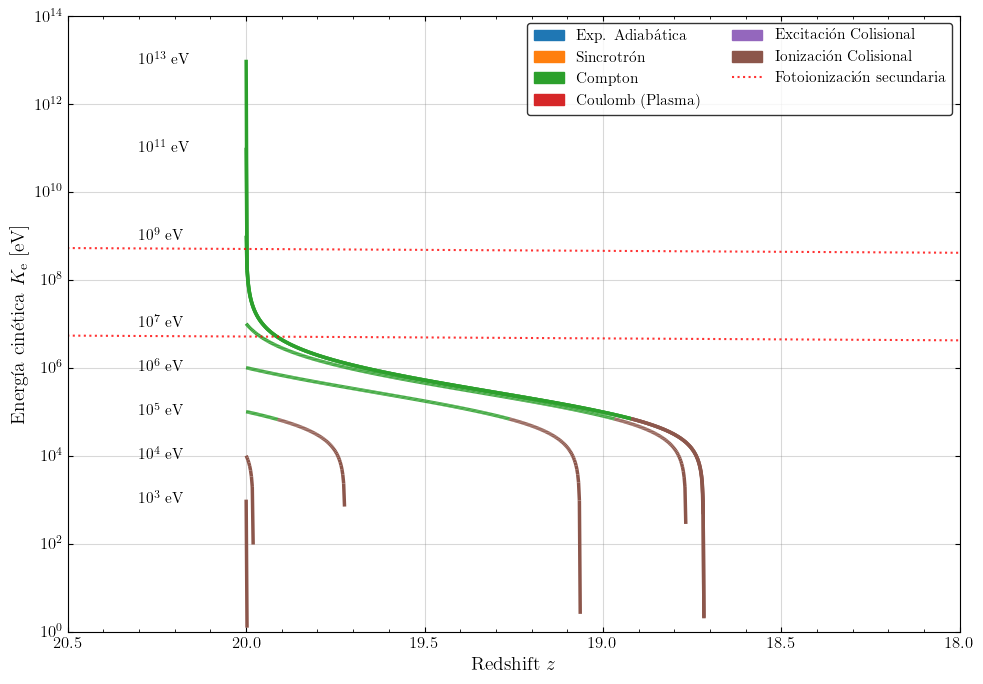

In [30]:
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches

#--- 6. Plotting Phase Space and Trajectories ---
print("Integrating individual trajectories for overlay...")

fig, ax = plt.subplots(figsize=(10.0, 7.0))

# Define categorical colors matching mechanism indices
mechanism_names = ['Exp. Adiabática', 'Sincrotrón', 'Compton', 'Coulomb (Plasma)', 'Excitación Colisional', 'Ionización Colisional']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
cmap = ListedColormap(colors)

initial_energies_eV = np.array([1e3, 1e4, 1e5, 1e6, 1e7, 1e9, 1e11, 1e13])
t_eval = np.logspace(np.log10(t_init), np.log10(t_final), 10000)

for K_ini_eV in initial_energies_eV:
    K_ini_J = K_ini_eV * EV_MKS
    sol = solve_ivp(fast_total_cooling_rate, 
                    t_span=(t_eval[0], t_eval[-1]), 
                    y0=[K_ini_J], 
                    events=thermalization_limit,
                    dense_output=True,
                    method='Radau', 
                    rtol=1e-6, atol=1e-25)
    
    active_mask = t_eval <= sol.t[-1]
    t_active = t_eval[active_mask]
    K_active_eV = sol.sol(t_active)[0] / EV_MKS
    z_active = z_interp(t_active)
    
    # 1. Re-evaluación vectorial exacta a lo largo de la trayectoria de la partícula
    K_J = K_active_eV * EV_MKS
    E_tot = K_J + E0
    gamma = E_tot / E0
    p2c2 = K_J**2 + 2 * K_J * E0
    v = LIGHT_SPEED_MKS * np.sqrt(p2c2) / E_tot
    
    n_HI = 1.8e3 * ((1.0 + z_active) / 21.0)**3
    n_e = ION_FRACTION * n_HI
    H_val = H_interp(t_active)
    U_B = ((B0 * (1 + z_active)**2)**2) / (2 * VACUUM_PERMEABILITY)
    T_CMB = T_CMB_0 * (1.0 + z_active)
    U_CMB = U_CMB_0_J_M3 * (1 + z_active)**4
    
    L_ad = H_val * p2c2 / E_tot
    L_synch = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p2c2
    b_KN = 4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB / E0
    L_ic = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB / E0**2) * p2c2 * F_KN_interp(b_KN)
    
    plasma_freq = np.sqrt(n_e * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS))
    x = np.sqrt(K_J / E0) * v * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * plasma_freq)
    x = np.maximum(x, 1e-50) 
    fb = np.log(x) + np.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
    L_coulomb = np.where(x > 1e-40, (n_e * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * fb / (4.0 * np.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * v**2)) * v, 0.0)
    
    L_exc = np.where(K_active_eV >= threshold_eV_exc, (n_HI * v * loss_interp_exc(K_active_eV)) * EV_MKS, 0.0)
    L_ion = np.where(K_active_eV >= threshold_eV_ion, (n_HI * v * loss_interp_ion(K_active_eV)) * EV_MKS, 0.0)
    
    Loss_Stack = np.stack((L_ad, L_synch, L_ic, L_coulomb, L_exc, L_ion))
    dom_idx = np.argmax(Loss_Stack, axis=0)

    # 2. Generación de segmentos para colorear la línea individualmente
    points = np.array([z_active, K_active_eV]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(-0.5, 5.5))
    lc.set_array(dom_idx[:-1])
    lc.set_linewidth(2.5)
    ax.add_collection(lc)
    
    # 3. Etiquetado (flag) in-situ para la energía inicial
    exp_val = int(np.log10(K_ini_eV))
    ax.text(z_active[0] + 0.3, K_active_eV[0], rf'$10^{{{exp_val}}}$ eV', fontsize=11, va='center', ha='left', color='black')

# Formatting 
ax.set_yscale('log')
ax.set_xlim(z_init + 0.5, 18)
ax.set_ylim(1e0, 1e14)

ax.plot(z_array_interp, 5.11e6*((1+z_array_interp)/(1+z_init))**2, color='red', linestyle=':', alpha=0.8, label=r'Fotoionización secundaria')
ax.plot(z_array_interp, 5e8*((1+z_array_interp)/(1+z_init))**2, color='red', linestyle=':', alpha=0.8)

ax.set_xlabel(r'Redshift $z$', fontsize=14)
ax.set_ylabel(r'Energía cinética $K_{\mathrm{e}}$ [eV]', fontsize=14)

# Reensamblado de la leyenda
legend_patches = [mpatches.Patch(color=colors[idx], label=mechanism_names[idx]) for idx in range(len(mechanism_names))]
line_handles, line_labels = ax.get_legend_handles_labels()
all_handles = legend_patches + line_handles

ax.legend(handles=all_handles, loc='upper right', fontsize=11, frameon=True, edgecolor='black', facecolor='white', ncol=2)
ax.grid(True, which="major", ls="-", alpha=0.3, color='grey')

plt.tight_layout()
plt.savefig('electron_cooling_phase_space_colored_curves_fion_1e-4-Z_20.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from scipy.integrate import solve_ivp, quad, nquad
from scipy.special import genlaguerre, spherical_jn, roots_laguerre
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import astropy.units as u
import warnings
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.integrate import solve_ivp, quad, nquad
from scipy.special import genlaguerre, spherical_jn, roots_laguerre
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from astropy.cosmology import Planck18
import astropy.units as u
import warnings

warnings.filterwarnings("ignore", category=IntegrationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- 1. Publication-Quality Formatting ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 14,
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "lines.linewidth": 1.5
})

# --- 2. Physical Constants (MKS) ---
LIGHT_SPEED_MKS = 2.99792458e8
PLANCK_CONSTANT_MKS = 6.62607015e-34
ELECTRON_CHARGE_MKS = 1.602176634e-19 
BOLTZMANN_CONSTANT_MKS = 1.38064852e-23
YEAR_MKS = 3.15569251e7
VACUUM_PERMEABILITY_NORM = 1.00000000055
ELECTRON_MASS_MKS = 9.1093837139e-31
T_CMB_0 = 2.7255
U_CMB_0_J_M3 = 4.17e-14  

EV_MKS = ELECTRON_CHARGE_MKS
PLANCK_CONSTANT_REDUCED_MKS = PLANCK_CONSTANT_MKS / (2.0 * np.pi)
VACUUM_PERMEABILITY = 4.0e-7 * np.pi * VACUUM_PERMEABILITY_NORM
VACUUM_PERMITTIVITY = 1.0 / (VACUUM_PERMEABILITY * LIGHT_SPEED_MKS**2)
ELECTRON_REST_ENERGY_MKS = ELECTRON_MASS_MKS * LIGHT_SPEED_MKS**2
ELECTRON_RADIUS_MKS = ELECTRON_CHARGE_MKS**2 / (4.0 * np.pi * VACUUM_PERMITTIVITY * ELECTRON_REST_ENERGY_MKS)
FINE_STRUCTURE_CONSTANT = ELECTRON_CHARGE_MKS**2 / (2.0 * VACUUM_PERMITTIVITY * PLANCK_CONSTANT_MKS * LIGHT_SPEED_MKS)
RY_ENERGY_MKS = FINE_STRUCTURE_CONSTANT**2 * ELECTRON_REST_ENERGY_MKS / 2.0
THOMSON_CROSS_SECTION_MKS = (8.0 * np.pi / 3.0) * ELECTRON_RADIUS_MKS**2
BOHR_RADIUS_MKS = PLANCK_CONSTANT_REDUCED_MKS / (ELECTRON_MASS_MKS * LIGHT_SPEED_MKS * FINE_STRUCTURE_CONSTANT)

E0 = ELECTRON_REST_ENERGY_MKS

# --- Astrophysical Parameters ---
B0 = 1e-9 * 1e-4  
ION_FRACTION = 1e-4  
Z_target = 1.0 
delta_gould = 0.5 
threshold_eV_ion = RY_ENERGY_MKS / EV_MKS
threshold_eV_exc = 10.204

z_init = 20.0  
z_final = 5.5  
t_init = Planck18.age(z_init).to(u.s).value
t_final = Planck18.age(z_final).to(u.s).value

z_array_interp = np.logspace(-3, np.log10(z_init + 5), 10000)
z_array_interp = np.insert(z_array_interp, 0, 0.0)
t_array_interp = Planck18.age(z_array_interp).to(u.s).value

t_grid_sort = t_array_interp[::-1]
z_grid_sort = z_array_interp[::-1]
z_interp = interp1d(t_grid_sort, z_grid_sort, kind='cubic', fill_value="extrapolate")
H_interp = interp1d(t_grid_sort, Planck18.H(z_grid_sort).to(u.s**-1).value, kind='cubic', fill_value="extrapolate")

# --- 3. Physics Pre-computations (Cross Sections & Kernels) ---
print("Pre-calculating kernels...")
def compute_F_KN(b_val):
    if b_val < 1e-4: return 1.0
    def integrand(q, x):
        if x < 1e-5: planck = x**2
        elif x > 100: return 0.0
        else: planck = x**3 / (np.exp(x) - 1.0)
        
        if q <= 0: return planck
        xb = x * b_val
        kernel = 2*q*np.log(q) + (1+2*q)*(1-q) + ((xb*q)**2 * (1-q))/(2*(1+xb*q))
        return planck * kernel / (1 + xb*q)**3
    res, _ = nquad(integrand, [[0, 1], [0, 100]], opts=[{'limit': 50}, {'limit': 50}])
    return res * 45.0 / (np.pi**4)

b_grid = np.logspace(-4, 4, 50)
F_KN_interp = interp1d(b_grid, np.array([compute_F_KN(b) for b in b_grid]), kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

_laguerre_x, _laguerre_w = roots_laguerre(70)
def calculate_sigma_hydrogen_universal(T, n):
    if T <= 10.204: return 0.0
    a0, R, mc2 = BOHR_RADIUS_MKS * 1e10, RY_ENERGY_MKS / EV_MKS, ELECTRON_REST_ENERGY_MKS / EV_MKS
    params = {2: [10.204, 0.4164, 0.555512, 0.271785, 0.000112], 3: [12.094, 0.0791, 0.089083, 0.060202,-0.019775]}
    if n not in params: return 0.0 
    E, f0, a_bethe, b_bethe, c_bethe = params[n]
    if T < 3000:
        q_min, q_max = (np.sqrt(T) - np.sqrt(T - E))**2 / R, (np.sqrt(T) + np.sqrt(T - E))**2 / R
        def exact_gos(Q):
            q, norm = np.sqrt(max(Q, 1e-12)), np.sqrt((2.0/n)**3 * math.factorial(n-2) / (2*n*math.factorial(n+1)))
            r = _laguerre_x / (1.0 + 1.0/n)
            poly_part = 2.0 * norm * (2.0*r/n) * genlaguerre(n-2, 3)(2.0*r/n) * spherical_jn(1, q*r) * (r**2) * np.sqrt(3)
            return ((1.0 - 1.0/(n**2)) / max(Q, 1e-12)) * (np.sum(_laguerre_w * poly_part) / (1.0 + 1.0/n))**2
        f_pwb_val, _ = quad(lambda Q: exact_gos(Q) / (E/R) / Q, q_min, q_max, limit=200)
        return (4 * np.pi * a0**2 * R / T) * f_pwb_val * (T / (T + R + E))
    elif T < 1e5:
        return ((4 * np.pi * a0**2 * R) / (T + R + E)) * (a_bethe * np.log(T / R) + b_bethe + (c_bethe * R / T))
    else:
        gamma, beta2 = 1 + (T / mc2), 1.0 - 1.0 / ((1 + (T / mc2))**2)
        return ((8 * np.pi * a0**2 / beta2) * (R / mc2)) * (a_bethe * (np.log(gamma**2 - 1.0) - beta2) + b_bethe - a_bethe * np.log(2 * R / mc2))

K_e_grid_eval = np.logspace(np.log10(10.204), 14, 500) 
loss_array_exc = np.array([sum(calculate_sigma_hydrogen_universal(K_e, n) * 1e-20 * E for n, E in zip([2,3], [10.204, 12.094]) if K_e > E) for K_e in K_e_grid_eval])
loss_interp_exc = interp1d(K_e_grid_eval, loss_array_exc, kind='linear', fill_value=0.0, bounds_error=False)

DipoleFit = [-0.0224728, 1.177455, -0.4626461, 0.08906479] 
DipoleIntegralFit = np.array([df / (j + 2) for j, df in enumerate(DipoleFit)])
DipoleIntegralSum, DipoleStrength = np.sum(DipoleIntegralFit), 2.0 - np.sum([df / (j + 1) for j, df in enumerate(DipoleFit)])
def coll_ionisation_cross_section(K):
    if K <= RY_ENERGY_MKS: return 0.0
    k, k_b, b, e = K / E0, K / RY_ENERGY_MKS, RY_ENERGY_MKS / E0, 1.0 + K / E0
    v2, bv2 = 1.0 - 1.0 / (e**2), 1.0 - 1.0 / ((1.0 + b)**2)
    integral = DipoleIntegralFit[-1]
    for i in range(2, -1, -1): integral = integral * (2.0 / (k_b + 1.0)) + DipoleIntegralFit[i]
    t1 = (np.log(0.5 * k_b * (e + 1.0)) - v2) * (DipoleIntegralSum - integral * (2.0 / (k_b + 1.0))**2)
    t2 = ((0.5 * (k_b - 1.0) * b**2 - np.log(k_b) * (e + k) / (1.0 + k_b)) / (1.0 + 0.5 * k)**2 + 1.0 - 1.0 / k_b) * DipoleStrength
    return (2.0 * np.pi * ELECTRON_RADIUS_MKS**2 / (b * (v2 + 2 * bv2))) * (t1 + t2)

loss_array_ion = []
for K_e in K_e_grid_eval:
    if K_e <= threshold_eV_ion: loss_array_ion.append(0.0)
    else:
        eps_max = (K_e - threshold_eV_ion) / 2.0
        n_int, _ = quad(lambda eps: 1.0 / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        e_int, _ = quad(lambda eps: eps / (1.0 + (eps/8.0)**2.1), 0, eps_max)
        loss_array_ion.append(coll_ionisation_cross_section(K_e * EV_MKS) * (threshold_eV_ion + (e_int/n_int if n_int>0 else 0.0)))
loss_interp_ion = interp1d(K_e_grid_eval, np.array(loss_array_ion), kind='linear', fill_value=0.0, bounds_error=False)

# --- 4. Kinematic Threshold Vectorization ---
print("Pre-calculating kinematic thresholds...")
def compute_threshold_curves(z_array, min_sim_eV=10.2, target_upscatter_eV=1e3, losing_tolerance=1e-2):
    total_planck_area = 2.4041138
    
    def planck_integrand(x):
        if x < 1e-8: return x
        return (x * x) / np.expm1(x)
        
    # 1. Roots are constant and scale-independent
    max_area = total_planck_area * (1.0 - losing_tolerance)
    res_max = root_scalar(lambda x: quad(planck_integrand, 0, x)[0] - max_area, bracket=[1e-5, 50.0])
    x_max_val = res_max.root
    
    min_area = total_planck_area * 0.01
    res_min = root_scalar(lambda x: quad(planck_integrand, 0, x)[0] - min_area, bracket=[1e-5, 10.0])
    x_min_val = res_min.root
    
    # 2. Vectorized evaluation for array of z
    cmb_energy_0 = BOLTZMANN_CONSTANT_MKS * T_CMB_0
    thermal_energy = cmb_energy_0 * (1.0 + z_array)
    
    max_photon_energy = x_max_val * thermal_energy
    min_photon_energy_99 = x_min_val * thermal_energy
    
    # param_values_6 calculation
    min_sim_J = min_sim_eV * EV_MKS
    ratio_rest_max = min_sim_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_max = min_sim_J / max_photon_energy
    g_max = ratio_rest_max + np.sqrt(ratio_rest_max**2 + ratio_phot_max)
    gamma_cut = (g_max**2 + 1.0) / (2.0 * g_max)
    ke_cutoff_array = ELECTRON_REST_ENERGY_MKS * (gamma_cut - 1.0) / EV_MKS
    
    # ke_99_percent_scatter calculation
    target_J = target_upscatter_eV * EV_MKS
    ratio_rest_min = target_J / ELECTRON_REST_ENERGY_MKS
    ratio_phot_min = target_J / min_photon_energy_99
    g_min = ratio_rest_min + np.sqrt(ratio_rest_min**2 + ratio_phot_min)
    gamma_target = (g_min**2 + 1.0) / (2.0 * g_min)
    ke_99_array = ELECTRON_REST_ENERGY_MKS * (gamma_target - 1.0) / EV_MKS
    
    return ke_cutoff_array, ke_99_array

# Compute thresholds for the global interpolation grid
ke_cutoff_array, ke_99_array = compute_threshold_curves(z_array_interp)


Pre-calculating kernels...
Pre-calculating kinematic thresholds...


Integrating individual trajectories for overlay...


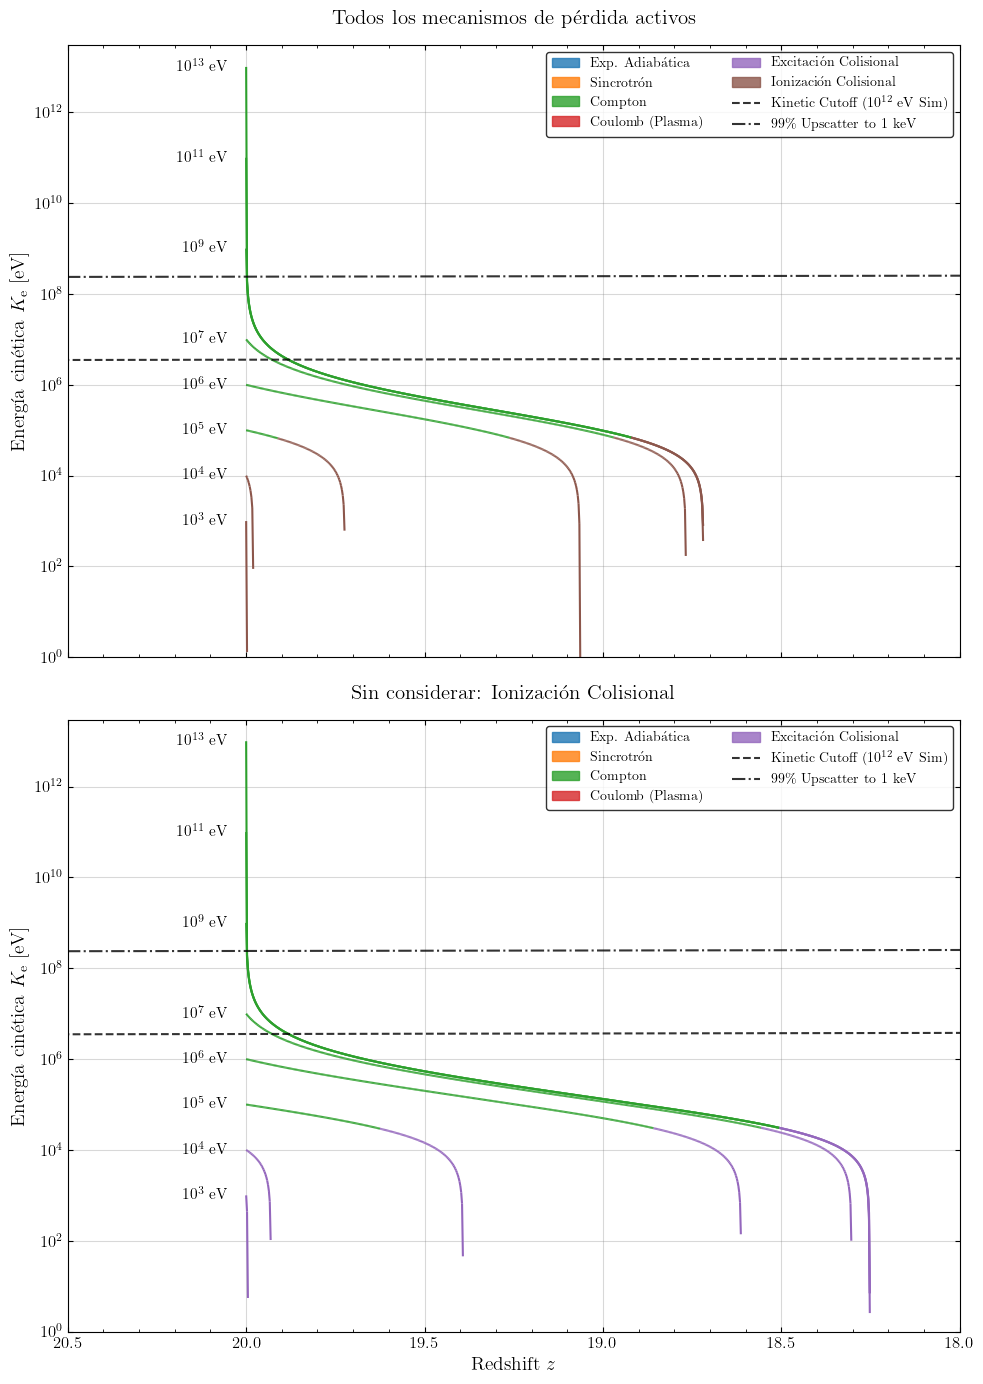

In [ ]:


# --- 4. Scalar ODE Evaluator with Toggles ---

cooling_toggles_custom = {
    'adiabatic': True,
    'synchrotron': True,
    'compton': True,
    'coulomb': True,
    'excitation': True,
    'ionization': False
}

cooling_toggles_baseline = {k: True for k in cooling_toggles_custom}

def get_cooling_rate_evaluator(toggles):
    def evaluator(t, K):
        K_val = K[0]
        if K_val <= 0: return [0.0]
        
        E_val = K_val + E0
        gamma = E_val / E0
        z = float(z_interp(t))
        
        p_sqrd_c_sqrd = K_val**2 + 2 * K_val * E0
        v = LIGHT_SPEED_MKS * np.sqrt(p_sqrd_c_sqrd) / E_val
        n_HI_z = 1.8e3 * ((1.0 + z) / 21.0)**3
        
        L_ad = 0.0
        if toggles['adiabatic']:
            L_ad = float(H_interp(t)) * p_sqrd_c_sqrd / E_val
            
        L_synch = 0.0
        if toggles['synchrotron']:
            U_B = ((B0 * (1 + z)**2)**2) / (2 * VACUUM_PERMEABILITY)
            L_synch = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p_sqrd_c_sqrd
            
        L_ic = 0.0
        if toggles['compton']:
            T_CMB_z, U_CMB_z = T_CMB_0 * (1.0 + z), U_CMB_0_J_M3 * (1 + z)**4
            L_ic = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB_z / E0**2) * p_sqrd_c_sqrd * float(F_KN_interp(4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB_z / E0))
        
        L_coulomb = 0.0
        if toggles['coulomb']:
            n_e = ION_FRACTION * n_HI_z
            x = np.sqrt(K_val / E0) * v * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * np.sqrt(n_e * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS)))
            if x > 0:
                fb = math.log(x) + math.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
                L_coulomb = (n_e * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * fb / (4.0 * math.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * v**2)) * v

        K_eV = K_val / EV_MKS
        
        L_exc = 0.0
        if toggles['excitation'] and K_eV >= threshold_eV_exc:
            L_exc = max(0.0, (n_HI_z * v * float(loss_interp_exc(K_eV))) * EV_MKS)            
        L_ion = 0.0
        if toggles['ionization'] and K_eV >= threshold_eV_ion:
            L_ion = max(0.0, (n_HI_z * v * float(loss_interp_ion(K_eV))) * EV_MKS)
        return [-(L_ad + L_synch + L_ic + L_coulomb + L_exc + L_ion)]
        
    return evaluator

def thermalization_limit(t, K):
    return K[0] - (BOLTZMANN_CONSTANT_MKS * T_CMB_0 * (1.0 + z_interp(t)))
thermalization_limit.terminal = True
thermalization_limit.direction = -1


#--- 5. Plotting Trajectories and Gradient Mechanisms ---
print("Integrating individual trajectories for overlay...")

fig, axes = plt.subplots(2, 1, figsize=(10.0, 14.0), sharex=True)

mechanism_names = ['Exp. Adiabática', 'Sincrotrón', 'Compton', 'Coulomb (Plasma)', 'Excitación Colisional', 'Ionización Colisional']
mechanism_keys = ['adiabatic', 'synchrotron', 'compton', 'coulomb', 'excitation', 'ionization']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
cmap = ListedColormap(colors)

initial_energies_eV = np.array([1e3, 1e4, 1e5, 1e6, 1e7, 1e9, 1e11, 1e13])
t_eval = np.logspace(np.log10(t_init), np.log10(t_final), 10000)

def draw_phase_panel(ax, toggles, title):
    active_evaluator = get_cooling_rate_evaluator(toggles)
    
    for K_ini_eV in initial_energies_eV:
        K_ini_J = K_ini_eV * EV_MKS
        sol = solve_ivp(active_evaluator, 
                        t_span=(t_eval[0], t_eval[-1]), 
                        y0=[K_ini_J], 
                        events=thermalization_limit,
                        dense_output=True,
                        method='Radau', 
                        rtol=1e-6, atol=1e-25)
        
        active_mask = t_eval <= sol.t[-1]
        t_active = t_eval[active_mask]
        K_active_eV = sol.sol(t_active)[0] / EV_MKS
        z_active = z_interp(t_active)
        
        # 1D Kinematics recalculation to determine dominant mechanisms dynamically
        K_J = K_active_eV * EV_MKS
        E_tot = K_J + E0
        gamma = E_tot / E0
        p2c2 = K_J**2 + 2 * K_J * E0
        v = LIGHT_SPEED_MKS * np.sqrt(p2c2) / E_tot
        
        n_HI = 1.8e3 * ((1.0 + z_active) / 21.0)**3
        n_e = ION_FRACTION * n_HI
        H_val = H_interp(t_active)
        U_B = ((B0 * (1 + z_active)**2)**2) / (2 * VACUUM_PERMEABILITY)
        T_CMB = T_CMB_0 * (1.0 + z_active)
        U_CMB = U_CMB_0_J_M3 * (1 + z_active)**4
        
        L_ad = H_val * p2c2 / E_tot if toggles['adiabatic'] else np.zeros_like(K_J)
        L_synch = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_B / E0**2) * p2c2 if toggles['synchrotron'] else np.zeros_like(K_J)
        b_KN = 4.0 * gamma * BOLTZMANN_CONSTANT_MKS * T_CMB / E0
        L_ic = ((4/3) * THOMSON_CROSS_SECTION_MKS * LIGHT_SPEED_MKS * U_CMB / E0**2) * p2c2 * F_KN_interp(b_KN) if toggles['compton'] else np.zeros_like(K_J)
        
        if toggles['coulomb']:
            plasma_freq = np.sqrt(n_e * ELECTRON_CHARGE_MKS**2 / (VACUUM_PERMITTIVITY * ELECTRON_MASS_MKS))
            x = np.sqrt(K_J / E0) * v * LIGHT_SPEED_MKS * ELECTRON_MASS_MKS * np.sqrt(2.0 * delta_gould) / (PLANCK_CONSTANT_REDUCED_MKS * plasma_freq)
            x = np.maximum(x, 1e-50) 
            fb = np.log(x) + np.log(1.0 - delta_gould) * (0.5 + 1.0/gamma - 0.5/(gamma**2)) + 0.5 * delta_gould / (1.0 - delta_gould) + 0.25 * ((1.0 - 1.0/gamma)**2) * (delta_gould**2)
            L_coulomb = np.where(x > 1e-40, (n_e * (Z_target**2) * (ELECTRON_CHARGE_MKS**4) * fb / (4.0 * np.pi * (VACUUM_PERMITTIVITY**2) * ELECTRON_MASS_MKS * v**2)) * v, 0.0)
        else:
            L_coulomb = np.zeros_like(K_J)
            
        L_exc = np.where(K_active_eV >= threshold_eV_exc, (n_HI * v * loss_interp_exc(K_active_eV)) * EV_MKS, 0.0) if toggles['excitation'] else np.zeros_like(K_J)
        L_ion = np.where(K_active_eV >= threshold_eV_ion, (n_HI * v * loss_interp_ion(K_active_eV)) * EV_MKS, 0.0) if toggles['ionization'] else np.zeros_like(K_J)
        
        Loss_Stack = np.stack((L_ad, L_synch, L_ic, L_coulomb, L_exc, L_ion))
        dom_idx = np.argmax(Loss_Stack, axis=0)
        
        # Setup line segments for gradient mapping
        points = np.array([z_active, K_active_eV]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(-0.5, 5.5))
        lc.set_array(dom_idx[:-1])
        lc.set_linewidth(1.5)
        ax.add_collection(lc)

        # Flag placement
        exp_val = int(np.log10(K_ini_eV))
        ax.text(z_active[0] + 0.05, K_active_eV[0], rf'$10^{{{exp_val}}}$ eV', fontsize=11, va='center', ha='right', color='black')

    # Formatting 
    ax.set_yscale('log')
    ax.set_xlim(z_init + 0.5, 18)
    ax.set_ylim(1e0, 3e13)
    ax.set_title(title, fontsize=15, pad=15)
    
    ax.set_ylabel(r'Energía cinética $K_{\mathrm{e}}$ [eV]', fontsize=14)
    
    # Plot calculated kinematic curves
    line_cutoff, = ax.plot(z_array_interp, ke_cutoff_array, color='black', linestyle='--', alpha=0.8, label=r'Fotoionizacion secundaria')
    line_99, = ax.plot(z_array_interp, ke_99_array, color='black', linestyle='--', alpha=0.8)
    
    ax.grid(True, which="major", ls="-", alpha=0.3, color='grey')
    
    # Legend Assembly based on toggled mechanisms
    active_indices = [idx for idx, key in enumerate(mechanism_keys) if toggles[key]]
    legend_patches = [mpatches.Patch(color=colors[idx], label=mechanism_names[idx], alpha=0.8) for idx in active_indices]
    
    line_handles, line_labels = ax.get_legend_handles_labels()
    all_handles = legend_patches + line_handles
    ax.legend(handles=all_handles, loc='upper right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', ncol=2)

# Build Top Panel
draw_phase_panel(axes[0], cooling_toggles_baseline, "Todos los mecanismos de pérdida activos")

# Build Bottom Panel
title_disabled = ', '.join([name for key, name in zip(mechanism_keys, mechanism_names) if not cooling_toggles_custom[key]])
draw_phase_panel(axes[1], cooling_toggles_custom, f"Sin considerar: {title_disabled}" if title_disabled else "Todos los mecanismos activos")

axes[1].set_xlabel(r'Redshift $z$', fontsize=14)

plt.tight_layout()
plt.savefig(f'electron_cooling_phase_space_comparison_vs_without_{title_disabled}-Z_20.png', dpi=300, bbox_inches='tight')
plt.show()